In [8]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [9]:
# ============================================================
# STEP 1 — DDRNet-39 / CAMVID — IMAGENET-ONLY EXPERIMENT
#
# ENVIRONMENT
# IMPORTS
# REPRODUCIBILITY
# DEVICE / CUDA SETUP
# EXPERIMENT IDENTITY
# PRETRAINING POLICY
# PATHS
# TRAINING HISTORY
# CHECKPOINT INFRASTRUCTURE
#
# Experiment:
#
#       DDRNet39_imagenet.pth
#                ↓
#             DDRNet-39
#                ↓
#              CamVid
#
# ImageNet initialization:
#       ENABLED
#
# Cityscapes semantic initialization:
#       DISABLED
#
# Total training epochs:
#       484
#
# ImageNet checkpoint:
#
# /home/hrusikesh-nishank/Pictures/
# DDRNet_cityscapes/pretrained_weights/
# DDRNet39_imagenet.pth
#
# Experiment root:
#
# /home/hrusikesh-nishank/Pictures/
# DDRNet_CamVid_ImageNetOnly
#
# GradScaler is NOT created here.
# Step 5 creates a fresh GradScaler before training/recovery.
#
# Source reviewed from supplied Step 1:
# :contentReference[oaicite:0]{index=0}
# ============================================================


# ============================================================
# 1. STANDARD IMPORTS
# ============================================================

import os
import gc
import cv2
import math
import time
import random
import warnings
import datetime
import inspect

from pathlib import Path


# ============================================================
# 2. CUDA MEMORY ALLOCATION POLICY
# ============================================================
#
# Set before importing PyTorch.
# ============================================================

os.environ[
    "PYTORCH_CUDA_ALLOC_CONF"
] = "expandable_segments:True"


# ============================================================
# 3. NUMERICAL / DATA LIBRARIES
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 4. PLOTTING
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns


# ============================================================
# 5. PYTORCH
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# ============================================================
# 6. OPTIMIZATION / DATA LOADING
# ============================================================

from torch.optim.lr_scheduler import PolynomialLR

from torch.utils.data import (
    Dataset,
    DataLoader
)


# ============================================================
# 7. MIXED PRECISION
# ============================================================
#
# GradScaler is imported but intentionally NOT instantiated
# in Step 1.
# ============================================================

from torch.amp import (
    GradScaler,
    autocast
)


# ============================================================
# 8. AUGMENTATION
# ============================================================

import albumentations as A

from albumentations.pytorch import (
    ToTensorV2
)


# ============================================================
# 9. PROGRESS MONITORING
# ============================================================

from tqdm import tqdm


# ============================================================
# 10. INITIAL MEMORY CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 11. WARNING POLICY
# ============================================================

warnings.simplefilter(
    "default"
)


# ============================================================
# 12. REPRODUCIBILITY
# ============================================================

SEED = 42


def set_seed(
    seed: int = 42,
    deterministic: bool = False
):

    random.seed(
        seed
    )


    np.random.seed(
        seed
    )


    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


    os.environ[
        "PYTHONHASHSEED"
    ] = str(
        seed
    )


    if deterministic:

        torch.backends.cudnn.deterministic = True

        torch.backends.cudnn.benchmark = False


        try:

            torch.use_deterministic_algorithms(
                True
            )

        except Exception:

            pass


    else:

        torch.backends.cudnn.deterministic = False

        torch.backends.cudnn.benchmark = True


set_seed(
    SEED,
    deterministic=False
)


print(
    f"[*] Seed set to {SEED} "
    "(deterministic=False)"
)


# ============================================================
# 13. DATALOADER WORKER REPRODUCIBILITY
# ============================================================

def seed_worker(
    worker_id
):

    worker_seed = (
        SEED
        + worker_id
    )


    np.random.seed(
        worker_seed
    )


    random.seed(
        worker_seed
    )


    torch.manual_seed(
        worker_seed
    )


g = torch.Generator()


g.manual_seed(
    SEED
)


# ============================================================
# 14. NOTEBOOK / MATPLOTLIB CONFIGURATION
# ============================================================

%matplotlib inline


plt.rcParams[
    "figure.dpi"
] = 150


plt.rcParams[
    "savefig.dpi"
] = 600


plt.rcParams[
    "figure.figsize"
] = (
    10,
    6
)


sns.set_style(
    "whitegrid"
)


sns.set_context(
    "talk",
    font_scale=0.9
)


# ============================================================
# 15. NOTEBOOK-SAFE OUTPUT POLICY
# ============================================================

NOTEBOOK_SAFE_MODE = True


TQDM_LEAVE = False


DISPLAY_PERIODIC_TRAINING_PLOTS = False


DISPLAY_PERIODIC_QUALITATIVE = False


DISPLAY_FINAL_REPORT_PLOTS = True


MAX_NOTEBOOK_TABLE_ROWS = 25


TRAINING_PLOT_SAVE_INTERVAL = 20


QUAL_VIS_SAVE_INTERVAL = 50


# ============================================================
# 16. DEVICE CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    f"\n[*] Using Device: "
    f"{DEVICE}"
)


# ============================================================
# 17. CUDA PERFORMANCE CONFIGURATION
# ============================================================

ENABLE_TF32 = (
    torch.cuda.is_available()
)


if torch.cuda.is_available():


    print(
        f"    GPU Model: "
        f"{torch.cuda.get_device_name(0)}"
    )


    print(
        f"    CUDA Version: "
        f"{torch.version.cuda}"
    )


    total_gpu_memory = (
        torch.cuda
        .get_device_properties(
            0
        )
        .total_memory
        / 1024**3
    )


    print(
        f"    GPU Memory: "
        f"{total_gpu_memory:.2f} GB"
    )


    try:

        torch.backends.cuda.matmul.allow_tf32 = True

        torch.backends.cudnn.allow_tf32 = True


        print(
            "    TF32 enabled."
        )


    except Exception:

        ENABLE_TF32 = False


# ============================================================
# 18. DATASET / MODEL IDENTIFICATION
# ============================================================

DATASET_NAME = (
    "CamVid"
)


MODEL_NAME = (
    "DDRNet-39"
)


NUM_CLASSES = 11


# ============================================================
# 19. TOTAL TRAINING EPOCHS
# ============================================================

EPOCHS = 484


TOTAL_EPOCHS = EPOCHS


if EPOCHS != 484:

    raise RuntimeError(
        "DDRNet-39 CamVid experiment must use 484 epochs."
    )


# ============================================================
# 20. DDRNET-39 ARCHITECTURE CONSTANTS
# ============================================================

DDRNET_BLOCK_DEPTHS = (
    3,
    4,
    6,
    3
)


DDRNET_BASE_PLANES = 64


DDRNET_HIGHRES_PLANES = 128


DDRNET_DAPPM_BRANCH_PLANES = 128


DDRNET_HEAD_PLANES = 256


DDRNET_BOTTLENECK_EXPANSION = 2


AUX_LOSS_WEIGHT = 0.4


ALIGN_CORNERS = False


# ============================================================
# 21. ARCHITECTURE SAFETY CHECKS
# ============================================================

if DDRNET_BLOCK_DEPTHS != (
    3,
    4,
    6,
    3
):

    raise RuntimeError(
        "DDRNet-39 block depths must remain "
        "(3, 4, 6, 3)."
    )


if NUM_CLASSES != 11:

    raise RuntimeError(
        "CamVid experiment requires 11 classes."
    )


if DDRNET_BASE_PLANES != 64:

    raise RuntimeError(
        "DDRNet-39 base width must remain 64."
    )


if DDRNET_HIGHRES_PLANES != 128:

    raise RuntimeError(
        "DDRNet-39 high-resolution width must remain 128."
    )


if DDRNET_DAPPM_BRANCH_PLANES != 128:

    raise RuntimeError(
        "DDRNet-39 DAPPM width must remain 128."
    )


if DDRNET_HEAD_PLANES != 256:

    raise RuntimeError(
        "DDRNet-39 head width must remain 256."
    )


if DDRNET_BOTTLENECK_EXPANSION != 2:

    raise RuntimeError(
        "DDRNet bottleneck expansion must remain 2."
    )


if not np.isclose(
    AUX_LOSS_WEIGHT,
    0.4
):

    raise RuntimeError(
        "Auxiliary loss weight must remain 0.4."
    )


if ALIGN_CORNERS is not False:

    raise RuntimeError(
        "DDRNet must use ALIGN_CORNERS=False."
    )


# ============================================================
# 22. PRETRAINING POLICY
# ============================================================
#
# ImageNet:
#       ENABLED
#
# Cityscapes semantic segmentation:
#       DISABLED
# ============================================================

PRETRAINING_SOURCE = (
    "ImageNet"
)


USE_IMAGENET_PRETRAINED = True


USE_CITYSCAPES_PRETRAINED = False


ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS = False


# ============================================================
# 23. EXACT IMAGENET CHECKPOINT
# ============================================================

PRETRAINED_WEIGHTS_DIR = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_cityscapes/pretrained_weights"
)


DDRNET39_IMAGENET_WEIGHTS = (
    PRETRAINED_WEIGHTS_DIR
    / "DDRNet39_imagenet.pth"
)


# ============================================================
# 24. IMAGENET CHECKPOINT SAFETY
# ============================================================

if not PRETRAINED_WEIGHTS_DIR.exists():

    raise FileNotFoundError(
        "Pretrained-weight directory not found:\n"
        f"{PRETRAINED_WEIGHTS_DIR}"
    )


if not DDRNET39_IMAGENET_WEIGHTS.exists():

    raise FileNotFoundError(
        "DDRNet39_imagenet.pth not found:\n"
        f"{DDRNET39_IMAGENET_WEIGHTS}"
    )


if (
    DDRNET39_IMAGENET_WEIGHTS.name
    != "DDRNet39_imagenet.pth"
):

    raise RuntimeError(
        "Unexpected pretrained checkpoint selected."
    )


if (
    "imagenet"
    not in DDRNET39_IMAGENET_WEIGHTS
    .name
    .lower()
):

    raise RuntimeError(
        "Selected checkpoint is not identified as ImageNet."
    )


# ============================================================
# 25. PRETRAINING SAFETY CHECKS
# ============================================================

if not USE_IMAGENET_PRETRAINED:

    raise RuntimeError(
        "ImageNet initialization must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "Cityscapes semantic pretraining must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:

    raise RuntimeError(
        "Cityscapes semantic weights are forbidden."
    )


if (
    PRETRAINING_SOURCE.lower()
    != "imagenet"
):

    raise RuntimeError(
        "PRETRAINING_SOURCE must remain ImageNet."
    )


# ============================================================
# 26. EXPERIMENT IDENTITY
# ============================================================

EXPERIMENT_NAME = (
    "DDRNet39_CamVid_ImageNetOnly"
)


TRAINING_PROTOCOL_NAME = (
    "DDRNet39_CamVid_ImageNetOnly_484Epochs"
)


MODEL_ALIAS = (
    "DDRNet-39 "
    "(ImageNet Initialization + "
    "Dual-Resolution Backbone + "
    "Bilateral Fusion + DAPPM + "
    "Deep Supervision)"
)


# ============================================================
# 27. BATCH / AMP STRATEGY
# ============================================================

PHYSICAL_BATCH_SIZE = 2


GRAD_ACCUM_STEPS = 6


EFFECTIVE_BATCH_SIZE = (
    PHYSICAL_BATCH_SIZE
    * GRAD_ACCUM_STEPS
)


TARGET_EFFECTIVE_BATCH_SIZE = 12


if (
    EFFECTIVE_BATCH_SIZE
    != TARGET_EFFECTIVE_BATCH_SIZE
):

    raise RuntimeError(
        "Expected effective batch size 12."
    )


USE_AMP = (
    torch.cuda.is_available()
)


# ============================================================
# IMPORTANT:
#
# DO NOT create:
#
# scaler = GradScaler(...)
#
# here.
#
# Step 5 creates a fresh scaler.
# ============================================================


# ============================================================
# 28. CAMVID DATASET ROOT
# ============================================================

DATASET_ROOT = Path(
    "/home/hrusikesh-nishank/miniconda3/envs/"
    "Segmentation/Datasets/CamVid"
)


if not DATASET_ROOT.exists():

    raise FileNotFoundError(
        "CamVid dataset root not found:\n"
        f"{DATASET_ROOT}"
    )


# ============================================================
# 29. EXACT EXPERIMENT PATHS
# ============================================================

EXPERIMENT_ROOT = Path(
    "/home/hrusikesh-nishank/Pictures/"
    "DDRNet_CamVid"
)


FINAL_SAVE_DIR = (
    EXPERIMENT_ROOT
    / "Results_Export_DDRNet_CamVid"
)


QUAL_VIS_DIR = (
    EXPERIMENT_ROOT
    / "training_visuals_DDRNet_CamVid"
)


CHECKPOINT_DIR = (
    FINAL_SAVE_DIR
    / "progressive_checkpoints_DDRNet_CamVid"
)


PLOTS_DIR = (
    FINAL_SAVE_DIR
    / "training_plots_DDRNet_CamVid"
)


LOGS_DIR = (
    FINAL_SAVE_DIR
    / "training_logs_DDRNet_CamVid"
)


METRICS_DIR = (
    FINAL_SAVE_DIR
    / "training_metrics_DDRNet_CamVid"
)


# ============================================================
# 30. CREATE DIRECTORIES
# ============================================================

for directory in [

    EXPERIMENT_ROOT,
    FINAL_SAVE_DIR,
    QUAL_VIS_DIR,
    CHECKPOINT_DIR,
    PLOTS_DIR,
    LOGS_DIR,
    METRICS_DIR,

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 31. EXACT CHECKPOINT PATHS
# ============================================================

BEST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "ddrnet39_camvid_imagenet_only_best.pth"
)


LATEST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "ddrnet39_camvid_imagenet_only_latest.pth"
)


# ============================================================
# 32. HISTORY FILE
# ============================================================

HISTORY_FILE = (
    LOGS_DIR
    / "training_history_DDRNet39_CamVid_ImageNetOnly.csv"
)


# ============================================================
# 33. TRAINING HISTORY
# ============================================================

history = {

    "epoch": [],
    "phase": [],

    "train_total_loss": [],
    "train_main_loss": [],
    "train_aux_loss": [],

    "train_miou": [],
    "train_macc": [],
    "train_aacc": [],

    "val_total_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],

    "learning_rate": [],
    "epoch_time_sec": [],
    "total_training_time_str": [],

    "train_Precision_Macro": [],
    "train_Recall_Macro": [],
    "train_F1_Macro": [],

    "train_Precision_Micro": [],
    "train_Recall_Micro": [],
    "train_F1_Micro": [],

    "val_Precision_Macro": [],
    "val_Recall_Macro": [],
    "val_F1_Macro": [],

    "val_Precision_Micro": [],
    "val_Recall_Micro": [],
    "val_F1_Micro": [],

    "amp_overflow_skips": [],
    "amp_scale": [],
}


# ============================================================
# 34. BEST / LATEST MODEL TRACKING
# ============================================================

best_record = {

    "epoch":
        -1,

    "best_epoch":
        -1,

    "best_miou":
        -1.0,

    "best_path":
        str(
            BEST_CHECKPOINT
        ),

    "latest_path":
        str(
            LATEST_CHECKPOINT
        ),
}


# ============================================================
# 35. EXISTING CHECKPOINT REPORT
# ============================================================

existing_checkpoints = []


for checkpoint_path in [

    LATEST_CHECKPOINT,
    BEST_CHECKPOINT,

]:

    if checkpoint_path.exists():

        existing_checkpoints.append(
            checkpoint_path
        )


if existing_checkpoints:


    print(
        "\n[!] Existing checkpoint(s) detected:"
    )


    for checkpoint_path in existing_checkpoints:

        print(
            f"    {checkpoint_path}"
        )


    print(
        "[*] Step 5 must verify checkpoint metadata "
        "before recovery."
    )


else:


    print(
        "\n[✓] Checkpoint directory is clean."
    )


# ============================================================
# 36. ATOMIC TORCH SAVE
# ============================================================

def atomic_torch_save(
    state,
    target_path
):

    target_path = Path(
        target_path
    )


    target_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    temporary_path = Path(
        str(
            target_path
        )
        + ".tmp"
    )


    torch.save(
        state,
        temporary_path
    )


    os.replace(
        temporary_path,
        target_path
    )


# ============================================================
# 37. ATOMIC HISTORY CSV SAVE
# ============================================================

def atomic_history_csv_save(
    history_dict,
    target_path
):

    target_path = Path(
        target_path
    )


    target_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    temporary_path = Path(
        str(
            target_path
        )
        + ".tmp"
    )


    pd.DataFrame(
        history_dict
    ).to_csv(
        temporary_path,
        index=False
    )


    os.replace(
        temporary_path,
        target_path
    )


# ============================================================
# 38. CHECKPOINT MANAGER
# ============================================================

def save_checkpoint(
    epoch,
    model,
    optimizer,
    scaler,
    scheduler,
    history_dict,
    total_time,
    is_best=False,
    global_update_step=None
):

    state = {

        # ----------------------------------------------------
        # Training state
        # ----------------------------------------------------

        "epoch":
            int(
                epoch
            ),

        "total_epochs":
            int(
                EPOCHS
            ),

        "global_update_step":
            (
                None
                if global_update_step is None
                else int(
                    global_update_step
                )
            ),

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scaler_state_dict":
            (
                scaler.state_dict()
                if scaler is not None
                else None
            ),

        "scheduler_state_dict":
            (
                scheduler.state_dict()
                if scheduler is not None
                else None
            ),

        "history":
            history_dict,

        "total_training_time":
            float(
                total_time
            ),

        "best_record":
            dict(
                best_record
            ),


        # ----------------------------------------------------
        # Experiment identity
        # ----------------------------------------------------

        "experiment_name":
            EXPERIMENT_NAME,

        "training_protocol_name":
            TRAINING_PROTOCOL_NAME,

        "dataset_name":
            DATASET_NAME,

        "model_name":
            MODEL_NAME,

        "model_alias":
            MODEL_ALIAS,

        "num_classes":
            NUM_CLASSES,

        "seed":
            SEED,


        # ----------------------------------------------------
        # Architecture
        # ----------------------------------------------------

        "ddrnet_block_depths":
            DDRNET_BLOCK_DEPTHS,

        "ddrnet_base_planes":
            DDRNET_BASE_PLANES,

        "ddrnet_highres_planes":
            DDRNET_HIGHRES_PLANES,

        "ddrnet_dappm_branch_planes":
            DDRNET_DAPPM_BRANCH_PLANES,

        "ddrnet_head_planes":
            DDRNET_HEAD_PLANES,

        "ddrnet_bottleneck_expansion":
            DDRNET_BOTTLENECK_EXPANSION,

        "aux_loss_weight":
            AUX_LOSS_WEIGHT,

        "align_corners":
            ALIGN_CORNERS,


        # ----------------------------------------------------
        # Pretraining
        # ----------------------------------------------------

        "pretraining_source":
            PRETRAINING_SOURCE,

        "use_imagenet_pretrained":
            USE_IMAGENET_PRETRAINED,

        "use_cityscapes_pretrained":
            USE_CITYSCAPES_PRETRAINED,

        "allow_cityscapes_semantic_weights":
            ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS,

        "imagenet_checkpoint":
            str(
                DDRNET39_IMAGENET_WEIGHTS
            ),


        # ----------------------------------------------------
        # Batch / AMP
        # ----------------------------------------------------

        "physical_batch_size":
            PHYSICAL_BATCH_SIZE,

        "grad_accum_steps":
            GRAD_ACCUM_STEPS,

        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,

        "use_amp":
            USE_AMP,

        "tf32_enabled":
            ENABLE_TF32,


        # ----------------------------------------------------
        # Notebook policy
        # ----------------------------------------------------

        "notebook_safe_mode":
            NOTEBOOK_SAFE_MODE,

        "tqdm_leave":
            TQDM_LEAVE,
    }


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    atomic_history_csv_save(
        history_dict,
        HISTORY_FILE
    )


    # ========================================================
    # SAVE LATEST MODEL
    # ========================================================

    atomic_torch_save(
        state,
        LATEST_CHECKPOINT
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if is_best:

        atomic_torch_save(
            state,
            BEST_CHECKPOINT
        )


# ============================================================
# 39. FINAL STEP-1 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "DDRNet-39 / CamVid — ImageNet-Only Step 1 Summary"
)


print(
    "=" * 100
)


print(
    f"[*] Architecture                 : "
    f"{MODEL_NAME}"
)


print(
    f"[*] Dataset                      : "
    f"{DATASET_NAME}"
)


print(
    f"[*] Classes                      : "
    f"{NUM_CLASSES}"
)


print(
    f"[*] Total Epochs                 : "
    f"{EPOCHS}"
)


print(
    f"[*] Experiment                   : "
    f"{EXPERIMENT_NAME}"
)


print(
    f"[*] Training Protocol            : "
    f"{TRAINING_PROTOCOL_NAME}"
)


print(
    "\n--- Initialization ---"
)


print(
    f"[*] ImageNet Pretrained          : "
    f"{USE_IMAGENET_PRETRAINED}"
)


print(
    f"[*] Cityscapes Semantic Weights  : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    f"[*] Pretraining Source           : "
    f"{PRETRAINING_SOURCE}"
)


print(
    f"[*] ImageNet Checkpoint          : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)


print(
    "\n--- Runtime ---"
)


print(
    f"[*] Device                       : "
    f"{DEVICE}"
)


print(
    f"[*] Physical Batch               : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient Accumulation        : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective Batch              : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] AMP Enabled                  : "
    f"{USE_AMP}"
)


print(
    "[*] GradScaler                  : "
    "Created fresh in Step 5"
)


print(
    "\n--- Paths ---"
)


print(
    f"[*] Dataset Root                 : "
    f"{DATASET_ROOT.resolve()}"
)


print(
    f"[*] Experiment Root              : "
    f"{EXPERIMENT_ROOT.resolve()}"
)


print(
    f"[*] Results Directory            : "
    f"{FINAL_SAVE_DIR.resolve()}"
)


print(
    f"[*] Checkpoint Directory         : "
    f"{CHECKPOINT_DIR.resolve()}"
)


print(
    f"[*] Latest Checkpoint            : "
    f"{LATEST_CHECKPOINT}"
)


print(
    f"[*] Best Checkpoint              : "
    f"{BEST_CHECKPOINT}"
)


print(
    f"[*] Training History             : "
    f"{HISTORY_FILE}"
)


print(
    f"[*] Training Plots               : "
    f"{PLOTS_DIR.resolve()}"
)


print(
    f"[*] Qualitative Results          : "
    f"{QUAL_VIS_DIR.resolve()}"
)


print(
    f"[*] Metrics                      : "
    f"{METRICS_DIR.resolve()}"
)


print(
    "=" * 100
)


print(
    "\n[✓] DDRNet-39 architecture constants verified."
)


print(
    "[✓] Total training epochs fixed at 484."
)


print(
    "[✓] DDRNet39_imagenet.pth verified."
)


print(
    "[✓] ImageNet initialization enabled."
)


print(
    "[✓] Cityscapes semantic initialization disabled."
)


print(
    "[✓] Exact experiment paths configured."
)


print(
    "[✓] Best/latest checkpoint paths configured."
)


print(
    "[✓] GradScaler deferred to Step 5."
)


print(
    "[✓] Step 1 completed successfully."
)

[*] Seed set to 42 (deterministic=False)

[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Version: 12.1
    GPU Memory: 15.73 GB
    TF32 enabled.

[✓] Checkpoint directory is clean.

DDRNet-39 / CamVid — ImageNet-Only Step 1 Summary
[*] Architecture                 : DDRNet-39
[*] Dataset                      : CamVid
[*] Classes                      : 11
[*] Total Epochs                 : 484
[*] Experiment                   : DDRNet39_CamVid_ImageNetOnly
[*] Training Protocol            : DDRNet39_CamVid_ImageNetOnly_484Epochs

--- Initialization ---
[*] ImageNet Pretrained          : True
[*] Cityscapes Semantic Weights  : False
[*] Pretraining Source           : ImageNet
[*] ImageNet Checkpoint          : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth

--- Runtime ---
[*] Device                       : cuda
[*] Physical Batch               : 2
[*] Gradient Accumulation        : 6
[*] Effective Batch              : 12
[*]

In [10]:
# ============================================================
# STEP 2 — DDRNet-39 / CAMVID
# IMAGENET-ONLY INITIALIZATION
#
# HYPERPARAMETERS
# CAMVID LABEL MAPPING
# NORMALIZATION
# VALIDATION POLICY
# VISUALIZATION UTILITIES
#
# IMPORTANT:
#   - Paths are inherited from Step 1.
#   - Paths are NOT redefined here.
#   - EPOCHS is inherited from Step 1.
#   - EPOCHS is NOT redefined here.
#
# Experiment:
#
#       DDRNet39_imagenet.pth
#                ↓
#             DDRNet-39
#                ↓
#              CamVid
#
# ImageNet initialization:
#       ENABLED
#
# Cityscapes semantic weights:
#       DISABLED
#
# Total epochs:
#       484
#
# Reference Step-2 code reviewed:
# :contentReference[oaicite:0]{index=0}
# ============================================================


# ============================================================
# 1. STEP-1 DEPENDENCY CHECK
# ============================================================

required_globals = [
    "DATASET_ROOT",
    "EXPERIMENT_ROOT",
    "FINAL_SAVE_DIR",
    "QUAL_VIS_DIR",
    "CHECKPOINT_DIR",
    "PLOTS_DIR",
    "LOGS_DIR",
    "METRICS_DIR",
    "NUM_CLASSES",
    "EPOCHS",
    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS",
    "PRETRAINING_SOURCE",
    "AUX_LOSS_WEIGHT",
    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",
    "DEVICE",
    "USE_AMP",
    "ALIGN_CORNERS",
    "NOTEBOOK_SAFE_MODE",
    "DISPLAY_PERIODIC_TRAINING_PLOTS",
    "DISPLAY_PERIODIC_QUALITATIVE",
    "TRAINING_PLOT_SAVE_INTERVAL",
    "QUAL_VIS_SAVE_INTERVAL",
    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required Step-1 objects are missing.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 2. EXPERIMENT POLICY VERIFICATION
# ============================================================

if not USE_IMAGENET_PRETRAINED:

    raise RuntimeError(
        "ImageNet pretrained DDRNet-39 weights "
        "must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "Cityscapes semantic pretraining "
        "must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:

    raise RuntimeError(
        "Cityscapes semantic checkpoint loading "
        "must remain disabled."
    )


if str(
    PRETRAINING_SOURCE
).lower() != "imagenet":

    raise RuntimeError(
        "PRETRAINING_SOURCE must remain 'ImageNet'."
    )


if EPOCHS != 484:

    raise RuntimeError(
        "The current DDRNet-39 CamVid experiment "
        "must use 484 epochs."
    )


print(
    "[✓] Step 2 experiment-policy checks passed."
)


# ============================================================
# 3. CAMVID TASK SETTINGS
# ============================================================

CLASSES = NUM_CLASSES


IGNORE_INDEX = 255


if CLASSES != 11:

    raise RuntimeError(
        "CamVid experiment requires exactly 11 classes."
    )


# ============================================================
# 4. CAMVID 11-CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Pavement",
    "Tree",
    "SignSymbol",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist",
]


if len(
    CLASS_NAMES
) != CLASSES:

    raise RuntimeError(
        "CamVid class-name count mismatch."
    )


# ============================================================
# 5. CAMVID 11-CLASS DISPLAY PALETTE
# ============================================================
#
# This palette is used only for visualization / decoding.
#
# IMPORTANT:
#
# The original CamVid masks can contain the original
# 32-class RGB colors. Therefore this palette must NOT
# be used alone to encode raw CamVid masks.
# ============================================================

CAMVID_PALETTE = np.array(
    [
        [128, 128, 128],   # Sky
        [128,   0,   0],   # Building
        [192, 192, 128],   # Pole
        [128,  64, 128],   # Road
        [ 60,  40, 222],   # Pavement
        [128, 128,   0],   # Tree
        [192, 128, 128],   # SignSymbol
        [ 64,  64, 128],   # Fence
        [ 64,   0, 128],   # Car
        [ 64,  64,   0],   # Pedestrian
        [  0, 128, 192],   # Bicyclist
    ],
    dtype=np.uint8
)


if CAMVID_PALETTE.shape != (
    CLASSES,
    3
):

    raise RuntimeError(
        "CamVid display-palette shape mismatch."
    )


# ============================================================
# 6. ORIGINAL CAMVID RGB LABELS -> 11 TRAINING CLASSES
# ============================================================
#
# This mapping resolves the earlier Pavement ambiguity.
#
# Raw CamVid labels can use the original RGB annotations.
# Several original labels therefore map to one of the
# standard 11 training classes.
# ============================================================

CAMVID_32_TO_11_COLORS = {

    # 0 — Sky
    0: [
        (128, 128, 128),
    ],

    # 1 — Building
    1: [
        (0, 128, 64),
        (128, 0, 0),
        (64, 192, 0),
        (64, 0, 64),
        (192, 0, 128),
    ],

    # 2 — Pole
    2: [
        (192, 192, 128),
        (0, 0, 64),
        (192, 192, 192),
    ],

    # 3 — Road
    3: [
        (128, 64, 128),
        (128, 0, 192),
        (192, 0, 64),
    ],

    # 4 — Pavement
    4: [
        (0, 0, 192),
        (64, 192, 128),
        (128, 128, 192),
        (60, 40, 222),
    ],

    # 5 — Tree
    5: [
        (128, 128, 0),
        (192, 192, 0),
    ],

    # 6 — SignSymbol
    6: [
        (192, 128, 128),
        (128, 128, 64),
        (0, 64, 64),
    ],

    # 7 — Fence
    7: [
        (64, 64, 128),
    ],

    # 8 — Car
    8: [
        (64, 0, 128),
        (64, 128, 192),
        (192, 128, 192),
        (192, 64, 128),
        (128, 64, 64),
    ],

    # 9 — Pedestrian
    9: [
        (64, 64, 0),
        (192, 128, 64),
        (64, 0, 192),
        (64, 128, 64),
    ],

    # 10 — Bicyclist
    10: [
        (0, 128, 192),
        (192, 0, 192),
    ],
}


CAMVID_VOID_COLORS = {
    (0, 0, 0),
}


# ============================================================
# 7. FLATTEN RGB -> TRAIN-ID LOOKUP
# ============================================================

CAMVID_RGB_TO_CLASS = {}


for class_id, rgb_colors in (
    CAMVID_32_TO_11_COLORS.items()
):

    for rgb in rgb_colors:

        if rgb in CAMVID_RGB_TO_CLASS:

            previous_class = (
                CAMVID_RGB_TO_CLASS[
                    rgb
                ]
            )


            if previous_class != class_id:

                raise RuntimeError(
                    "A CamVid RGB color is assigned "
                    "to more than one class.\n"
                    f"RGB: {rgb}"
                )


        CAMVID_RGB_TO_CLASS[
            rgb
        ] = class_id


# ============================================================
# 8. CAMVID MASK ENCODER
# ============================================================

def encode_mask(
    mask: np.ndarray
) -> np.ndarray:
    """
    Convert a CamVid annotation to 11 training IDs.

    Supported inputs:

    1. H x W integer masks
       Valid:
           0 ... 10
           255 = ignore

    2. H x W x 3 RGB masks
       Original CamVid RGB labels are grouped into
       the standard 11 training classes.

    Unknown / void RGB colors:
        IGNORE_INDEX = 255
    """

    mask = np.asarray(
        mask
    )


    # ========================================================
    # ALREADY CLASS-ID ENCODED
    # ========================================================

    if mask.ndim == 2:

        encoded = mask.astype(
            np.uint8,
            copy=True
        )


        valid = (
            encoded < CLASSES
        )


        ignored = (
            encoded == IGNORE_INDEX
        )


        encoded[
            ~(
                valid
                | ignored
            )
        ] = IGNORE_INDEX


        return encoded


    # ========================================================
    # RGB MASK
    # ========================================================

    if (
        mask.ndim != 3
        or mask.shape[2] != 3
    ):

        raise ValueError(
            "CamVid mask must be HxW IDs or HxWx3 RGB.\n"
            f"Received shape: {mask.shape}"
        )


    encoded = np.full(
        mask.shape[:2],
        IGNORE_INDEX,
        dtype=np.uint8
    )


    for rgb, class_id in (
        CAMVID_RGB_TO_CLASS.items()
    ):

        rgb_array = np.asarray(
            rgb,
            dtype=np.uint8
        )


        matches = np.all(
            mask == rgb_array,
            axis=-1
        )


        encoded[
            matches
        ] = class_id


    return encoded


# ============================================================
# 9. SEGMENTATION DECODER
# ============================================================

def decode_segmap(
    segmentation_map: np.ndarray
) -> np.ndarray:
    """
    Convert 11-class CamVid IDs to RGB visualization.
    """

    segmentation_map = np.asarray(
        segmentation_map
    )


    if segmentation_map.ndim != 2:

        raise ValueError(
            "decode_segmap expects a 2D mask.\n"
            f"Received: {segmentation_map.shape}"
        )


    segmentation_map = segmentation_map.astype(
        np.int64,
        copy=False
    )


    rgb = np.zeros(
        (
            segmentation_map.shape[0],
            segmentation_map.shape[1],
            3
        ),
        dtype=np.uint8
    )


    valid = (
        (segmentation_map >= 0)
        &
        (segmentation_map < CLASSES)
    )


    rgb[
        valid
    ] = CAMVID_PALETTE[
        segmentation_map[
            valid
        ]
    ]


    return rgb


# ============================================================
# 10. IMAGENET NORMALIZATION
# ============================================================

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)


IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


# ============================================================
# 11. PADDING POLICY
# ============================================================
#
# Keep black image padding for consistency with the
# established CamVid DDRNet pipeline.
#
# Mask padding must be ignored by the loss.
# ============================================================

IMAGE_PADDING_VALUE = 0


MASK_PADDING_VALUE = IGNORE_INDEX


# ============================================================
# 12. CAMVID IMAGE GEOMETRY
# ============================================================
#
# Dataset / paper notation:
#
#       960 x 720
#       Width x Height
#
# PyTorch / Albumentations:
#
#       Height x Width
# ============================================================

IMG_H = 720


IMG_W = 960


TRAIN_IMG_H = IMG_H


TRAIN_IMG_W = IMG_W


VAL_IMG_H = IMG_H


VAL_IMG_W = IMG_W


# ============================================================
# 13. TRAINING LENGTH
# ============================================================
#
# EPOCHS is defined ONCE in Step 1.
# Do not redefine it here.
# ============================================================

USE_EARLY_STOPPING = False


if EPOCHS != 484:

    raise RuntimeError(
        "Step 1 must define EPOCHS = 484."
    )


# ============================================================
# 14. DEEP SUPERVISION
# ============================================================

AUX_WEIGHT = AUX_LOSS_WEIGHT


if not np.isclose(
    AUX_WEIGHT,
    0.4
):

    raise RuntimeError(
        "DDRNet auxiliary loss weight must remain 0.4."
    )


# ============================================================
# 15. OPTIMIZATION SETTINGS
# ============================================================

BASE_LR = 0.001


MOMENTUM = 0.9


WEIGHT_DECAY = 0.0005


WARMUP_EPOCHS = 0


LR_POWER = 0.9


# ============================================================
# 16. OPTIMIZATION SAFETY CHECK
# ============================================================

if not np.isclose(
    BASE_LR,
    0.001
):

    raise RuntimeError(
        "CamVid base LR must remain 0.001."
    )


if not np.isclose(
    MOMENTUM,
    0.9
):

    raise RuntimeError(
        "SGD momentum must remain 0.9."
    )


if not np.isclose(
    WEIGHT_DECAY,
    0.0005
):

    raise RuntimeError(
        "Weight decay must remain 0.0005."
    )


if not np.isclose(
    LR_POWER,
    0.9
):

    raise RuntimeError(
        "Polynomial LR power must remain 0.9."
    )


# ============================================================
# 17. OHEM POLICY
# ============================================================

USE_OHEM = True


OHEM_THRESHOLD = 0.9


OHEM_MIN_KEPT = 131_072


# ============================================================
# 18. TRAINING AUGMENTATION SETTINGS
# ============================================================

TRAIN_SCALE_MIN = 0.5


TRAIN_SCALE_MAX = 2.0


HORIZONTAL_FLIP_PROB = 0.5


if not (
    np.isclose(
        TRAIN_SCALE_MIN,
        0.5
    )
    and np.isclose(
        TRAIN_SCALE_MAX,
        2.0
    )
):

    raise RuntimeError(
        "DDRNet random scale must remain 0.5-2.0."
    )


if not np.isclose(
    HORIZONTAL_FLIP_PROB,
    0.5
):

    raise RuntimeError(
        "Horizontal-flip probability must remain 0.5."
    )


# ============================================================
# 19. ROUTINE VALIDATION POLICY
# ============================================================

USE_SLIDING_WINDOW_VAL = False


USE_FLIP_TTA = False


USE_MULTI_SCALE_TTA_FOR_CHECKPOINT_SELECTION = False


VAL_WINDOW_SIZE = (
    VAL_IMG_H,
    VAL_IMG_W
)


VAL_WINDOW_STRIDE = (
    VAL_IMG_H,
    VAL_IMG_W
)


# ============================================================
# 20. OPTIONAL FINAL-EVALUATION TTA
# ============================================================
#
# NOT used for checkpoint selection.
# ============================================================

DDRNET_FINAL_TTA_SCALES = (
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
)


# ============================================================
# 21. NOTEBOOK-SAFE TRAINING CURVE EXPORT
# ============================================================

def plot_training_curves(
    history_dict,
    save_path=PLOTS_DIR
):

    required_keys = [
        "epoch",
        "train_total_loss",
        "val_total_loss",
        "train_miou",
        "val_miou",
        "train_F1_Macro",
        "val_F1_Macro",
    ]


    target_length = len(
        history_dict.get(
            "epoch",
            []
        )
    )


    if target_length == 0:

        return None


    safe_history = {}


    for key in required_keys:

        values = list(
            history_dict.get(
                key,
                []
            )
        )


        if len(values) > target_length:

            values = values[
                :target_length
            ]


        elif len(values) < target_length:

            values.extend(
                [
                    np.nan
                ]
                * (
                    target_length
                    - len(values)
                )
            )


        safe_history[
            key
        ] = values


    plot_df = pd.DataFrame(
        safe_history
    )


    max_epoch = int(
        plot_df[
            "epoch"
        ].max()
    )


    filtered_df = plot_df[
        (
            plot_df[
                "epoch"
            ]
            % TRAINING_PLOT_SAVE_INTERVAL
            == 0
        )
        |
        (
            plot_df[
                "epoch"
            ]
            == max_epoch
        )
    ].copy()


    if filtered_df.empty:

        return None


    epochs = filtered_df[
        "epoch"
    ].to_numpy()


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(
            22,
            6
        )
    )


    # ========================================================
    # LOSS
    # ========================================================

    axes[0].plot(
        epochs,
        filtered_df[
            "train_total_loss"
        ],
        linewidth=2,
        label="Train Loss"
    )


    if not filtered_df[
        "val_total_loss"
    ].isna().all():

        axes[0].plot(
            epochs,
            filtered_df[
                "val_total_loss"
            ],
            linewidth=2,
            label="Validation Loss"
        )


    axes[0].set_title(
        "DDRNet-39 CamVid Loss"
    )


    axes[0].set_xlabel(
        "Epoch"
    )


    axes[0].set_ylabel(
        "Loss"
    )


    axes[0].legend()


    axes[0].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    # ========================================================
    # mIoU
    # ========================================================

    axes[1].plot(
        epochs,
        filtered_df[
            "train_miou"
        ],
        linewidth=2,
        label="Train mIoU"
    )


    if not filtered_df[
        "val_miou"
    ].isna().all():

        axes[1].plot(
            epochs,
            filtered_df[
                "val_miou"
            ],
            linewidth=2,
            label="Validation mIoU"
        )


    axes[1].set_title(
        "DDRNet-39 CamVid mIoU"
    )


    axes[1].set_xlabel(
        "Epoch"
    )


    axes[1].set_ylabel(
        "mIoU (%)"
    )


    axes[1].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=1
        )
    )


    axes[1].legend()


    axes[1].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    # ========================================================
    # MACRO F1
    # ========================================================

    axes[2].plot(
        epochs,
        filtered_df[
            "train_F1_Macro"
        ],
        linewidth=2,
        label="Train F1"
    )


    if not filtered_df[
        "val_F1_Macro"
    ].isna().all():

        axes[2].plot(
            epochs,
            filtered_df[
                "val_F1_Macro"
            ],
            linewidth=2,
            label="Validation F1"
        )


    axes[2].set_title(
        "DDRNet-39 CamVid Macro F1"
    )


    axes[2].set_xlabel(
        "Epoch"
    )


    axes[2].set_ylabel(
        "F1 Score (%)"
    )


    axes[2].yaxis.set_major_formatter(
        mtick.PercentFormatter(
            decimals=1
        )
    )


    axes[2].legend()


    axes[2].grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    fig.tight_layout()


    save_path = Path(
        save_path
    )


    save_path.mkdir(
        parents=True,
        exist_ok=True
    )


    output_path = (
        save_path
        / "training_metrics_DDRNet39_CamVid.png"
    )


    fig.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    return output_path


# ============================================================
# 22. NOTEBOOK-SAFE QUALITATIVE VISUALIZATION
# ============================================================

def visualize_results(
    loader,
    model,
    epoch,
    save_path=QUAL_VIS_DIR,
    max_images=3
):

    save_path = Path(
        save_path
    )


    save_path.mkdir(
        parents=True,
        exist_ok=True
    )


    model_was_training = (
        model.training
    )


    model.eval()


    images, targets = next(
        iter(
            loader
        )
    )


    images = images.to(
        DEVICE,
        non_blocking=True
    )


    with torch.inference_mode():

        with autocast(
            device_type=DEVICE.type,
            enabled=(
                USE_AMP
                and images.is_cuda
            )
        ):

            outputs = model(
                images
            )


            logits = (
                outputs[0]
                if isinstance(
                    outputs,
                    (
                        tuple,
                        list
                    )
                )
                else outputs
            )


            if (
                logits.shape[-2:]
                != targets.shape[-2:]
            ):

                logits = F.interpolate(
                    logits,
                    size=targets.shape[-2:],
                    mode="bilinear",
                    align_corners=ALIGN_CORNERS
                )


            predictions = torch.argmax(
                logits,
                dim=1
            )


    images_np = (
        images
        .detach()
        .cpu()
        .numpy()
    )


    targets_np = (
        targets
        .cpu()
        .numpy()
    )


    predictions_np = (
        predictions
        .cpu()
        .numpy()
    )


    number_of_images = min(
        max_images,
        len(
            images_np
        )
    )


    fig, axes = plt.subplots(
        number_of_images,
        3,
        figsize=(
            15,
            5
            * number_of_images
        )
    )


    if number_of_images == 1:

        axes = np.expand_dims(
            axes,
            axis=0
        )


    mean = np.asarray(
        IMAGENET_MEAN,
        dtype=np.float32
    )


    std = np.asarray(
        IMAGENET_STD,
        dtype=np.float32
    )


    for index in range(
        number_of_images
    ):

        image = np.transpose(
            images_np[
                index
            ],
            (
                1,
                2,
                0
            )
        )


        image = (
            image
            * std
            + mean
        )


        image = np.clip(
            image,
            0.0,
            1.0
        )


        axes[
            index,
            0
        ].imshow(
            image
        )


        axes[
            index,
            0
        ].set_title(
            "Input Image"
        )


        axes[
            index,
            0
        ].axis(
            "off"
        )


        axes[
            index,
            1
        ].imshow(
            decode_segmap(
                targets_np[
                    index
                ]
            )
        )


        axes[
            index,
            1
        ].set_title(
            "Ground Truth"
        )


        axes[
            index,
            1
        ].axis(
            "off"
        )


        axes[
            index,
            2
        ].imshow(
            decode_segmap(
                predictions_np[
                    index
                ]
            )
        )


        axes[
            index,
            2
        ].set_title(
            f"DDRNet-39 Prediction "
            f"(Epoch {epoch})"
        )


        axes[
            index,
            2
        ].axis(
            "off"
        )


    fig.tight_layout()


    output_path = (
        save_path
        / (
            f"epoch_{epoch:03d}_"
            "DDRNet39_CamVid.png"
        )
    )


    fig.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    if model_was_training:

        model.train()


    return output_path


# ============================================================
# 23. PERIODIC QUALITATIVE SAVE HELPER
# ============================================================

def save_periodic_visuals(
    epoch,
    loader,
    model,
    save_path=QUAL_VIS_DIR,
    max_images=3
):

    if (
        epoch > 0
        and epoch
        % QUAL_VIS_SAVE_INTERVAL
        == 0
    ):

        return visualize_results(
            loader=loader,
            model=model,
            epoch=epoch,
            save_path=save_path,
            max_images=max_images
        )


    return None


# ============================================================
# 24. FINAL CONFIGURATION CHECK
# ============================================================

assert CLASSES == 11

assert EPOCHS == 484

assert IMG_H == 720

assert IMG_W == 960

assert VAL_IMG_H == 720

assert VAL_IMG_W == 960

assert np.isclose(
    BASE_LR,
    0.001
)

assert np.isclose(
    MOMENTUM,
    0.9
)

assert np.isclose(
    WEIGHT_DECAY,
    0.0005
)

assert np.isclose(
    LR_POWER,
    0.9
)

assert np.isclose(
    AUX_WEIGHT,
    0.4
)

assert USE_OHEM is True

assert USE_IMAGENET_PRETRAINED is True

assert USE_CITYSCAPES_PRETRAINED is False

assert ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS is False


# ============================================================
# 25. STEP-2 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 88
)


print(
    "DDRNet-39 / CamVid — Step 2 Summary"
)


print(
    "=" * 88
)


print(
    f"[*] Classes                    : "
    f"{CLASSES}"
)


print(
    f"[*] Training Resolution        : "
    f"{IMG_W} x {IMG_H}"
)


print(
    f"[*] Validation Resolution      : "
    f"{VAL_IMG_W} x {VAL_IMG_H}"
)


print(
    f"[*] Epochs                     : "
    f"{EPOCHS}"
)


print(
    f"[*] Base LR                    : "
    f"{BASE_LR}"
)


print(
    f"[*] Momentum                   : "
    f"{MOMENTUM}"
)


print(
    f"[*] Weight Decay               : "
    f"{WEIGHT_DECAY}"
)


print(
    f"[*] PolyLR Power               : "
    f"{LR_POWER}"
)


print(
    f"[*] Random Scale               : "
    f"{TRAIN_SCALE_MIN} - "
    f"{TRAIN_SCALE_MAX}"
)


print(
    f"[*] Horizontal Flip            : "
    f"{HORIZONTAL_FLIP_PROB}"
)


print(
    f"[*] OHEM                       : "
    f"{USE_OHEM}"
)


print(
    f"[*] OHEM Threshold             : "
    f"{OHEM_THRESHOLD}"
)


print(
    f"[*] OHEM Min Kept              : "
    f"{OHEM_MIN_KEPT:,}"
)


print(
    f"[*] Auxiliary Loss Weight      : "
    f"{AUX_WEIGHT}"
)


print(
    f"[*] ImageNet Initialization    : "
    f"{USE_IMAGENET_PRETRAINED}"
)


print(
    f"[*] Cityscapes Weights         : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    f"[*] Checkpoint Selection TTA   : "
    f"{USE_MULTI_SCALE_TTA_FOR_CHECKPOINT_SELECTION}"
)


print(
    "=" * 88
)


print(
    "\n[✓] Step 2 completed successfully."
)

[✓] Step 2 experiment-policy checks passed.

DDRNet-39 / CamVid — Step 2 Summary
[*] Classes                    : 11
[*] Training Resolution        : 960 x 720
[*] Validation Resolution      : 960 x 720
[*] Epochs                     : 484
[*] Base LR                    : 0.001
[*] Momentum                   : 0.9
[*] Weight Decay               : 0.0005
[*] PolyLR Power               : 0.9
[*] Random Scale               : 0.5 - 2.0
[*] Horizontal Flip            : 0.5
[*] OHEM                       : True
[*] OHEM Threshold             : 0.9
[*] OHEM Min Kept              : 131,072
[*] Auxiliary Loss Weight      : 0.4
[*] ImageNet Initialization    : True
[*] Cityscapes Weights         : False
[*] Checkpoint Selection TTA   : False

[✓] Step 2 completed successfully.


In [11]:
# ============================================================
# STEP 3 — DDRNet-39 / CAMVID
#
# DATASET DISCOVERY
# CAMVID 32 -> 11 LABEL ENCODING
# MASK AUDIT
# UNKNOWN-COLOR HANDLING
# TRANSFORMS
# DATASETS
# DATALOADERS
#
# IMPORTANT:
#
#   - All paths are inherited from Step 1.
#   - No experiment/result paths are redefined here.
#   - EPOCHS is inherited from Step 1 and must be 484.
#   - CamVid RGB mappings are inherited from Step 2.
#
# UNKNOWN RGB POLICY:
#
# Training:
#       unknown non-void RGB pixels are NOT allowed
#
# Validation:
#       unknown non-void RGB pixels are NOT allowed
#
# Test:
#       very small off-palette artifacts are allowed
#       and converted to IGNORE_INDEX = 255
#
# Why?
#
# The current local test masks contain a very small number
# of off-palette pixels such as:
#
#       (128,128,51)
#       (26,26,0)
#       (51,51,0)
#
# These are not valid CamVid class colors and should NOT be
# guessed into a semantic class.
#
# Because they occur only in the reserved test split and
# represent an extremely small fraction of pixels, they are
# safely ignored during final metric calculation.
#
# This avoids:
#
#   - inventing incorrect semantic labels
#   - stopping training because of a few test-mask artifacts
#   - contaminating train/validation labels
#
# Reference Step-4 pipeline supplied by user:
# :contentReference[oaicite:0]{index=0}
# ============================================================


# ============================================================
# 1. STEP-1 / STEP-2 DEPENDENCY CHECK
# ============================================================

required_globals = [
    "DATASET_ROOT",
    "METRICS_DIR",

    "SEED",

    "CLASSES",
    "IGNORE_INDEX",
    "CLASS_NAMES",

    "CAMVID_PALETTE",
    "CAMVID_RGB_TO_CLASS",
    "CAMVID_VOID_COLORS",

    "IMG_H",
    "IMG_W",
    "VAL_IMG_H",
    "VAL_IMG_W",

    "TRAIN_SCALE_MIN",
    "TRAIN_SCALE_MAX",
    "HORIZONTAL_FLIP_PROB",

    "IMAGENET_MEAN",
    "IMAGENET_STD",

    "IMAGE_PADDING_VALUE",
    "MASK_PADDING_VALUE",

    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",

    "EPOCHS",

    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS",
    "PRETRAINING_SOURCE",

    "DEVICE",

    "seed_worker",
    "g",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required Step-1 / Step-2 objects are missing.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 2. EXPERIMENT POLICY CHECK
# ============================================================

if CLASSES != 11:

    raise RuntimeError(
        "CamVid experiment must use 11 classes."
    )


if EPOCHS != 484:

    raise RuntimeError(
        "Current DDRNet-39 CamVid experiment "
        "must use 484 epochs."
    )


if not USE_IMAGENET_PRETRAINED:

    raise RuntimeError(
        "ImageNet initialization must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "Cityscapes semantic pretraining "
        "must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:

    raise RuntimeError(
        "Cityscapes semantic weights "
        "must remain disabled."
    )


if str(
    PRETRAINING_SOURCE
).lower() != "imagenet":

    raise RuntimeError(
        "PRETRAINING_SOURCE must remain 'ImageNet'."
    )


print(
    "[✓] Step 3 experiment-policy checks passed."
)


# ============================================================
# 3. CANONICAL CAMVID COUNTS
# ============================================================
#
# Used only as a reference.
#
# The local split is NOT modified merely to force these
# published counts.
# ============================================================

CANONICAL_CAMVID_COUNTS = {

    "train": 367,

    "val": 101,

    "test": 233,
}


# ============================================================
# 4. SUPPORTED IMAGE EXTENSIONS
# ============================================================

CAMVID_IMAGE_EXTENSIONS = {

    ".png",

    ".jpg",

    ".jpeg",

    ".bmp",
}


# ============================================================
# 5. UNKNOWN-COLOR POLICY
# ============================================================
#
# Train and validation:
#
#   Be strict because these labels affect optimization and
#   checkpoint selection.
#
# Test:
#
#   Tiny off-palette artifacts may be ignored.
#
# Maximum allowed test unknown fraction:
#
#       0.0001 = 0.01%
#
# This is intentionally conservative.
# ============================================================

ALLOW_TEST_UNKNOWN_NONVOID_PIXELS = True


MAX_TEST_UNKNOWN_FRACTION = 1e-4


# Additional absolute safety limit.
MAX_TEST_UNKNOWN_PIXELS = 10_000


# ============================================================
# 6. FAST RGB -> TRAIN-ID LOOKUP TABLE
# ============================================================
#
# Direct RGB encoding:
#
#       R << 16 | G << 8 | B
#
# avoids repeatedly comparing an entire image with every
# CamVid class color during 484 training epochs.
#
# Size:
#
#       256^3 uint8
#       ≈ 16 MB
# ============================================================

CAMVID_RGB_LUT = np.full(

    256 ** 3,

    IGNORE_INDEX,

    dtype=np.uint8
)


for rgb, class_id in (
    CAMVID_RGB_TO_CLASS.items()
):

    r = int(
        rgb[0]
    )


    g_value = int(
        rgb[1]
    )


    b = int(
        rgb[2]
    )


    lookup_index = (
        (r << 16)
        |
        (g_value << 8)
        |
        b
    )


    CAMVID_RGB_LUT[
        lookup_index
    ] = np.uint8(
        class_id
    )


# ============================================================
# VOID COLORS
# ============================================================

for rgb in CAMVID_VOID_COLORS:

    r = int(
        rgb[0]
    )


    g_value = int(
        rgb[1]
    )


    b = int(
        rgb[2]
    )


    lookup_index = (
        (r << 16)
        |
        (g_value << 8)
        |
        b
    )


    CAMVID_RGB_LUT[
        lookup_index
    ] = np.uint8(
        IGNORE_INDEX
    )


print(
    "[✓] Fast CamVid RGB -> 11-class lookup initialized."
)


# ============================================================
# 7. FAST CAMVID MASK ENCODER
# ============================================================

def encode_camvid_mask_fast(
    mask: np.ndarray
) -> np.ndarray:
    """
    Convert CamVid masks to 11 training classes.

    Supported formats:

        H x W
            pre-encoded semantic IDs

        H x W x 3
            RGB CamVid annotation

    Output:

        0 ... 10
            valid semantic classes

        255
            ignore / void / unknown off-palette pixels
    """

    mask = np.asarray(
        mask
    )


    # ========================================================
    # ALREADY CLASS-ID ENCODED
    # ========================================================

    if mask.ndim == 2:

        encoded = mask.astype(
            np.uint8,
            copy=True
        )


        valid = (
            encoded
            < CLASSES
        )


        ignored = (
            encoded
            == IGNORE_INDEX
        )


        encoded[
            ~(
                valid
                | ignored
            )
        ] = IGNORE_INDEX


        return encoded


    # ========================================================
    # RGB MASK
    # ========================================================

    if (
        mask.ndim != 3
        or mask.shape[2] != 3
    ):

        raise ValueError(
            "CamVid mask must be HxW class IDs "
            "or HxWx3 RGB.\n"
            f"Received shape: {mask.shape}"
        )


    rgb = mask.astype(
        np.uint32,
        copy=False
    )


    lookup_indices = (

        (rgb[..., 0] << 16)

        |

        (rgb[..., 1] << 8)

        |

        rgb[..., 2]
    )


    encoded = CAMVID_RGB_LUT[
        lookup_indices
    ]


    return encoded.astype(
        np.uint8,
        copy=False
    )


# Common name retained for later notebook cells.
encode_mask = (
    encode_camvid_mask_fast
)


# ============================================================
# 8. VOID MASK HELPER
# ============================================================

def get_void_rgb_mask(
    rgb_mask
):

    if (
        rgb_mask.ndim != 3
        or rgb_mask.shape[2] != 3
    ):

        return np.zeros(
            rgb_mask.shape[:2],
            dtype=bool
        )


    void_mask = np.zeros(
        rgb_mask.shape[:2],
        dtype=bool
    )


    for rgb in CAMVID_VOID_COLORS:

        rgb_array = np.asarray(
            rgb,
            dtype=np.uint8
        )


        void_mask |= np.all(
            rgb_mask == rgb_array,
            axis=-1
        )


    return void_mask


# ============================================================
# 9. SPLIT DISCOVERY
# ============================================================

def get_camvid_pairs(
    split
):

    image_dir = (
        DATASET_ROOT
        / split
    )


    if not image_dir.exists():

        raise FileNotFoundError(
            f"CamVid image directory does not exist:\n"
            f"{image_dir}"
        )


    possible_mask_dirs = [

        DATASET_ROOT
        / f"{split}annot",

        DATASET_ROOT
        / f"{split}_labels",

        DATASET_ROOT
        / f"{split}labels",
    ]


    mask_dir = next(

        (
            directory

            for directory
            in possible_mask_dirs

            if directory.exists()
        ),

        None
    )


    if mask_dir is None:

        raise FileNotFoundError(
            f"Could not locate CamVid annotation directory "
            f"for '{split}'.\n"
            + "\n".join(
                str(path)
                for path
                in possible_mask_dirs
            )
        )


    image_paths = sorted(

        [

            path

            for path
            in image_dir.iterdir()

            if (
                path.is_file()

                and

                path.suffix.lower()
                in CAMVID_IMAGE_EXTENSIONS

                and

                not path.stem.endswith(
                    "_L"
                )
            )
        ],

        key=lambda path:
            path.name.lower()
    )


    valid_images = []


    valid_masks = []


    missing_masks = []


    for image_path in image_paths:


        candidates = [

            mask_dir
            / image_path.name,

            mask_dir
            / f"{image_path.stem}.png",

            mask_dir
            / f"{image_path.stem}_L.png",
        ]


        mask_path = next(

            (
                candidate

                for candidate
                in candidates

                if candidate.exists()
            ),

            None
        )


        if mask_path is None:

            missing_masks.append(
                image_path.name
            )


        else:

            valid_images.append(
                image_path
            )


            valid_masks.append(
                mask_path
            )


    print(
        f"\n--- CamVid '{split}' Discovery ---"
    )


    print(
        f"[*] Image directory       : "
        f"{image_dir}"
    )


    print(
        f"[*] Annotation directory  : "
        f"{mask_dir}"
    )


    print(
        f"[*] Image files found     : "
        f"{len(image_paths)}"
    )


    print(
        f"[*] Valid image/mask pairs: "
        f"{len(valid_images)}"
    )


    if missing_masks:

        print(
            f"[!] Missing masks          : "
            f"{len(missing_masks)}"
        )


    return (
        valid_images,
        valid_masks
    )


# ============================================================
# 10. DISCOVER TRAIN / VAL / TEST
# ============================================================

train_img_paths, train_mask_paths = (
    get_camvid_pairs(
        "train"
    )
)


val_img_paths, val_mask_paths = (
    get_camvid_pairs(
        "val"
    )
)


test_img_paths, test_mask_paths = (
    get_camvid_pairs(
        "test"
    )
)


# ============================================================
# 11. SPLIT CONTAINER
# ============================================================

local_splits = {

    "train":
        (
            train_img_paths,
            train_mask_paths
        ),

    "val":
        (
            val_img_paths,
            val_mask_paths
        ),

    "test":
        (
            test_img_paths,
            test_mask_paths
        ),
}


for split_name, (
    image_paths,
    mask_paths
) in local_splits.items():


    if len(
        image_paths
    ) == 0:

        raise RuntimeError(
            f"CamVid {split_name} split is empty."
        )


    if (
        len(image_paths)
        != len(mask_paths)
    ):

        raise RuntimeError(
            f"{split_name} image/mask count mismatch."
        )


# ============================================================
# 12. LOCAL / CANONICAL SPLIT REPORT
# ============================================================

print(
    "\n"
    + "=" * 82
)


print(
    "CAMVID LOCAL DATASET SPLIT CHECK"
)


print(
    "=" * 82
)


for split_name in (
    "train",
    "val",
    "test",
):


    local_count = len(
        local_splits[
            split_name
        ][0]
    )


    reference_count = (
        CANONICAL_CAMVID_COUNTS[
            split_name
        ]
    )


    status = (

        "MATCH"

        if local_count
        == reference_count

        else "LOCAL VARIANT"
    )


    print(
        f"[*] {split_name:<5}"
        f" | Local: {local_count:<4}"
        f" | Canonical: {reference_count:<4}"
        f" | {status}"
    )


local_total = sum(

    len(
        local_splits[
            split_name
        ][0]
    )

    for split_name
    in local_splits
)


canonical_total = sum(
    CANONICAL_CAMVID_COUNTS.values()
)


print(
    "-" * 82
)


print(
    f"[*] Local paired total     : "
    f"{local_total}"
)


print(
    f"[*] Canonical paired total : "
    f"{canonical_total}"
)


print(
    "=" * 82
)


if local_total != canonical_total:

    warnings.warn(
        "Local CamVid total differs from the "
        "expected 701 samples."
    )


# ============================================================
# 13. SPLIT LEAKAGE CHECK
# ============================================================

def normalized_frame_id(
    path
):

    stem = (
        path.stem
    )


    if stem.endswith(
        "_L"
    ):

        stem = stem[:-2]


    return stem.lower()


split_frame_ids = {

    split_name: {

        normalized_frame_id(
            path
        )

        for path
        in image_paths
    }

    for split_name, (
        image_paths,
        _
    ) in local_splits.items()
}


train_val_overlap = (

    split_frame_ids[
        "train"
    ]

    &

    split_frame_ids[
        "val"
    ]
)


train_test_overlap = (

    split_frame_ids[
        "train"
    ]

    &

    split_frame_ids[
        "test"
    ]
)


val_test_overlap = (

    split_frame_ids[
        "val"
    ]

    &

    split_frame_ids[
        "test"
    ]
)


if (
    train_val_overlap
    or train_test_overlap
    or val_test_overlap
):

    raise RuntimeError(
        "CamVid train/validation/test leakage detected."
    )


print(
    "\n[✓] No train/validation/test filename leakage detected."
)


# ============================================================
# 14. MASK AUDIT CONTAINERS
# ============================================================

split_class_pixel_counts = {

    split_name:
        np.zeros(
            CLASSES,
            dtype=np.int64
        )

    for split_name
    in local_splits
}


split_class_image_counts = {

    split_name:
        np.zeros(
            CLASSES,
            dtype=np.int64
        )

    for split_name
    in local_splits
}


split_total_pixels = {

    split_name:
        0

    for split_name
    in local_splits
}


split_unknown_nonvoid_pixels = {

    split_name:
        0

    for split_name
    in local_splits
}


split_void_pixels = {

    split_name:
        0

    for split_name
    in local_splits
}


all_ignore_masks = {

    split_name: []

    for split_name
    in local_splits
}


unknown_rgb_counts = {

    split_name: {}

    for split_name
    in local_splits
}


dataset_mask_audit_records = []


# ============================================================
# 15. FULL DATASET MASK AUDIT
# ============================================================

for split_name, (
    image_paths,
    mask_paths
) in local_splits.items():


    for image_path, mask_path in zip(
        image_paths,
        mask_paths
    ):


        raw_mask = cv2.imread(
            str(
                mask_path
            ),
            cv2.IMREAD_UNCHANGED
        )


        if raw_mask is None:

            raise RuntimeError(
                "Unable to read CamVid mask:\n"
                f"{mask_path}"
            )


        # ====================================================
        # BGR / BGRA -> RGB
        # ====================================================

        if raw_mask.ndim == 3:


            if raw_mask.shape[2] == 3:

                mask_rgb = cv2.cvtColor(
                    raw_mask,
                    cv2.COLOR_BGR2RGB
                )


            elif raw_mask.shape[2] == 4:

                mask_rgb = cv2.cvtColor(
                    raw_mask,
                    cv2.COLOR_BGRA2RGB
                )


            else:

                raise RuntimeError(
                    "Unsupported CamVid mask shape:\n"
                    f"{raw_mask.shape}"
                )


        else:

            mask_rgb = (
                raw_mask
            )


        # ====================================================
        # ENCODE
        # ====================================================

        encoded = encode_camvid_mask_fast(
            mask_rgb
        )


        valid_mask = (
            encoded
            != IGNORE_INDEX
        )


        valid_pixels = int(
            valid_mask.sum()
        )


        total_pixels = int(
            encoded.size
        )


        split_total_pixels[
            split_name
        ] += total_pixels


        # ====================================================
        # VOID / UNKNOWN PIXELS
        # ====================================================

        if mask_rgb.ndim == 3:


            void_mask = get_void_rgb_mask(
                mask_rgb
            )


            unknown_mask = (

                (
                    encoded
                    == IGNORE_INDEX
                )

                &

                (
                    ~void_mask
                )
            )


            void_pixel_count = int(
                void_mask.sum()
            )


            unknown_pixel_count = int(
                unknown_mask.sum()
            )


            # =================================================
            # UNKNOWN RGB STATISTICS
            # =================================================

            if unknown_pixel_count > 0:


                unknown_colors = (
                    mask_rgb[
                        unknown_mask
                    ]
                )


                unique_colors, counts = np.unique(

                    unknown_colors.reshape(
                        -1,
                        3
                    ),

                    axis=0,

                    return_counts=True
                )


                for color, count in zip(
                    unique_colors,
                    counts
                ):


                    rgb_tuple = tuple(
                        int(value)
                        for value
                        in color
                    )


                    unknown_rgb_counts[
                        split_name
                    ][
                        rgb_tuple
                    ] = (

                        unknown_rgb_counts[
                            split_name
                        ].get(
                            rgb_tuple,
                            0
                        )

                        + int(
                            count
                        )
                    )


        # ====================================================
        # 2D ID MASK
        # ====================================================

        else:


            raw_ids = mask_rgb.astype(
                np.int64,
                copy=False
            )


            raw_valid = (

                (
                    raw_ids >= 0
                )

                &

                (
                    raw_ids < CLASSES
                )
            )


            raw_ignore = (
                raw_ids
                == IGNORE_INDEX
            )


            unknown_mask = (

                ~raw_valid

                &

                ~raw_ignore
            )


            unknown_pixel_count = int(
                unknown_mask.sum()
            )


            void_pixel_count = int(
                raw_ignore.sum()
            )


        split_unknown_nonvoid_pixels[
            split_name
        ] += unknown_pixel_count


        split_void_pixels[
            split_name
        ] += void_pixel_count


        ignored_pixels = (
            total_pixels
            - valid_pixels
        )


        # ====================================================
        # CLASS PIXEL COUNTS
        # ====================================================

        if valid_pixels > 0:


            class_pixel_counts = np.bincount(

                encoded[
                    valid_mask
                ].reshape(
                    -1
                ),

                minlength=CLASSES

            ).astype(
                np.int64
            )


        else:


            class_pixel_counts = np.zeros(
                CLASSES,
                dtype=np.int64
            )


        class_presence = (
            class_pixel_counts
            > 0
        )


        split_class_pixel_counts[
            split_name
        ] += class_pixel_counts


        split_class_image_counts[
            split_name
        ] += class_presence.astype(
            np.int64
        )


        if valid_pixels == 0:

            all_ignore_masks[
                split_name
            ].append(
                mask_path
            )


        # ====================================================
        # AUDIT RECORD
        # ====================================================

        record = {

            "split":
                split_name,

            "filename":
                image_path.name,

            "valid_pixels":
                valid_pixels,

            "void_pixels":
                void_pixel_count,

            "unknown_nonvoid_pixels":
                unknown_pixel_count,

            "ignored_pixels_total":
                ignored_pixels,

            "total_pixels":
                total_pixels,

            "valid_fraction":
                (
                    valid_pixels
                    / max(
                        total_pixels,
                        1
                    )
                ),
        }


        for class_id, class_name in enumerate(
            CLASS_NAMES
        ):


            safe_name = (
                class_name
                .lower()
                .replace(
                    " ",
                    "_"
                )
            )


            record[
                f"pixels_{safe_name}"
            ] = int(
                class_pixel_counts[
                    class_id
                ]
            )


            record[
                f"contains_{safe_name}"
            ] = int(
                class_presence[
                    class_id
                ]
            )


        dataset_mask_audit_records.append(
            record
        )


# ============================================================
# 16. SAVE MASK AUDIT
# ============================================================

dataset_mask_audit_df = pd.DataFrame(
    dataset_mask_audit_records
)


dataset_mask_audit_path = (
    METRICS_DIR
    / "camvid_dataset_mask_audit.csv"
)


dataset_mask_audit_df.to_csv(
    dataset_mask_audit_path,
    index=False
)


print(
    "\n--- CamVid Mask Audit ---"
)


for split_name in (
    "train",
    "val",
    "test",
):


    unknown_fraction = (

        split_unknown_nonvoid_pixels[
            split_name
        ]

        / max(
            split_total_pixels[
                split_name
            ],
            1
        )
    )


    print(
        f"[*] {split_name:<5}"
        f" | Samples: "
        f"{len(local_splits[split_name][0]):>3}"
        f" | All-ignore: "
        f"{len(all_ignore_masks[split_name])}"
        f" | Unknown non-void: "
        f"{split_unknown_nonvoid_pixels[split_name]:,}"
        f" ({unknown_fraction * 100.0:.6f}%)"
    )


print(
    f"[*] Audit CSV: "
    f"{dataset_mask_audit_path}"
)


# ============================================================
# 17. UNKNOWN-COLOR REPORT
# ============================================================

unknown_nonvoid_found = any(

    split_unknown_nonvoid_pixels[
        split_name
    ] > 0

    for split_name
    in local_splits
)


if unknown_nonvoid_found:


    print(
        "\n--- Off-Palette CamVid RGB Audit ---"
    )


    for split_name in (
        "train",
        "val",
        "test",
    ):


        colors = (
            unknown_rgb_counts[
                split_name
            ]
        )


        if not colors:

            continue


        print(
            f"\n{split_name}:"
        )


        for rgb, count in sorted(

            colors.items(),

            key=lambda item:
                item[1],

            reverse=True

        )[:20]:

            print(
                f"    RGB {rgb}"
                f" -> {count:,} pixels"
            )


# ============================================================
# 18. STRICT TRAIN UNKNOWN-COLOR CHECK
# ============================================================

if (
    split_unknown_nonvoid_pixels[
        "train"
    ] > 0
):

    raise RuntimeError(
        "Unknown non-void RGB pixels were found in the "
        "TRAINING split.\n\n"
        "Training labels must remain exact because these "
        "pixels directly affect optimization."
    )


# ============================================================
# 19. STRICT VALIDATION UNKNOWN-COLOR CHECK
# ============================================================

if (
    split_unknown_nonvoid_pixels[
        "val"
    ] > 0
):

    raise RuntimeError(
        "Unknown non-void RGB pixels were found in the "
        "VALIDATION split.\n\n"
        "Validation labels must remain exact because they "
        "are used for checkpoint selection."
    )


# ============================================================
# 20. TEST UNKNOWN-COLOR POLICY
# ============================================================

test_unknown_pixels = (
    split_unknown_nonvoid_pixels[
        "test"
    ]
)


test_total_pixels = (
    split_total_pixels[
        "test"
    ]
)


test_unknown_fraction = (

    test_unknown_pixels

    / max(
        test_total_pixels,
        1
    )
)


if test_unknown_pixels > 0:


    if not ALLOW_TEST_UNKNOWN_NONVOID_PIXELS:

        raise RuntimeError(
            "Unknown non-void RGB pixels were found "
            "in the test split."
        )


    if (
        test_unknown_fraction
        > MAX_TEST_UNKNOWN_FRACTION
    ):

        raise RuntimeError(
            "Too many off-palette RGB pixels were found "
            "in the CamVid test split.\n\n"
            f"Unknown pixels  : {test_unknown_pixels:,}\n"
            f"Total pixels    : {test_total_pixels:,}\n"
            f"Unknown fraction: "
            f"{test_unknown_fraction * 100.0:.6f}%\n"
            f"Allowed maximum : "
            f"{MAX_TEST_UNKNOWN_FRACTION * 100.0:.6f}%"
        )


    if (
        test_unknown_pixels
        > MAX_TEST_UNKNOWN_PIXELS
    ):

        raise RuntimeError(
            "Test unknown-RGB count exceeds the "
            "absolute safety limit.\n"
            f"Found   : {test_unknown_pixels:,}\n"
            f"Allowed : {MAX_TEST_UNKNOWN_PIXELS:,}"
        )


    print(
        "\n[✓] Small test-only off-palette RGB artifacts accepted."
    )


    print(
        f"[*] Unknown test pixels : "
        f"{test_unknown_pixels:,}"
    )


    print(
        f"[*] Fraction            : "
        f"{test_unknown_fraction * 100.0:.8f}%"
    )


    print(
        f"[*] Handling            : "
        f"IGNORE_INDEX ({IGNORE_INDEX})"
    )


    print(
        "[*] No semantic class is guessed for these pixels."
    )


else:


    print(
        "\n[✓] No unknown non-void RGB pixels detected."
    )


# ============================================================
# 21. ALL-IGNORE MASK CHECK
# ============================================================

for split_name in (
    "train",
    "val",
    "test",
):


    if all_ignore_masks[
        split_name
    ]:

        raise RuntimeError(
            f"One or more {split_name} masks contain "
            "zero valid semantic pixels."
        )


# ============================================================
# 22. CLASS DISTRIBUTION
# ============================================================

class_distribution_records = []


for class_id, class_name in enumerate(
    CLASS_NAMES
):


    class_distribution_records.append(
        {

            "class_id":
                class_id,

            "class_name":
                class_name,

            "train_images":
                int(
                    split_class_image_counts[
                        "train"
                    ][
                        class_id
                    ]
                ),

            "train_pixels":
                int(
                    split_class_pixel_counts[
                        "train"
                    ][
                        class_id
                    ]
                ),

            "val_images":
                int(
                    split_class_image_counts[
                        "val"
                    ][
                        class_id
                    ]
                ),

            "val_pixels":
                int(
                    split_class_pixel_counts[
                        "val"
                    ][
                        class_id
                    ]
                ),

            "test_images":
                int(
                    split_class_image_counts[
                        "test"
                    ][
                        class_id
                    ]
                ),

            "test_pixels":
                int(
                    split_class_pixel_counts[
                        "test"
                    ][
                        class_id
                    ]
                ),
        }
    )


class_distribution_df = pd.DataFrame(
    class_distribution_records
)


class_distribution_path = (
    METRICS_DIR
    / "camvid_class_distribution.csv"
)


class_distribution_df.to_csv(
    class_distribution_path,
    index=False
)


print(
    "\n--- CamVid Class Coverage ---"
)


for class_id, class_name in enumerate(
    CLASS_NAMES
):


    print(
        f"[{class_id:02d}] "
        f"{class_name:<12}"
        f" | Train img: "
        f"{split_class_image_counts['train'][class_id]:>3}"
        f" | Val img: "
        f"{split_class_image_counts['val'][class_id]:>3}"
        f" | Test img: "
        f"{split_class_image_counts['test'][class_id]:>3}"
    )


# ============================================================
# 23. TRAIN CLASS COVERAGE CHECK
# ============================================================

missing_train_classes = [

    class_id

    for class_id
    in range(
        CLASSES
    )

    if (
        split_class_image_counts[
            "train"
        ][
            class_id
        ]
        == 0
    )
]


if missing_train_classes:


    missing_names = [

        CLASS_NAMES[
            class_id
        ]

        for class_id
        in missing_train_classes
    ]


    raise RuntimeError(
        "One or more CamVid classes are absent "
        "from the training split:\n"
        f"{missing_names}"
    )


print(
    "\n[✓] All 11 CamVid classes are represented "
    "in the training split."
)


# ============================================================
# 24. DATASET CLASS
# ============================================================

class CamVidDataset(
    Dataset
):

    def __init__(
        self,
        image_paths,
        mask_paths,
        split,
        transform=None
    ):


        self.images = list(
            image_paths
        )


        self.masks = list(
            mask_paths
        )


        self.split = str(
            split
        )


        self.transform = (
            transform
        )


        if (
            len(
                self.images
            )
            != len(
                self.masks
            )
        ):

            raise RuntimeError(
                f"{self.split}: image/mask count mismatch."
            )


    def __len__(
        self
    ):

        return len(
            self.images
        )


    def __getitem__(
        self,
        index
    ):


        image_path = (
            self.images[
                index
            ]
        )


        mask_path = (
            self.masks[
                index
            ]
        )


        # ====================================================
        # IMAGE
        # ====================================================

        image = cv2.imread(

            str(
                image_path
            ),

            cv2.IMREAD_COLOR
        )


        if image is None:

            raise RuntimeError(
                "Unable to read CamVid image:\n"
                f"{image_path}"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


        # ====================================================
        # MASK
        # ====================================================

        raw_mask = cv2.imread(

            str(
                mask_path
            ),

            cv2.IMREAD_UNCHANGED
        )


        if raw_mask is None:

            raise RuntimeError(
                "Unable to read CamVid mask:\n"
                f"{mask_path}"
            )


        if raw_mask.ndim == 3:


            if raw_mask.shape[2] == 3:

                raw_mask = cv2.cvtColor(
                    raw_mask,
                    cv2.COLOR_BGR2RGB
                )


            elif raw_mask.shape[2] == 4:

                raw_mask = cv2.cvtColor(
                    raw_mask,
                    cv2.COLOR_BGRA2RGB
                )


            else:

                raise RuntimeError(
                    "Unsupported CamVid mask shape:\n"
                    f"{raw_mask.shape}"
                )


        mask = encode_camvid_mask_fast(
            raw_mask
        )


        # ====================================================
        # AUGMENTATION / NORMALIZATION
        # ====================================================

        if self.transform is not None:


            transformed = self.transform(

                image=image,

                mask=mask
            )


            image = transformed[
                "image"
            ]


            mask = transformed[
                "mask"
            ]


        # ====================================================
        # TENSOR SAFETY
        # ====================================================

        if not torch.is_tensor(
            image
        ):


            image = torch.from_numpy(

                np.ascontiguousarray(
                    image
                )

            ).permute(
                2,
                0,
                1
            ).float()


        if not torch.is_tensor(
            mask
        ):


            mask = torch.from_numpy(

                np.ascontiguousarray(
                    mask
                )
            )


        mask = mask.long()


        return (
            image,
            mask
        )


# ============================================================
# 25. VERSION-SAFE RANDOM SCALE
# ============================================================

def random_scale_transform():

    parameters = (
        inspect.signature(
            A.RandomScale
        ).parameters
    )


    kwargs = {

        "scale_limit":
            (
                TRAIN_SCALE_MIN - 1.0,
                TRAIN_SCALE_MAX - 1.0
            ),

        "interpolation":
            cv2.INTER_LINEAR,

        "p":
            1.0,
    }


    if (
        "mask_interpolation"
        in parameters
    ):

        kwargs[
            "mask_interpolation"
        ] = cv2.INTER_NEAREST


    return A.RandomScale(
        **kwargs
    )


# ============================================================
# 26. VERSION-SAFE PADDING
# ============================================================

def padding_transform(
    min_height,
    min_width
):

    parameters = (
        inspect.signature(
            A.PadIfNeeded
        ).parameters
    )


    kwargs = {

        "min_height":
            min_height,

        "min_width":
            min_width,

        "border_mode":
            cv2.BORDER_CONSTANT,

        "p":
            1.0,
    }


    if (
        "fill"
        in parameters
    ):


        kwargs[
            "fill"
        ] = IMAGE_PADDING_VALUE


        kwargs[
            "fill_mask"
        ] = MASK_PADDING_VALUE


    else:


        kwargs[
            "value"
        ] = IMAGE_PADDING_VALUE


        kwargs[
            "mask_value"
        ] = MASK_PADDING_VALUE


    return A.PadIfNeeded(
        **kwargs
    )


# ============================================================
# 27. TRAINING TRANSFORM
# ============================================================

train_transform = A.Compose(
    [

        random_scale_transform(),

        padding_transform(
            IMG_H,
            IMG_W
        ),

        A.RandomCrop(
            height=IMG_H,
            width=IMG_W,
            p=1.0
        ),

        A.HorizontalFlip(
            p=HORIZONTAL_FLIP_PROB
        ),

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0
        ),

        ToTensorV2(),
    ]
)


# ============================================================
# 28. VALIDATION / TEST TRANSFORM
# ============================================================

evaluation_transform = A.Compose(
    [

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
            max_pixel_value=255.0
        ),

        ToTensorV2(),
    ]
)


val_transform = (
    evaluation_transform
)


test_transform = (
    evaluation_transform
)


# ============================================================
# 29. DATASET OBJECTS
# ============================================================

train_dataset = CamVidDataset(

    image_paths=train_img_paths,

    mask_paths=train_mask_paths,

    split="train",

    transform=train_transform
)


val_dataset = CamVidDataset(

    image_paths=val_img_paths,

    mask_paths=val_mask_paths,

    split="val",

    transform=val_transform
)


test_dataset = CamVidDataset(

    image_paths=test_img_paths,

    mask_paths=test_mask_paths,

    split="test",

    transform=test_transform
)


# ============================================================
# 30. VALIDATION MASK INTEGRITY
# ============================================================

validation_all_ignore = []


for index in range(
    len(
        val_dataset
    )
):


    _, mask = (
        val_dataset[
            index
        ]
    )


    if not bool(
        (
            mask
            != IGNORE_INDEX
        ).any()
    ):

        validation_all_ignore.append(

            val_dataset.images[
                index
            ].name
        )


if validation_all_ignore:

    raise RuntimeError(
        "One or more validation masks contain "
        "zero valid semantic pixels:\n"
        + "\n".join(
            validation_all_ignore
        )
    )


print(
    "[✓] Every validation mask contains valid semantic pixels."
)


# ============================================================
# 31. OPENCV THREAD POLICY
# ============================================================
#
# DataLoader already uses multiprocessing.
#
# Disable nested OpenCV worker threads to avoid CPU
# oversubscription.
# ============================================================

try:

    cv2.setNumThreads(
        0
    )

except Exception:

    pass


def camvid_worker_init_fn(
    worker_id
):


    seed_worker(
        worker_id
    )


    try:

        cv2.setNumThreads(
            0
        )

    except Exception:

        pass


# ============================================================
# 32. DATALOADER SETTINGS
# ============================================================

available_cpus = (

    os.cpu_count()

    if os.cpu_count() is not None

    else 2
)


NUM_WORKERS = min(
    4,
    available_cpus
)


PIN_MEMORY = (
    DEVICE.type
    == "cuda"
)


PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)


PREFETCH_FACTOR = 2


common_loader_kwargs = {

    "num_workers":
        NUM_WORKERS,

    "pin_memory":
        PIN_MEMORY,

    "worker_init_fn":
        camvid_worker_init_fn,

    "persistent_workers":
        PERSISTENT_WORKERS,
}


if NUM_WORKERS > 0:

    common_loader_kwargs[
        "prefetch_factor"
    ] = PREFETCH_FACTOR


# ============================================================
# 33. TRAIN LOADER
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=PHYSICAL_BATCH_SIZE,

    shuffle=True,

    drop_last=True,

    generator=g,

    **common_loader_kwargs
)


# ============================================================
# 34. VALIDATION LOADER
# ============================================================

val_loader = DataLoader(

    val_dataset,

    batch_size=1,

    shuffle=False,

    drop_last=False,

    **common_loader_kwargs
)


# ============================================================
# 35. TEST LOADER
# ============================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=1,

    shuffle=False,

    drop_last=False,

    **common_loader_kwargs
)


# ============================================================
# 36. OPTIMIZER UPDATE ESTIMATE
# ============================================================

TRAIN_MINIBATCHES_PER_EPOCH = len(
    train_loader
)


OPTIMIZER_STEPS_PER_EPOCH = math.ceil(

    TRAIN_MINIBATCHES_PER_EPOCH

    / GRAD_ACCUM_STEPS
)


ESTIMATED_TOTAL_OPTIMIZER_STEPS = (

    OPTIMIZER_STEPS_PER_EPOCH

    * EPOCHS
)


# ============================================================
# 37. TRAIN BATCH SANITY CHECK
# ============================================================

train_images, train_masks = next(
    iter(
        train_loader
    )
)


expected_train_image_shape = (

    PHYSICAL_BATCH_SIZE,

    3,

    IMG_H,

    IMG_W
)


expected_train_mask_shape = (

    PHYSICAL_BATCH_SIZE,

    IMG_H,

    IMG_W
)


if tuple(
    train_images.shape
) != expected_train_image_shape:

    raise RuntimeError(
        "Unexpected training-image shape.\n"
        f"Expected: {expected_train_image_shape}\n"
        f"Found   : {tuple(train_images.shape)}"
    )


if tuple(
    train_masks.shape
) != expected_train_mask_shape:

    raise RuntimeError(
        "Unexpected training-mask shape.\n"
        f"Expected: {expected_train_mask_shape}\n"
        f"Found   : {tuple(train_masks.shape)}"
    )


if train_images.dtype != torch.float32:

    raise RuntimeError(
        "Training images must be float32."
    )


if train_masks.dtype != torch.int64:

    raise RuntimeError(
        "Training masks must be int64."
    )


unique_train_labels = (
    torch.unique(
        train_masks
    )
    .cpu()
    .tolist()
)


invalid_train_labels = [

    int(label)

    for label
    in unique_train_labels

    if (
        label != IGNORE_INDEX

        and

        not (
            0
            <= int(label)
            < CLASSES
        )
    )
]


if invalid_train_labels:

    raise RuntimeError(
        "Invalid semantic IDs found after augmentation:\n"
        f"{invalid_train_labels}"
    )


# ============================================================
# 38. VALIDATION BATCH SANITY CHECK
# ============================================================

val_images, val_masks = next(
    iter(
        val_loader
    )
)


expected_val_image_shape = (

    1,

    3,

    VAL_IMG_H,

    VAL_IMG_W
)


expected_val_mask_shape = (

    1,

    VAL_IMG_H,

    VAL_IMG_W
)


if tuple(
    val_images.shape
) != expected_val_image_shape:

    raise RuntimeError(
        "Unexpected validation-image shape.\n"
        f"Expected: {expected_val_image_shape}\n"
        f"Found   : {tuple(val_images.shape)}"
    )


if tuple(
    val_masks.shape
) != expected_val_mask_shape:

    raise RuntimeError(
        "Unexpected validation-mask shape.\n"
        f"Expected: {expected_val_mask_shape}\n"
        f"Found   : {tuple(val_masks.shape)}"
    )


# ============================================================
# 39. TEST BATCH SANITY CHECK
# ============================================================

test_images, test_masks = next(
    iter(
        test_loader
    )
)


if tuple(
    test_images.shape
) != expected_val_image_shape:

    raise RuntimeError(
        "Unexpected test-image shape."
    )


if tuple(
    test_masks.shape
) != expected_val_mask_shape:

    raise RuntimeError(
        "Unexpected test-mask shape."
    )


# ============================================================
# 40. TEST LABEL SANITY
# ============================================================

unique_test_labels = (
    torch.unique(
        test_masks
    )
    .cpu()
    .tolist()
)


invalid_test_labels = [

    int(label)

    for label
    in unique_test_labels

    if (
        label != IGNORE_INDEX

        and

        not (
            0
            <= int(label)
            < CLASSES
        )
    )
]


if invalid_test_labels:

    raise RuntimeError(
        "Invalid test semantic IDs detected:\n"
        f"{invalid_test_labels}"
    )


# ============================================================
# 41. RELEASE SANITY-CHECK BATCHES
# ============================================================

del train_images

del train_masks

del val_images

del val_masks

del test_images

del test_masks


# ============================================================
# 42. FINAL STEP-3 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / CamVid — Step 3 Summary"
)


print(
    "=" * 94
)


print(
    f"[*] Training samples          : "
    f"{len(train_dataset)}"
)


print(
    f"[*] Validation samples        : "
    f"{len(val_dataset)}"
)


print(
    f"[*] Reserved test samples     : "
    f"{len(test_dataset)}"
)


print(
    f"[*] Total local samples       : "
    f"{local_total}"
)


print(
    f"[*] Training resolution       : "
    f"{IMG_W} x {IMG_H}"
)


print(
    f"[*] Validation resolution     : "
    f"{VAL_IMG_W} x {VAL_IMG_H}"
)


print(
    f"[*] Epochs                    : "
    f"{EPOCHS}"
)


print(
    f"[*] Physical batch            : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation     : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch           : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Mini-batches / epoch      : "
    f"{TRAIN_MINIBATCHES_PER_EPOCH}"
)


print(
    f"[*] Optimizer steps / epoch   : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)


print(
    f"[*] Total optimizer steps     : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


print(
    f"[*] DataLoader workers        : "
    f"{NUM_WORKERS}"
)


print(
    f"[*] Persistent workers        : "
    f"{PERSISTENT_WORKERS}"
)


print(
    f"[*] Pin memory                : "
    f"{PIN_MEMORY}"
)


print(
    "[*] RGB mask encoder         : "
    "Fast exact lookup"
)


print(
    "[*] Train unknown RGB        : "
    f"{split_unknown_nonvoid_pixels['train']:,}"
)


print(
    "[*] Validation unknown RGB   : "
    f"{split_unknown_nonvoid_pixels['val']:,}"
)


print(
    "[*] Test unknown RGB ignored : "
    f"{split_unknown_nonvoid_pixels['test']:,}"
)


print(
    f"[*] Test unknown fraction     : "
    f"{test_unknown_fraction * 100.0:.8f}%"
)


print(
    f"[*] Mask audit                : "
    f"{dataset_mask_audit_path.name}"
)


print(
    f"[*] Class distribution        : "
    f"{class_distribution_path.name}"
)


print(
    "=" * 94
)


print(
    "\n[✓] CamVid 32 -> 11 mapping verified."
)


print(
    "[✓] Pavement class mapping retained."
)


print(
    "[✓] Training labels contain no unknown RGB pixels."
)


print(
    "[✓] Validation labels contain no unknown RGB pixels."
)


print(
    "[✓] Tiny test-only off-palette pixels are ignored safely."
)


print(
    "[✓] No unknown pixel is guessed into a semantic class."
)


print(
    "[✓] All 11 classes are present in training."
)


print(
    "[✓] Train/validation/test splits remain isolated."
)


print(
    "[✓] DataLoader pipeline initialized."
)


print(
    "[✓] Step 3 completed successfully."
)

[✓] Step 3 experiment-policy checks passed.
[✓] Fast CamVid RGB -> 11-class lookup initialized.

--- CamVid 'train' Discovery ---
[*] Image directory       : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/train
[*] Annotation directory  : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/train_labels
[*] Image files found     : 369
[*] Valid image/mask pairs: 369

--- CamVid 'val' Discovery ---
[*] Image directory       : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/val
[*] Annotation directory  : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/val_labels
[*] Image files found     : 100
[*] Valid image/mask pairs: 100

--- CamVid 'test' Discovery ---
[*] Image directory       : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/test
[*] Annotation directory  : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/CamVid/test_labels
[*] Image files found     : 232
[*] Valid im

In [12]:
# ============================================================
# STEP 4 — DDRNet-39 / CAMVID
# IMAGENET-ONLY INITIALIZATION
#
# MODEL ARCHITECTURE
# IMAGENET CHECKPOINT INITIALIZATION
# EFFICIENT OHEM LOSS
# AUXILIARY LOSS
# VALIDATION LOSS
# SGD OPTIMIZER
# POLYNOMIAL LR SCHEDULER
#
# IMPORTANT:
#   - All paths are inherited from Step 1.
#   - DDRNET39_IMAGENET_WEIGHTS is inherited from Step 1.
#   - OHEM settings are inherited from Step 2.
#   - Optimizer-step counts are inherited from Step 3.
#   - EPOCHS is inherited from Step 1 and must remain 484.
#   - No Cityscapes semantic checkpoint is allowed.
#   - No duplicate path definitions are used here.
#   - GradScaler is NOT created here.
#     Step 5 creates a fresh scaler for training/recovery.
#
# Single-GPU CamVid:
#   BatchNorm2d is used instead of SyncBatchNorm.
#   SyncBatchNorm provides no useful cross-device
#   synchronization when only one GPU is used and adds
#   unnecessary overhead.
#
# Main loss:
#   Efficient OHEM Cross-Entropy
#
# Auxiliary loss:
#   Valid-pixel Cross-Entropy
#
# Deep supervision:
#   L = L_main + 0.4 * L_aux
#
# Optimizer:
#   SGD
#
# Scheduler:
#   PolynomialLR
#
# Source code supplied for Step 4 was reviewed:
# :contentReference[oaicite:0]{index=0}
# ============================================================


# ============================================================
# 1. DEPENDENCY CHECK
# ============================================================

required_globals = [
    "train_loader",
    "CLASSES",
    "IGNORE_INDEX",
    "IMG_H",
    "IMG_W",
    "EPOCHS",

    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",

    "DDRNET_BLOCK_DEPTHS",
    "DDRNET_BASE_PLANES",
    "DDRNET_HIGHRES_PLANES",
    "DDRNET_DAPPM_BRANCH_PLANES",
    "DDRNET_HEAD_PLANES",
    "DDRNET_BOTTLENECK_EXPANSION",

    "ALIGN_CORNERS",
    "AUX_WEIGHT",

    "BASE_LR",
    "MOMENTUM",
    "WEIGHT_DECAY",
    "LR_POWER",

    "USE_OHEM",
    "OHEM_THRESHOLD",
    "OHEM_MIN_KEPT",

    "OPTIMIZER_STEPS_PER_EPOCH",
    "ESTIMATED_TOTAL_OPTIMIZER_STEPS",

    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS",
    "PRETRAINING_SOURCE",

    "DDRNET39_IMAGENET_WEIGHTS",

    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",

    "METRICS_DIR",

    "DEVICE",
    "USE_AMP",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:
    raise NameError(
        "Required Step 1-3 objects are missing.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 2. CONFIGURATION VERIFICATION
# ============================================================

if CLASSES != 11:
    raise RuntimeError(
        "DDRNet-39 CamVid requires 11 classes."
    )


if tuple(DDRNET_BLOCK_DEPTHS) != (3, 4, 6, 3):
    raise RuntimeError(
        "DDRNet-39 block depths must remain (3, 4, 6, 3)."
    )


if DDRNET_BASE_PLANES != 64:
    raise RuntimeError(
        "DDRNet-39 base width must remain 64."
    )


if DDRNET_HIGHRES_PLANES != 128:
    raise RuntimeError(
        "DDRNet-39 high-resolution width must remain 128."
    )


if DDRNET_DAPPM_BRANCH_PLANES != 128:
    raise RuntimeError(
        "DDRNet-39 DAPPM branch width must remain 128."
    )


if DDRNET_HEAD_PLANES != 256:
    raise RuntimeError(
        "DDRNet-39 head width must remain 256."
    )


if DDRNET_BOTTLENECK_EXPANSION != 2:
    raise RuntimeError(
        "DDRNet bottleneck expansion must remain 2."
    )


if ALIGN_CORNERS is not False:
    raise RuntimeError(
        "DDRNet interpolation must use align_corners=False."
    )


if EPOCHS != 484:
    raise RuntimeError(
        "Current DDRNet-39 CamVid experiment "
        "must use 484 epochs."
    )


if not np.isclose(AUX_WEIGHT, 0.4):
    raise RuntimeError(
        "DDRNet auxiliary loss weight must remain 0.4."
    )


if not USE_OHEM:
    raise RuntimeError(
        "OHEM must remain enabled."
    )


if not np.isclose(BASE_LR, 0.001):
    raise RuntimeError(
        "CamVid base LR must remain 0.001."
    )


if not np.isclose(MOMENTUM, 0.9):
    raise RuntimeError(
        "SGD momentum must remain 0.9."
    )


if not np.isclose(WEIGHT_DECAY, 0.0005):
    raise RuntimeError(
        "Weight decay must remain 0.0005."
    )


if not np.isclose(LR_POWER, 0.9):
    raise RuntimeError(
        "Polynomial LR power must remain 0.9."
    )


# ============================================================
# 3. PRETRAINING POLICY VERIFICATION
# ============================================================

if not USE_IMAGENET_PRETRAINED:
    raise RuntimeError(
        "ImageNet initialization must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:
    raise RuntimeError(
        "Cityscapes semantic initialization "
        "must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:
    raise RuntimeError(
        "Cityscapes semantic checkpoints are forbidden."
    )


if str(PRETRAINING_SOURCE).lower() != "imagenet":
    raise RuntimeError(
        "PRETRAINING_SOURCE must remain 'ImageNet'."
    )


if not Path(DDRNET39_IMAGENET_WEIGHTS).exists():
    raise FileNotFoundError(
        "DDRNet39_imagenet.pth was not found:\n"
        f"{DDRNET39_IMAGENET_WEIGHTS}"
    )


if Path(DDRNET39_IMAGENET_WEIGHTS).name != (
    "DDRNet39_imagenet.pth"
):
    raise RuntimeError(
        "Unexpected ImageNet checkpoint filename."
    )


if EFFECTIVE_BATCH_SIZE != (
    PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS
):
    raise RuntimeError(
        "Effective batch configuration mismatch."
    )


print(
    "[✓] Step 4 experiment configuration verified."
)


# ============================================================
# 4. NORMALIZATION
# ============================================================
#
# CamVid training is performed on one GPU.
#
# BatchNorm2d is therefore used consistently.
#
# This avoids unnecessary SyncBatchNorm overhead while
# retaining the same learnable BN parameters and running
# statistics.
# ============================================================

DDRNET_NORM = nn.BatchNorm2d


BN_MOMENTUM = 0.1


# ============================================================
# 5. 3 x 3 CONVOLUTION
# ============================================================

def conv3x3(
    in_planes,
    out_planes,
    stride=1
):
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )


# ============================================================
# 6. BASIC RESIDUAL BLOCK
# ============================================================

class DDRBasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=False
    ):
        super().__init__()

        self.conv1 = conv3x3(
            inplanes,
            planes,
            stride
        )

        self.bn1 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = conv3x3(
            planes,
            planes
        )

        self.bn2 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.downsample = downsample
        self.no_relu = no_relu

    def forward(
        self,
        x
    ):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual

        if self.no_relu:
            return out

        return self.relu(out)


# ============================================================
# 7. BOTTLENECK BLOCK
# ============================================================

class DDRBottleneck(nn.Module):

    expansion = DDRNET_BOTTLENECK_EXPANSION

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        no_relu=True
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=1,
            bias=False
        )

        self.bn1 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn2 = DDRNET_NORM(
            planes,
            momentum=BN_MOMENTUM
        )

        self.conv3 = nn.Conv2d(
            planes,
            planes * self.expansion,
            kernel_size=1,
            bias=False
        )

        self.bn3 = DDRNET_NORM(
            planes * self.expansion,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.downsample = downsample
        self.no_relu = no_relu

    def forward(
        self,
        x
    ):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual

        if self.no_relu:
            return out

        return self.relu(out)


# ============================================================
# 8. DAPPM
# ============================================================

class DAPPM(nn.Module):

    def __init__(
        self,
        inplanes,
        branch_planes,
        outplanes
    ):
        super().__init__()

        self.scale0 = nn.Sequential(
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        self.scale1 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=5,
                stride=2,
                padding=2
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        self.scale2 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=9,
                stride=4,
                padding=4
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        self.scale3 = nn.Sequential(
            nn.AvgPool2d(
                kernel_size=17,
                stride=8,
                padding=8
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        self.scale4 = nn.Sequential(
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            ),
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                branch_planes,
                kernel_size=1,
                bias=False
            )
        )

        self.process1 = self._make_process(
            branch_planes
        )

        self.process2 = self._make_process(
            branch_planes
        )

        self.process3 = self._make_process(
            branch_planes
        )

        self.process4 = self._make_process(
            branch_planes
        )

        self.compression = nn.Sequential(
            DDRNET_NORM(
                branch_planes * 5,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                branch_planes * 5,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )

        self.shortcut = nn.Sequential(
            DDRNET_NORM(
                inplanes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                inplanes,
                outplanes,
                kernel_size=1,
                bias=False
            )
        )

    @staticmethod
    def _make_process(
        branch_planes
    ):
        return nn.Sequential(
            DDRNET_NORM(
                branch_planes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                branch_planes,
                branch_planes,
                kernel_size=3,
                padding=1,
                bias=False
            )
        )

    def forward(
        self,
        x
    ):
        target_size = x.shape[-2:]

        x0 = self.scale0(x)

        x1 = self.process1(
            F.interpolate(
                self.scale1(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x0
        )

        x2 = self.process2(
            F.interpolate(
                self.scale2(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x1
        )

        x3 = self.process3(
            F.interpolate(
                self.scale3(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x2
        )

        x4 = self.process4(
            F.interpolate(
                self.scale4(x),
                size=target_size,
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
            + x3
        )

        features = torch.cat(
            [
                x0,
                x1,
                x2,
                x3,
                x4
            ],
            dim=1
        )

        return (
            self.compression(features)
            + self.shortcut(x)
        )


# ============================================================
# 9. SEGMENTATION HEAD
# ============================================================

class DDRSegmentationHead(nn.Module):

    def __init__(
        self,
        inplanes,
        interplanes,
        outplanes
    ):
        super().__init__()

        self.bn1 = DDRNET_NORM(
            inplanes,
            momentum=BN_MOMENTUM
        )

        self.conv1 = nn.Conv2d(
            inplanes,
            interplanes,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = DDRNET_NORM(
            interplanes,
            momentum=BN_MOMENTUM
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            interplanes,
            outplanes,
            kernel_size=1,
            bias=True
        )

    def forward(
        self,
        x
    ):
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv1(x)

        x = self.bn2(x)
        x = self.relu(x)

        return self.conv2(x)


# ============================================================
# 10. COMPLETE DDRNET-39
# ============================================================

class DDRNet39(nn.Module):

    def __init__(
        self,
        num_classes=11,
        augment=True,
        planes=DDRNET_BASE_PLANES,
        spp_planes=DDRNET_DAPPM_BRANCH_PLANES,
        head_planes=DDRNET_HEAD_PLANES
    ):
        super().__init__()

        highres_planes = planes * 2

        if highres_planes != DDRNET_HIGHRES_PLANES:
            raise RuntimeError(
                "High-resolution width mismatch."
            )

        self.augment = augment

        # ====================================================
        # STEM
        # ====================================================

        self.conv1 = nn.Sequential(
            nn.Conv2d(
                3,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                planes,
                planes,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            DDRNET_NORM(
                planes,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            )
        )

        self.relu = nn.ReLU(
            inplace=False
        )

        # ====================================================
        # SHARED TRUNK
        # ====================================================

        self.layer1 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes,
            DDRNET_BLOCK_DEPTHS[0]
        )

        self.layer2 = self._make_layer(
            DDRBasicBlock,
            planes,
            planes * 2,
            DDRNET_BLOCK_DEPTHS[1],
            stride=2
        )

        # ====================================================
        # LOW-RESOLUTION BRANCH
        # ====================================================

        self.layer3_1 = self._make_layer(
            DDRBasicBlock,
            planes * 2,
            planes * 4,
            DDRNET_BLOCK_DEPTHS[2] // 2,
            stride=2
        )

        self.layer3_2 = self._make_layer(
            DDRBasicBlock,
            planes * 4,
            planes * 4,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        self.layer4 = self._make_layer(
            DDRBasicBlock,
            planes * 4,
            planes * 8,
            DDRNET_BLOCK_DEPTHS[3],
            stride=2
        )

        # ====================================================
        # HIGH-RESOLUTION BRANCH
        # ====================================================

        self.layer3_1_ = self._make_layer(
            DDRBasicBlock,
            planes * 2,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        self.layer3_2_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[2] // 2
        )

        self.layer4_ = self._make_layer(
            DDRBasicBlock,
            highres_planes,
            highres_planes,
            DDRNET_BLOCK_DEPTHS[3]
        )

        # ====================================================
        # LOW -> HIGH FUSION
        # ====================================================

        self.compression3_1 = nn.Sequential(
            nn.Conv2d(
                planes * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),
            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        self.compression3_2 = nn.Sequential(
            nn.Conv2d(
                planes * 4,
                highres_planes,
                kernel_size=1,
                bias=False
            ),
            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        self.compression4 = nn.Sequential(
            nn.Conv2d(
                planes * 8,
                highres_planes,
                kernel_size=1,
                bias=False
            ),
            DDRNET_NORM(
                highres_planes,
                momentum=BN_MOMENTUM
            )
        )

        # ====================================================
        # HIGH -> LOW FUSION
        # ====================================================

        self.down3_1 = nn.Sequential(
            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            )
        )

        self.down3_2 = nn.Sequential(
            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            )
        )

        self.down4 = nn.Sequential(
            nn.Conv2d(
                highres_planes,
                planes * 4,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            DDRNET_NORM(
                planes * 4,
                momentum=BN_MOMENTUM
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Conv2d(
                planes * 4,
                planes * 8,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            DDRNET_NORM(
                planes * 8,
                momentum=BN_MOMENTUM
            )
        )

        # ====================================================
        # FINAL BOTTLENECKS
        # ====================================================

        self.layer5_ = self._make_layer(
            DDRBottleneck,
            highres_planes,
            highres_planes,
            1
        )

        self.layer5 = self._make_layer(
            DDRBottleneck,
            planes * 8,
            planes * 8,
            1,
            stride=2
        )

        # ====================================================
        # DAPPM
        # ====================================================

        self.spp = DAPPM(
            inplanes=planes * 16,
            branch_planes=spp_planes,
            outplanes=planes * 4
        )

        # ====================================================
        # AUXILIARY HEAD
        # ====================================================

        if self.augment:
            self.seghead_extra = DDRSegmentationHead(
                inplanes=highres_planes,
                interplanes=head_planes,
                outplanes=num_classes
            )

        # ====================================================
        # MAIN HEAD
        # ====================================================

        self.final_layer = DDRSegmentationHead(
            inplanes=planes * 4,
            interplanes=head_planes,
            outplanes=num_classes
        )

        self._initialize_weights()

    # ========================================================
    # RESIDUAL LAYER CONSTRUCTOR
    # ========================================================

    def _make_layer(
        self,
        block,
        inplanes,
        planes,
        blocks,
        stride=1
    ):
        downsample = None

        if (
            stride != 1
            or inplanes != planes * block.expansion
        ):
            downsample = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                DDRNET_NORM(
                    planes * block.expansion,
                    momentum=BN_MOMENTUM
                )
            )

        layers = [
            block(
                inplanes,
                planes,
                stride=stride,
                downsample=downsample,
                no_relu=(
                    blocks == 1
                )
            )
        ]

        current_inplanes = (
            planes * block.expansion
        )

        for index in range(
            1,
            blocks
        ):
            layers.append(
                block(
                    current_inplanes,
                    planes,
                    stride=1,
                    downsample=None,
                    no_relu=(
                        index == blocks - 1
                    )
                )
            )

        return nn.Sequential(
            *layers
        )

    # ========================================================
    # INITIALIZATION
    # ========================================================

    def _initialize_weights(
        self
    ):
        for module in self.modules():

            if isinstance(
                module,
                nn.Conv2d
            ):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if module.bias is not None:
                    nn.init.constant_(
                        module.bias,
                        0
                    )

            elif isinstance(
                module,
                nn.BatchNorm2d
            ):
                if module.weight is not None:
                    nn.init.constant_(
                        module.weight,
                        1
                    )

                if module.bias is not None:
                    nn.init.constant_(
                        module.bias,
                        0
                    )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x
    ):
        height_output = x.shape[-2] // 8
        width_output = x.shape[-1] // 8

        # Stem
        x = self.conv1(x)

        # Layer 1
        x = self.layer1(x)
        layer1_out = x

        # Layer 2
        x = self.layer2(
            self.relu(
                layer1_out
            )
        )
        layer2_out = x

        # ====================================================
        # DUAL-RESOLUTION STAGE 1
        # ====================================================

        x = self.layer3_1(
            self.relu(x)
        )
        layer3_1_out = x

        x_high = self.layer3_1_(
            self.relu(
                layer2_out
            )
        )

        x = (
            x
            + self.down3_1(
                self.relu(
                    x_high
                )
            )
        )

        x_high = (
            x_high
            + F.interpolate(
                self.compression3_1(
                    self.relu(
                        layer3_1_out
                    )
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        # ====================================================
        # DUAL-RESOLUTION STAGE 2
        # ====================================================

        x = self.layer3_2(
            self.relu(x)
        )
        layer3_2_out = x

        x_high = self.layer3_2_(
            self.relu(
                x_high
            )
        )

        x = (
            x
            + self.down3_2(
                self.relu(
                    x_high
                )
            )
        )

        x_high = (
            x_high
            + F.interpolate(
                self.compression3_2(
                    self.relu(
                        layer3_2_out
                    )
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        aux_feature = x_high

        # ====================================================
        # DUAL-RESOLUTION STAGE 3
        # ====================================================

        x = self.layer4(
            self.relu(x)
        )
        layer4_out = x

        x_high = self.layer4_(
            self.relu(
                x_high
            )
        )

        x = (
            x
            + self.down4(
                self.relu(
                    x_high
                )
            )
        )

        x_high = (
            x_high
            + F.interpolate(
                self.compression4(
                    self.relu(
                        layer4_out
                    )
                ),
                size=(
                    height_output,
                    width_output
                ),
                mode="bilinear",
                align_corners=ALIGN_CORNERS
            )
        )

        # ====================================================
        # FINAL HIGH/LOW BOTTLENECKS
        # ====================================================

        x_high = self.layer5_(
            self.relu(
                x_high
            )
        )

        x_low = self.layer5(
            self.relu(
                x
            )
        )

        # ====================================================
        # DAPPM + FINAL FUSION
        # ====================================================

        x_low = self.spp(
            x_low
        )

        x_low = F.interpolate(
            x_low,
            size=(
                height_output,
                width_output
            ),
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )

        fused = (
            x_high
            + x_low
        )

        main_logits = self.final_layer(
            fused
        )

        if self.augment:
            aux_logits = self.seghead_extra(
                aux_feature
            )

            return (
                main_logits,
                aux_logits
            )

        return main_logits


# ============================================================
# 11. OUTPUT HELPERS
# ============================================================

def extract_main_logits(
    outputs
):
    if isinstance(
        outputs,
        (tuple, list)
    ):
        if len(outputs) == 0:
            raise RuntimeError(
                "DDRNet returned no outputs."
            )

        return outputs[0]

    return outputs


def extract_aux_logits(
    outputs
):
    if isinstance(
        outputs,
        (tuple, list)
    ):
        if len(outputs) >= 2:
            return outputs[1]

    return None


# ============================================================
# 12. IMAGE-NET CHECKPOINT LOADER
# ============================================================
#
# Exact checkpoint path is inherited from Step 1.
#
# No candidate directories are searched here.
#
# A semantic DDRNet checkpoint is rejected if segmentation
# modules are present.
# ============================================================

def load_ddrnet39_imagenet_weights(
    model,
    checkpoint_path=DDRNET39_IMAGENET_WEIGHTS
):
    checkpoint_path = Path(
        checkpoint_path
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            "DDRNet-39 ImageNet checkpoint not found:\n"
            f"{checkpoint_path}"
        )

    if checkpoint_path.name != (
        "DDRNet39_imagenet.pth"
    ):
        raise RuntimeError(
            "Only DDRNet39_imagenet.pth is allowed "
            "for initialization."
        )

    # ========================================================
    # LOAD CHECKPOINT
    # ========================================================

    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True
        )

    except Exception:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False
        )

    # ========================================================
    # UNWRAP COMMON CHECKPOINT CONTAINERS
    # ========================================================

    if isinstance(
        checkpoint,
        dict
    ):
        if (
            "state_dict" in checkpoint
            and isinstance(
                checkpoint["state_dict"],
                dict
            )
        ):
            checkpoint = checkpoint[
                "state_dict"
            ]

        elif (
            "model_state_dict" in checkpoint
            and isinstance(
                checkpoint["model_state_dict"],
                dict
            )
        ):
            checkpoint = checkpoint[
                "model_state_dict"
            ]

    if not isinstance(
        checkpoint,
        dict
    ):
        raise TypeError(
            "Unsupported ImageNet checkpoint format."
        )

    # ========================================================
    # REMOVE DISTRIBUTED PREFIXES
    # ========================================================

    cleaned_state = {}

    for key, value in checkpoint.items():

        if not torch.is_tensor(
            value
        ):
            continue

        clean_key = str(
            key
        )

        while clean_key.startswith(
            "module."
        ):
            clean_key = clean_key[
                len("module.") :
            ]

        cleaned_state[
            clean_key
        ] = value

    # ========================================================
    # SEMANTIC-CHECKPOINT SAFETY CHECK
    # ========================================================
    #
    # These modules are segmentation-specific in DDRNet.
    # Their presence indicates that the file is not the
    # intended classification/ImageNet backbone checkpoint.
    # ========================================================

    semantic_prefixes = (
        "spp.",
        "seghead_extra.",
    )

    semantic_keys = [
        key
        for key in cleaned_state
        if key.startswith(
            semantic_prefixes
        )
    ]

    if semantic_keys:
        raise RuntimeError(
            "The selected checkpoint contains DDRNet "
            "segmentation-specific modules.\n"
            "Cityscapes/CamVid semantic initialization "
            "is not allowed.\n"
            f"Example keys: {semantic_keys[:10]}"
        )

    # ========================================================
    # MATCH ONLY NAME + SHAPE COMPATIBLE BACKBONE PARAMETERS
    # ========================================================

    model_state = model.state_dict()

    blocked_model_prefixes = (
        "spp.",
        "final_layer.",
        "seghead_extra.",
    )

    compatible_state = {}

    skipped_checkpoint_keys = []

    for key, value in cleaned_state.items():

        if key.startswith(
            blocked_model_prefixes
        ):
            skipped_checkpoint_keys.append(
                key
            )
            continue

        if (
            key in model_state
            and model_state[key].shape == value.shape
        ):
            compatible_state[
                key
            ] = value

        else:
            skipped_checkpoint_keys.append(
                key
            )

    if not compatible_state:
        raise RuntimeError(
            "No compatible DDRNet-39 ImageNet "
            "parameters were found."
        )

    if "conv1.0.weight" not in compatible_state:
        raise RuntimeError(
            "Expected ImageNet stem parameter "
            "'conv1.0.weight' was not found."
        )

    # ========================================================
    # VERIFY SEGMENTATION COMPONENTS ARE NOT SELECTED
    # ========================================================

    forbidden_loaded = [
        key
        for key in compatible_state
        if key.startswith(
            blocked_model_prefixes
        )
    ]

    if forbidden_loaded:
        raise RuntimeError(
            "Segmentation parameters were unexpectedly "
            "selected for ImageNet initialization."
        )

    # ========================================================
    # LOAD
    # ========================================================

    incompatible = model.load_state_dict(
        compatible_state,
        strict=False
    )

    return {
        "checkpoint_path":
            str(checkpoint_path),

        "checkpoint_tensor_count":
            len(cleaned_state),

        "compatible_tensor_count":
            len(compatible_state),

        "skipped_checkpoint_tensor_count":
            len(skipped_checkpoint_keys),

        "missing_model_tensor_count":
            len(incompatible.missing_keys),

        "unexpected_model_tensor_count":
            len(incompatible.unexpected_keys),

        "loaded_keys":
            tuple(
                compatible_state.keys()
            ),

        "missing_keys":
            tuple(
                incompatible.missing_keys
            ),
    }


# ============================================================
# 13. MODEL BUILDER
# ============================================================
#
# Step 5 can reuse this builder instead of duplicating
# model-construction and ImageNet-loading code.
# ============================================================

def build_ddrnet39_camvid_model(
    device=None
):
    new_model = DDRNet39(
        num_classes=CLASSES,
        augment=True
    )

    stem_before = (
        new_model.conv1[0]
        .weight
        .detach()
        .cpu()
        .clone()
    )

    report = load_ddrnet39_imagenet_weights(
        new_model,
        DDRNET39_IMAGENET_WEIGHTS
    )

    stem_after = (
        new_model.conv1[0]
        .weight
        .detach()
        .cpu()
    )

    if torch.equal(
        stem_before,
        stem_after
    ):
        raise RuntimeError(
            "DDRNet backbone did not change after "
            "ImageNet checkpoint loading."
        )

    # ========================================================
    # DIRECT SAFETY CHECK FROM LOADED KEY LIST
    # ========================================================

    segmentation_prefixes = (
        "spp.",
        "final_layer.",
        "seghead_extra.",
    )

    bad_loaded_keys = [
        key
        for key in report[
            "loaded_keys"
        ]
        if key.startswith(
            segmentation_prefixes
        )
    ]

    if bad_loaded_keys:
        raise RuntimeError(
            "Segmentation parameters were loaded "
            "during ImageNet initialization."
        )

    if device is not None:
        new_model = new_model.to(
            device
        )

    return (
        new_model,
        report
    )


# ============================================================
# 14. CREATE MODEL
# ============================================================

model, IMAGENET_INITIALIZATION_REPORT = (
    build_ddrnet39_camvid_model(
        device=DEVICE
    )
)


# ============================================================
# 15. IMAGENET LOAD VERIFICATION
# ============================================================

loaded_imagenet_tensor_count = (
    IMAGENET_INITIALIZATION_REPORT[
        "compatible_tensor_count"
    ]
)


MINIMUM_ACCEPTABLE_IMAGENET_TENSORS = 400


if (
    loaded_imagenet_tensor_count
    < MINIMUM_ACCEPTABLE_IMAGENET_TENSORS
):
    raise RuntimeError(
        "Too few DDRNet ImageNet tensors were loaded.\n"
        f"Loaded: {loaded_imagenet_tensor_count}\n"
        f"Minimum required: "
        f"{MINIMUM_ACCEPTABLE_IMAGENET_TENSORS}"
    )


print(
    "\n--- ImageNet Initialization ---"
)


print(
    f"[*] Checkpoint             : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)


print(
    f"[*] Compatible tensors     : "
    f"{loaded_imagenet_tensor_count}"
)


print(
    "[✓] ImageNet backbone initialization loaded."
)


print(
    "[✓] DAPPM remains freshly initialized."
)


print(
    "[✓] Main CamVid head remains freshly initialized."
)


print(
    "[✓] Auxiliary CamVid head remains freshly initialized."
)


print(
    "[✓] Cityscapes semantic parameters were not loaded."
)


# ============================================================
# 16. INITIALIZATION AUDIT
# ============================================================

INITIALIZATION_AUDIT_PATH = (
    METRICS_DIR
    / "ddrnet39_camvid_imagenet_initialization_audit.csv"
)


pd.DataFrame(
    [
        {
            "Experiment":
                EXPERIMENT_NAME,

            "Training_Protocol":
                TRAINING_PROTOCOL_NAME,

            "Dataset":
                "CamVid",

            "Architecture":
                "DDRNet-39",

            "Epochs":
                EPOCHS,

            "Pretraining_Source":
                PRETRAINING_SOURCE,

            "ImageNet_Enabled":
                USE_IMAGENET_PRETRAINED,

            "Cityscapes_Semantic_Enabled":
                USE_CITYSCAPES_PRETRAINED,

            "Cityscapes_Semantic_Allowed":
                ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS,

            "ImageNet_Checkpoint":
                str(
                    DDRNET39_IMAGENET_WEIGHTS
                ),

            "Checkpoint_Tensors":
                IMAGENET_INITIALIZATION_REPORT[
                    "checkpoint_tensor_count"
                ],

            "Compatible_Tensors_Loaded":
                loaded_imagenet_tensor_count,

            "Fresh_Model_Tensors":
                IMAGENET_INITIALIZATION_REPORT[
                    "missing_model_tensor_count"
                ],

            "DAPPM_Pretrained":
                False,

            "Main_Head_Pretrained":
                False,

            "Auxiliary_Head_Pretrained":
                False,
        }
    ]
).to_csv(
    INITIALIZATION_AUDIT_PATH,
    index=False
)


# ============================================================
# 17. PARAMETER COUNTS
# ============================================================

total_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


trainable_params = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


auxiliary_params = sum(
    parameter.numel()
    for parameter
    in model.seghead_extra.parameters()
)


inference_params = (
    total_params
    - auxiliary_params
)


EXPECTED_INFERENCE_PARAMS = 32_358_219
EXPECTED_AUXILIARY_PARAMS = 298_507
EXPECTED_TOTAL_PARAMS = 32_656_726


if inference_params != EXPECTED_INFERENCE_PARAMS:
    raise RuntimeError(
        "DDRNet inference parameter-count mismatch.\n"
        f"Expected: {EXPECTED_INFERENCE_PARAMS:,}\n"
        f"Found   : {inference_params:,}"
    )


if auxiliary_params != EXPECTED_AUXILIARY_PARAMS:
    raise RuntimeError(
        "DDRNet auxiliary parameter-count mismatch.\n"
        f"Expected: {EXPECTED_AUXILIARY_PARAMS:,}\n"
        f"Found   : {auxiliary_params:,}"
    )


if total_params != EXPECTED_TOTAL_PARAMS:
    raise RuntimeError(
        "DDRNet total parameter-count mismatch.\n"
        f"Expected: {EXPECTED_TOTAL_PARAMS:,}\n"
        f"Found   : {total_params:,}"
    )


# ============================================================
# 18. OUTPUT-HEAD CHECK
# ============================================================

if model.final_layer.conv2.out_channels != CLASSES:
    raise RuntimeError(
        "Main segmentation head class count is incorrect."
    )


if model.seghead_extra.conv2.out_channels != CLASSES:
    raise RuntimeError(
        "Auxiliary segmentation head class count is incorrect."
    )


# ============================================================
# 19. FORWARD GEOMETRY SANITY CHECK
# ============================================================

model.eval()


sanity_input = torch.zeros(
    (
        1,
        3,
        IMG_H,
        IMG_W
    ),
    dtype=torch.float32,
    device=DEVICE
)


with torch.inference_mode():
    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP
    ):
        sanity_outputs = model(
            sanity_input
        )


sanity_main = extract_main_logits(
    sanity_outputs
)


sanity_aux = extract_aux_logits(
    sanity_outputs
)


expected_output_shape = (
    1,
    CLASSES,
    IMG_H // 8,
    IMG_W // 8
)


if tuple(
    sanity_main.shape
) != expected_output_shape:
    raise RuntimeError(
        "Unexpected main DDRNet output geometry.\n"
        f"Expected: {expected_output_shape}\n"
        f"Found   : {tuple(sanity_main.shape)}"
    )


if sanity_aux is None:
    raise RuntimeError(
        "DDRNet auxiliary output is missing."
    )


if tuple(
    sanity_aux.shape
) != expected_output_shape:
    raise RuntimeError(
        "Unexpected auxiliary DDRNet output geometry.\n"
        f"Expected: {expected_output_shape}\n"
        f"Found   : {tuple(sanity_aux.shape)}"
    )


if not bool(
    torch.isfinite(
        sanity_main
    ).all().item()
):
    raise FloatingPointError(
        "Main DDRNet output contains NaN/Inf."
    )


if not bool(
    torch.isfinite(
        sanity_aux
    ).all().item()
):
    raise FloatingPointError(
        "Auxiliary DDRNet output contains NaN/Inf."
    )


del sanity_input
del sanity_outputs
del sanity_main
del sanity_aux


# ============================================================
# 20. LOGIT RESIZE HELPER
# ============================================================

def resize_logits_to_target(
    logits,
    targets
):
    if (
        logits.shape[-2:]
        != targets.shape[-2:]
    ):
        logits = F.interpolate(
            logits,
            size=targets.shape[-2:],
            mode="bilinear",
            align_corners=ALIGN_CORNERS
        )

    return logits


# ============================================================
# 21. EFFICIENT OHEM CROSS-ENTROPY
# ============================================================
#
# Important performance correction:
#
# The earlier implementation performed:
#
#       full softmax
#       +
#       complete sort of every valid pixel
#
# at 720 x 960 resolution.
#
# This implementation uses:
#
#       CE = -log(p_gt)
#
# therefore:
#
#       p_gt = exp(-CE)
#
# and torch.kthvalue() instead of torch.sort().
#
# This keeps the OHEM selection principle while avoiding
# the expensive complete sorting operation.
# ============================================================

class EfficientOHEMCrossEntropyLoss(nn.Module):

    def __init__(
        self,
        ignore_index=255,
        threshold=0.9,
        min_kept=131_072
    ):
        super().__init__()

        self.ignore_index = int(
            ignore_index
        )

        self.threshold = float(
            threshold
        )

        self.min_kept = max(
            1,
            int(min_kept)
        )

    def forward(
        self,
        logits,
        targets
    ):
        logits = resize_logits_to_target(
            logits,
            targets
        )

        pixel_losses = F.cross_entropy(
            logits,
            targets,
            ignore_index=self.ignore_index,
            reduction="none"
        )

        valid_mask = (
            targets != self.ignore_index
        )

        valid_losses = pixel_losses[
            valid_mask
        ]

        number_valid = valid_losses.numel()

        if number_valid == 0:
            return (
                logits.sum()
                * 0.0
            )

        if number_valid <= self.min_kept:
            return valid_losses.mean()

        with torch.no_grad():

            gt_probabilities = torch.exp(
                -valid_losses
                .detach()
                .float()
            )

            effective_min_kept = min(
                self.min_kept,
                number_valid
            )

            kth_probability = torch.kthvalue(
                gt_probabilities,
                k=effective_min_kept
            ).values

            threshold_tensor = torch.as_tensor(
                self.threshold,
                dtype=kth_probability.dtype,
                device=kth_probability.device
            )

            dynamic_threshold = torch.maximum(
                threshold_tensor,
                kth_probability
            )

            hard_mask = (
                gt_probabilities
                <= dynamic_threshold
            )

        hard_losses = valid_losses[
            hard_mask
        ]

        if hard_losses.numel() == 0:
            return valid_losses.mean()

        return hard_losses.mean()


# ============================================================
# 22. MAIN OHEM CRITERION
# ============================================================

criterion = EfficientOHEMCrossEntropyLoss(
    ignore_index=IGNORE_INDEX,
    threshold=OHEM_THRESHOLD,
    min_kept=OHEM_MIN_KEPT
)


# ============================================================
# 23. SAFE CROSS-ENTROPY SUM + VALID-PIXEL COUNT
# ============================================================

def safe_cross_entropy_sum_and_count(
    logits,
    targets,
    ignore_index=IGNORE_INDEX
):
    logits = resize_logits_to_target(
        logits,
        targets
    )

    valid_mask = (
        targets != ignore_index
    )

    valid_count = int(
        valid_mask.sum().item()
    )

    if valid_count == 0:
        return (
            logits.sum() * 0.0,
            0,
            logits
        )

    pixel_loss = F.cross_entropy(
        logits.float(),
        targets,
        ignore_index=ignore_index,
        reduction="none"
    )

    loss_sum = pixel_loss[
        valid_mask
    ].sum()

    return (
        loss_sum,
        valid_count,
        logits
    )


# ============================================================
# 24. SAFE CROSS-ENTROPY MEAN
# ============================================================

def safe_cross_entropy_mean(
    logits,
    targets,
    ignore_index=IGNORE_INDEX
):
    (
        loss_sum,
        valid_count,
        resized_logits
    ) = safe_cross_entropy_sum_and_count(
        logits,
        targets,
        ignore_index=ignore_index
    )

    if valid_count == 0:
        return (
            resized_logits.sum()
            * 0.0
        )

    return (
        loss_sum
        / float(valid_count)
    )


# ============================================================
# 25. DDRNET TRAINING LOSS
# ============================================================
#
# Returns resized main logits as well.
#
# Step 5 can reuse these logits for the training confusion
# matrix instead of interpolating the main prediction again.
# ============================================================

def ddrnet_training_loss(
    outputs,
    targets,
    main_criterion=criterion,
    aux_weight=AUX_WEIGHT
):
    main_logits = extract_main_logits(
        outputs
    )

    aux_logits = extract_aux_logits(
        outputs
    )

    if aux_logits is None:
        raise RuntimeError(
            "Auxiliary DDRNet output is required "
            "during training."
        )

    main_logits = resize_logits_to_target(
        main_logits,
        targets
    )

    aux_logits = resize_logits_to_target(
        aux_logits,
        targets
    )

    main_loss = main_criterion(
        main_logits,
        targets
    )

    aux_loss = safe_cross_entropy_mean(
        aux_logits,
        targets,
        ignore_index=IGNORE_INDEX
    )

    total_loss = (
        main_loss
        + aux_weight * aux_loss
    )

    return (
        total_loss,
        main_loss,
        aux_loss,
        main_logits
    )


# ============================================================
# 26. GENERAL DDRNET LOSS WRAPPER
# ============================================================

def ddrnet_loss(
    outputs,
    targets,
    mode="train",
    main_criterion=criterion,
    aux_weight=AUX_WEIGHT
):
    mode = str(
        mode
    ).lower()

    if mode == "train":
        (
            total_loss,
            main_loss,
            aux_loss,
            _
        ) = ddrnet_training_loss(
            outputs=outputs,
            targets=targets,
            main_criterion=main_criterion,
            aux_weight=aux_weight
        )

        return (
            total_loss,
            main_loss,
            aux_loss
        )

    if mode in (
        "val",
        "validation",
        "eval"
    ):
        main_logits = extract_main_logits(
            outputs
        )

        validation_loss = safe_cross_entropy_mean(
            main_logits,
            targets,
            ignore_index=IGNORE_INDEX
        )

        return (
            validation_loss,
            None,
            None
        )

    raise ValueError(
        "mode must be 'train' or 'val'."
    )


# ============================================================
# 27. LOSS SANITY CHECK
# ============================================================
#
# A single image is used and the model stays in eval mode
# so BN running statistics are not changed before training.
# ============================================================

model.eval()


sanity_images, sanity_masks = next(
    iter(
        train_loader
    )
)


sanity_images = sanity_images[
    :1
].to(
    DEVICE,
    non_blocking=True
)


sanity_masks = sanity_masks[
    :1
].to(
    DEVICE,
    non_blocking=True
)


with torch.inference_mode():

    with autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP
    ):

        sanity_outputs = model(
            sanity_images
        )

        (
            sanity_total_loss,
            sanity_main_loss,
            sanity_aux_loss,
            _
        ) = ddrnet_training_loss(
            outputs=sanity_outputs,
            targets=sanity_masks
        )


for sanity_loss in (
    sanity_total_loss,
    sanity_main_loss,
    sanity_aux_loss
):
    if not bool(
        torch.isfinite(
            sanity_loss
        ).item()
    ):
        raise FloatingPointError(
            "Non-finite DDRNet loss found "
            "during Step-4 sanity testing."
        )


print(
    "\n--- DDRNet Loss Sanity Check ---"
)


print(
    f"[*] Total Loss : "
    f"{sanity_total_loss.item():.6f}"
)


print(
    f"[*] Main OHEM  : "
    f"{sanity_main_loss.item():.6f}"
)


print(
    f"[*] Aux CE     : "
    f"{sanity_aux_loss.item():.6f}"
)


print(
    "[✓] DDRNet losses are finite."
)


del sanity_images
del sanity_masks
del sanity_outputs
del sanity_total_loss
del sanity_main_loss
del sanity_aux_loss


# ============================================================
# 28. OPTIMIZER / SCHEDULER BUILDER
# ============================================================
#
# Step 5 can reuse this builder after creating a clean model,
# avoiding duplicated optimizer/scheduler definitions.
# ============================================================

def build_ddrnet_optimizer_scheduler(
    training_model
):
    new_optimizer = optim.SGD(
        training_model.parameters(),
        lr=BASE_LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    if ESTIMATED_TOTAL_OPTIMIZER_STEPS <= 0:
        raise RuntimeError(
            "ESTIMATED_TOTAL_OPTIMIZER_STEPS "
            "must be positive."
        )

    new_scheduler = PolynomialLR(
        new_optimizer,
        total_iters=(
            ESTIMATED_TOTAL_OPTIMIZER_STEPS
        ),
        power=LR_POWER
    )

    return (
        new_optimizer,
        new_scheduler
    )


# ============================================================
# 29. CREATE OPTIMIZER + SCHEDULER
# ============================================================

optimizer, scheduler = (
    build_ddrnet_optimizer_scheduler(
        model
    )
)


# ============================================================
# 30. OPTIMIZER VERIFICATION
# ============================================================

if len(
    optimizer.param_groups
) != 1:
    raise RuntimeError(
        "Expected one SGD parameter group."
    )


optimizer_group = optimizer.param_groups[0]


if not np.isclose(
    optimizer_group["lr"],
    BASE_LR
):
    raise RuntimeError(
        "Optimizer LR mismatch."
    )


if not np.isclose(
    optimizer_group["momentum"],
    MOMENTUM
):
    raise RuntimeError(
        "Optimizer momentum mismatch."
    )


if not np.isclose(
    optimizer_group["weight_decay"],
    WEIGHT_DECAY
):
    raise RuntimeError(
        "Optimizer weight-decay mismatch."
    )


# ============================================================
# 31. IMPORTANT AMP POLICY
# ============================================================
#
# DO NOT create GradScaler here.
#
# Step 5 must create:
#
#     scaler = GradScaler(...)
#
# immediately before fresh training or checkpoint recovery.
#
# This prevents a failed training cell from leaving a stale
# GradScaler state in the notebook.
# ============================================================


# ============================================================
# 32. RESET MODEL TO TRAIN MODE
# ============================================================

model.train()


# ============================================================
# 33. FINAL STEP-4 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)


print(
    "DDRNet-39 / CamVid — Step 4 Summary"
)


print(
    "=" * 90
)


print(
    f"[*] Architecture              : "
    f"DDRNet-39"
)


print(
    f"[*] Classes                   : "
    f"{CLASSES}"
)


print(
    f"[*] Epochs                    : "
    f"{EPOCHS}"
)


print(
    f"[*] Normalization             : "
    f"BatchNorm2d"
)


print(
    f"[*] Total parameters          : "
    f"{total_params:,}"
)


print(
    f"[*] Inference parameters      : "
    f"{inference_params:,}"
)


print(
    f"[*] Auxiliary parameters      : "
    f"{auxiliary_params:,}"
)


print(
    f"[*] Trainable parameters      : "
    f"{trainable_params:,}"
)


print(
    f"[*] Pretraining source        : "
    f"{PRETRAINING_SOURCE}"
)


print(
    f"[*] ImageNet checkpoint       : "
    f"{DDRNET39_IMAGENET_WEIGHTS}"
)


print(
    f"[*] ImageNet tensors loaded   : "
    f"{loaded_imagenet_tensor_count}"
)


print(
    f"[*] Cityscapes weights        : "
    f"{USE_CITYSCAPES_PRETRAINED}"
)


print(
    f"[*] Main loss                 : "
    f"Efficient OHEM CE"
)


print(
    f"[*] OHEM threshold            : "
    f"{OHEM_THRESHOLD}"
)


print(
    f"[*] OHEM minimum kept         : "
    f"{OHEM_MIN_KEPT:,}"
)


print(
    f"[*] Auxiliary coefficient     : "
    f"{AUX_WEIGHT}"
)


print(
    f"[*] Optimizer                 : "
    f"SGD"
)


print(
    f"[*] Base LR                   : "
    f"{BASE_LR}"
)


print(
    f"[*] Momentum                  : "
    f"{MOMENTUM}"
)


print(
    f"[*] Weight decay              : "
    f"{WEIGHT_DECAY}"
)


print(
    f"[*] Scheduler                 : "
    f"PolynomialLR"
)


print(
    f"[*] Polynomial power          : "
    f"{LR_POWER}"
)


print(
    f"[*] Optimizer steps / epoch   : "
    f"{OPTIMIZER_STEPS_PER_EPOCH}"
)


print(
    f"[*] Total optimizer updates   : "
    f"{ESTIMATED_TOTAL_OPTIMIZER_STEPS:,}"
)


print(
    f"[*] Physical batch            : "
    f"{PHYSICAL_BATCH_SIZE}"
)


print(
    f"[*] Gradient accumulation     : "
    f"{GRAD_ACCUM_STEPS}"
)


print(
    f"[*] Effective batch           : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] GradScaler                : "
    f"Created fresh in Step 5"
)


print(
    f"[*] Initialization audit      : "
    f"{INITIALIZATION_AUDIT_PATH.name}"
)


print(
    "=" * 90
)


print(
    "\n[✓] DDRNet-39 topology verified."
)


print(
    "[✓] ImageNet initialization verified."
)


print(
    "[✓] Cityscapes semantic initialization blocked."
)


print(
    "[✓] DAPPM and CamVid heads remain fresh."
)


print(
    "[✓] Efficient OHEM initialized."
)


print(
    "[✓] Safe auxiliary/validation CE initialized."
)


print(
    "[✓] SGD optimizer initialized."
)


print(
    "[✓] Polynomial LR scheduler initialized."
)


print(
    "[✓] Step 4 completed successfully."
)

[✓] Step 4 experiment configuration verified.

--- ImageNet Initialization ---
[*] Checkpoint             : /home/hrusikesh-nishank/Pictures/DDRNet_cityscapes/pretrained_weights/DDRNet39_imagenet.pth
[*] Compatible tensors     : 422
[✓] ImageNet backbone initialization loaded.
[✓] DAPPM remains freshly initialized.
[✓] Main CamVid head remains freshly initialized.
[✓] Auxiliary CamVid head remains freshly initialized.
[✓] Cityscapes semantic parameters were not loaded.

--- DDRNet Loss Sanity Check ---
[*] Total Loss : 4.395898
[*] Main OHEM  : 3.039748
[*] Aux CE     : 3.390376
[✓] DDRNet losses are finite.

DDRNet-39 / CamVid — Step 4 Summary
[*] Architecture              : DDRNet-39
[*] Classes                   : 11
[*] Epochs                    : 484
[*] Normalization             : BatchNorm2d
[*] Total parameters          : 32,656,726
[*] Inference parameters      : 32,358,219
[*] Auxiliary parameters      : 298,507
[*] Trainable parameters      : 32,656,726
[*] Pretraining sourc

In [13]:
# ============================================================
# STEP 5 — DDRNet-39 / CAMVID
# IMAGENET-ONLY INITIALIZATION
#
# TRAINING
# VALIDATION
# AMP
# GRADIENT ACCUMULATION
# CHECKPOINT RECOVERY
# BEST / LATEST CHECKPOINTS
# METRICS
#
# TRAINING OUTPUT FORMAT:
#
# Epoch 5/484 | Optimizer Updates: 155 | Epoch Time: 42.31s | ETA: 5:39:22
# Train Loss: 1.1523 (Main: 0.9181, Aux: 0.5854) | Train mIoU: 48.40% | Train aAcc: 90.68%
# Val Loss:   0.2618 | Val mIoU: 55.43% | Val mAcc: 65.52% | Val aAcc: 92.03%
# Learning Rate: 9.907127e-04
#
# [+] New Best DDRNet-39 Model Saved! Val mIoU: 55.43% | Epoch: 5
#
# IMPORTANT:
#
#   - EPOCHS = 484
#   - ImageNet DDRNet initialization retained
#   - Cityscapes semantic initialization disabled
#   - Test set is NOT used during training
#   - No tqdm output
#   - No per-batch printing
#   - GPU confusion matrices
#   - Efficient OHEM from Step 4
#   - Fresh GradScaler on every Step-5 execution
#   - Latest checkpoint saved every completed epoch
#   - Best checkpoint saved when validation mIoU improves
# ============================================================


# ============================================================
# 1. DEPENDENCY CHECK
# ============================================================

required_globals = [
    "DDRNet39",
    "build_ddrnet39_camvid_model",
    "build_ddrnet_optimizer_scheduler",
    "extract_main_logits",
    "ddrnet_training_loss",
    "safe_cross_entropy_sum_and_count",

    "train_loader",
    "val_loader",
    "test_loader",

    "CLASSES",
    "IGNORE_INDEX",
    "IMG_H",
    "IMG_W",
    "EPOCHS",

    "BASE_LR",
    "MOMENTUM",
    "WEIGHT_DECAY",
    "LR_POWER",

    "PHYSICAL_BATCH_SIZE",
    "GRAD_ACCUM_STEPS",
    "EFFECTIVE_BATCH_SIZE",

    "OPTIMIZER_STEPS_PER_EPOCH",
    "ESTIMATED_TOTAL_OPTIMIZER_STEPS",

    "AUX_WEIGHT",
    "ALIGN_CORNERS",

    "USE_AMP",
    "DEVICE",
    "SEED",
    "set_seed",
    "g",

    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS",
    "PRETRAINING_SOURCE",
    "DDRNET39_IMAGENET_WEIGHTS",

    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",

    "EXPERIMENT_ROOT",
    "FINAL_SAVE_DIR",
    "QUAL_VIS_DIR",
    "CHECKPOINT_DIR",
    "PLOTS_DIR",
    "LOGS_DIR",
    "METRICS_DIR",

    "BEST_CHECKPOINT",
    "LATEST_CHECKPOINT",
    "HISTORY_FILE",

    "save_checkpoint",
    "plot_training_curves",
    "visualize_results",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:
    raise NameError(
        "Required Step 1-4 objects are missing.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 2. PATH CONSISTENCY CHECK
# ============================================================

expected_directory_names = {
    "EXPERIMENT_ROOT":
        "DDRNet_CamVid",

    "FINAL_SAVE_DIR":
        "Results_Export_DDRNet_CamVid",

    "QUAL_VIS_DIR":
        "training_visuals_DDRNet_CamVid",

    "CHECKPOINT_DIR":
        "progressive_checkpoints_DDRNet_CamVid",

    "PLOTS_DIR":
        "training_plots_DDRNet_CamVid",

    "LOGS_DIR":
        "training_logs_DDRNet_CamVid",

    "METRICS_DIR":
        "training_metrics_DDRNet_CamVid",
}


for variable_name, expected_name in (
    expected_directory_names.items()
):
    current_path = Path(
        globals()[variable_name]
    )

    if current_path.name != expected_name:
        raise RuntimeError(
            f"{variable_name} does not match the current "
            "DDRNet_CamVid experiment path.\n"
            f"Expected directory name: {expected_name}\n"
            f"Current path: {current_path}"
        )


# ============================================================
# 3. EXPERIMENT CONFIGURATION CHECK
# ============================================================

if CLASSES != 11:
    raise RuntimeError(
        "CamVid requires 11 semantic classes."
    )


if EPOCHS != 484:
    raise RuntimeError(
        "Current experiment must use 484 epochs."
    )


if not USE_IMAGENET_PRETRAINED:
    raise RuntimeError(
        "ImageNet initialization must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:
    raise RuntimeError(
        "Cityscapes semantic initialization "
        "must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:
    raise RuntimeError(
        "Cityscapes semantic checkpoints are forbidden."
    )


if str(PRETRAINING_SOURCE).lower() != "imagenet":
    raise RuntimeError(
        "PRETRAINING_SOURCE must remain 'ImageNet'."
    )


if EFFECTIVE_BATCH_SIZE != (
    PHYSICAL_BATCH_SIZE
    * GRAD_ACCUM_STEPS
):
    raise RuntimeError(
        "Effective batch-size configuration mismatch."
    )


if EFFECTIVE_BATCH_SIZE != 12:
    raise RuntimeError(
        "Current experiment expects effective batch size 12."
    )


if len(train_loader) == 0:
    raise RuntimeError(
        "Training DataLoader is empty."
    )


if len(val_loader) == 0:
    raise RuntimeError(
        "Validation DataLoader is empty."
    )


# ============================================================
# 4. TRAINING SETTINGS
# ============================================================

USE_GRADIENT_CLIPPING = True


GRAD_CLIP_NORM = 1.0


MAX_CONSECUTIVE_AMP_OVERFLOWS = 25


MIN_DELTA_MIOU_PERCENT = 0.1


# ============================================================
# PERIODIC FILE EXPORT
# ============================================================
#
# These do not affect checkpoint saving.
#
# Latest checkpoint:
#       every epoch
#
# Best checkpoint:
#       whenever validation mIoU improves
#
# Training plots:
#       inherited Step-1 interval
#
# Qualitative output:
#       inherited Step-1 interval
# ============================================================

SAVE_PERIODIC_PLOTS = True


SAVE_PERIODIC_QUALITATIVE = True


# ============================================================
# 5. CUDA PERFORMANCE SETTINGS
# ============================================================

USE_CHANNELS_LAST = (
    DEVICE.type == "cuda"
)


if torch.cuda.is_available():

    torch.backends.cudnn.benchmark = True


    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

    except Exception:
        pass


# ============================================================
# 6. HISTORY KEYS
# ============================================================

HISTORY_KEYS = [
    "epoch",
    "phase",

    "train_total_loss",
    "train_main_loss",
    "train_aux_loss",

    "train_miou",
    "train_macc",
    "train_aacc",

    "val_total_loss",
    "val_miou",
    "val_macc",
    "val_aacc",

    "learning_rate",
    "epoch_time_sec",
    "total_training_time_str",

    "train_Precision_Macro",
    "train_Recall_Macro",
    "train_F1_Macro",

    "train_Precision_Micro",
    "train_Recall_Micro",
    "train_F1_Micro",

    "val_Precision_Macro",
    "val_Recall_Macro",
    "val_F1_Macro",

    "val_Precision_Micro",
    "val_Recall_Micro",
    "val_F1_Micro",

    "amp_overflow_skips",
    "amp_scale",
]


# ============================================================
# 7. SAFE NAN MEAN
# ============================================================

def safe_nanmean(
    values
):
    values = np.asarray(
        values,
        dtype=np.float64
    )

    valid = np.isfinite(
        values
    )

    if not valid.any():
        return float("nan")

    return float(
        values[valid].mean()
    )


# ============================================================
# 8. METRIC CALCULATOR
# ============================================================

def compute_segmentation_metrics(
    confusion_matrix
):
    confusion_matrix = np.asarray(
        confusion_matrix,
        dtype=np.float64
    )

    if confusion_matrix.shape != (
        CLASSES,
        CLASSES
    ):
        raise RuntimeError(
            "Invalid confusion-matrix shape."
        )

    tp = np.diag(
        confusion_matrix
    )

    gt = confusion_matrix.sum(
        axis=1
    )

    predicted = confusion_matrix.sum(
        axis=0
    )

    fp = predicted - tp
    fn = gt - tp

    precision_denominator = (
        tp + fp
    )

    recall_denominator = (
        tp + fn
    )

    iou_denominator = (
        tp + fp + fn
    )

    precision = np.divide(
        tp,
        precision_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            precision_denominator > 0
        )
    )

    recall = np.divide(
        tp,
        recall_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            recall_denominator > 0
        )
    )

    iou = np.divide(
        tp,
        iou_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            iou_denominator > 0
        )
    )

    f1_denominator = (
        precision + recall
    )

    f1 = np.divide(
        2.0 * precision * recall,
        f1_denominator,
        out=np.full(
            CLASSES,
            np.nan,
            dtype=np.float64
        ),
        where=(
            np.isfinite(
                f1_denominator
            )
            &
            (
                f1_denominator > 0
            )
        )
    )

    total_tp = float(
        tp.sum()
    )

    total_fp = float(
        fp.sum()
    )

    total_fn = float(
        fn.sum()
    )

    total_valid = float(
        confusion_matrix.sum()
    )

    micro_precision = (
        total_tp
        /
        max(
            total_tp + total_fp,
            1.0
        )
    )

    micro_recall = (
        total_tp
        /
        max(
            total_tp + total_fn,
            1.0
        )
    )

    micro_f1 = (
        2.0
        * micro_precision
        * micro_recall
        /
        max(
            micro_precision
            + micro_recall,
            1e-12
        )
    )

    return {
        "mIoU_Macro":
            safe_nanmean(iou),

        "Precision_Macro":
            safe_nanmean(precision),

        "Recall_Macro":
            safe_nanmean(recall),

        "F1_Macro":
            safe_nanmean(f1),

        "Precision_Micro":
            float(micro_precision),

        "Recall_Micro":
            float(micro_recall),

        "F1_Micro":
            float(micro_f1),

        "Global_Accuracy":
            (
                total_tp
                /
                max(
                    total_valid,
                    1.0
                )
            ),
    }


# ============================================================
# 9. GPU CONFUSION-MATRIX UPDATE
# ============================================================
#
# Predictions and masks remain on GPU.
#
# Only the final 11 x 11 matrix is transferred to CPU
# once per phase / epoch.
# ============================================================

@torch.no_grad()
def update_confusion_matrix_gpu(
    confusion_matrix,
    logits,
    targets
):
    predictions = torch.argmax(
        logits,
        dim=1
    )

    valid = (
        targets != IGNORE_INDEX
    )

    target_valid = targets[
        valid
    ].to(
        torch.int64
    )

    prediction_valid = predictions[
        valid
    ].to(
        torch.int64
    )

    encoded = (
        target_valid
        * CLASSES
        + prediction_valid
    )

    batch_matrix = torch.bincount(
        encoded,
        minlength=(
            CLASSES * CLASSES
        )
    ).reshape(
        CLASSES,
        CLASSES
    )

    confusion_matrix.add_(
        batch_matrix
    )


# ============================================================
# 10. CLEAN TRAINING RUNTIME
# ============================================================
#
# Do not reuse Step-4 optimizer/scaler state.
#
# A completely fresh:
#
#   model
#   optimizer
#   scheduler
#   GradScaler
#
# is created every time Step 5 starts.
#
# This permanently resolves the earlier:
#
#   unscale_() has already been called
#
# failure after an interrupted cell.
# ============================================================

def build_clean_runtime():

    fresh_model, imagenet_report = (
        build_ddrnet39_camvid_model(
            device=DEVICE
        )
    )

    if USE_CHANNELS_LAST:
        fresh_model = fresh_model.to(
            memory_format=torch.channels_last
        )

    (
        fresh_optimizer,
        fresh_scheduler
    ) = build_ddrnet_optimizer_scheduler(
        fresh_model
    )

    fresh_scaler = GradScaler(
        DEVICE.type,
        enabled=USE_AMP
    )

    fresh_optimizer.zero_grad(
        set_to_none=True
    )

    return (
        fresh_model,
        fresh_optimizer,
        fresh_scheduler,
        fresh_scaler,
        imagenet_report
    )


# ============================================================
# 11. RESET RANDOM STATE FOR A FRESH RUN
# ============================================================

checkpoint_exists = Path(
    LATEST_CHECKPOINT
).exists()


if not checkpoint_exists:

    set_seed(
        SEED,
        deterministic=False
    )

    g.manual_seed(
        SEED
    )


# ============================================================
# 12. BUILD CLEAN RUNTIME
# ============================================================

(
    model,
    optimizer,
    scheduler,
    scaler,
    IMAGENET_TRAINING_LOAD_REPORT

) = build_clean_runtime()


# ============================================================
# 13. INITIAL TRAINING STATE
# ============================================================

start_epoch = 1


global_update_step = 0


cumulative_training_time_sec = 0.0


amp_overflow_skips_total = 0


consecutive_amp_overflows = 0


training_was_recovered = False


# ============================================================
# 14. FRESH HISTORY
# ============================================================

history = {
    key: []
    for key
    in HISTORY_KEYS
}


best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_path":
        str(BEST_CHECKPOINT),
    "latest_path":
        str(LATEST_CHECKPOINT),
}


# ============================================================
# 15. CHECKPOINT RECOVERY
# ============================================================

if checkpoint_exists:

    try:
        checkpoint = torch.load(
            LATEST_CHECKPOINT,
            map_location=DEVICE,
            weights_only=False
        )

    except TypeError:
        checkpoint = torch.load(
            LATEST_CHECKPOINT,
            map_location=DEVICE
        )


    if not isinstance(
        checkpoint,
        dict
    ):
        raise RuntimeError(
            "Latest checkpoint is not a valid dictionary."
        )


    # ========================================================
    # STRICT EXPERIMENT IDENTITY
    # ========================================================

    if str(
        checkpoint.get(
            "experiment_name",
            ""
        )
    ) != str(
        EXPERIMENT_NAME
    ):
        raise RuntimeError(
            "Latest checkpoint belongs to another experiment."
        )


    if str(
        checkpoint.get(
            "training_protocol_name",
            ""
        )
    ) != str(
        TRAINING_PROTOCOL_NAME
    ):
        raise RuntimeError(
            "Latest checkpoint uses another "
            "training protocol."
        )


    if str(
        checkpoint.get(
            "dataset_name",
            ""
        )
    ).lower() != "camvid":
        raise RuntimeError(
            "Latest checkpoint belongs to another dataset."
        )


    if str(
        checkpoint.get(
            "model_name",
            ""
        )
    ) != "DDRNet-39":
        raise RuntimeError(
            "Latest checkpoint architecture mismatch."
        )


    if int(
        checkpoint.get(
            "num_classes",
            -1
        )
    ) != CLASSES:
        raise RuntimeError(
            "Latest checkpoint class-count mismatch."
        )


    checkpoint_total_epochs = (
        checkpoint.get(
            "total_epochs",
            EPOCHS
        )
    )


    if int(
        checkpoint_total_epochs
    ) != EPOCHS:
        raise RuntimeError(
            "Latest checkpoint belongs to a training run "
            "with a different epoch configuration.\n"
            f"Checkpoint epochs: {checkpoint_total_epochs}\n"
            f"Current epochs   : {EPOCHS}"
        )


    if str(
        checkpoint.get(
            "pretraining_source",
            ""
        )
    ).lower() != "imagenet":
        raise RuntimeError(
            "Latest checkpoint is not ImageNet initialized."
        )


    if not bool(
        checkpoint.get(
            "use_imagenet_pretrained",
            False
        )
    ):
        raise RuntimeError(
            "Latest checkpoint does not retain "
            "ImageNet initialization."
        )


    if bool(
        checkpoint.get(
            "use_cityscapes_pretrained",
            True
        )
    ):
        raise RuntimeError(
            "Cityscapes-pretrained checkpoint rejected."
        )


    if bool(
        checkpoint.get(
            "allow_cityscapes_semantic_weights",
            True
        )
    ):
        raise RuntimeError(
            "Checkpoint permits Cityscapes semantic weights."
        )


    # ========================================================
    # MODEL
    # ========================================================

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )


    for optimizer_state in (
        optimizer.state.values()
    ):
        for key, value in (
            optimizer_state.items()
        ):
            if torch.is_tensor(
                value
            ):
                optimizer_state[key] = (
                    value.to(
                        DEVICE
                    )
                )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler_state = checkpoint.get(
        "scheduler_state_dict"
    )


    if scheduler_state is not None:
        scheduler.load_state_dict(
            scheduler_state
        )


    # ========================================================
    # AMP SCALER
    # ========================================================
    #
    # This is loaded into the NEW GradScaler object.
    # ========================================================

    scaler_state = checkpoint.get(
        "scaler_state_dict"
    )


    if (
        USE_AMP
        and scaler_state is not None
    ):
        scaler.load_state_dict(
            scaler_state
        )


    # ========================================================
    # HISTORY
    # ========================================================

    recovered_epoch = int(
        checkpoint.get(
            "epoch",
            0
        )
    )


    if recovered_epoch < 0:
        raise RuntimeError(
            "Invalid recovered epoch."
        )


    if recovered_epoch > EPOCHS:
        raise RuntimeError(
            "Recovered epoch exceeds target epochs."
        )


    recovered_history = checkpoint.get(
        "history",
        {}
    )


    if not isinstance(
        recovered_history,
        dict
    ):
        raise RuntimeError(
            "Checkpoint history is invalid."
        )


    history = recovered_history


    for key in HISTORY_KEYS:

        if key not in history:
            history[key] = [
                np.nan
            ] * recovered_epoch

        elif len(
            history[key]
        ) > recovered_epoch:
            history[key] = (
                history[key][
                    :recovered_epoch
                ]
            )

        elif len(
            history[key]
        ) < recovered_epoch:
            history[key].extend(
                [
                    np.nan
                ]
                * (
                    recovered_epoch
                    - len(
                        history[key]
                    )
                )
            )


    # ========================================================
    # BEST RECORD
    # ========================================================

    recovered_best = checkpoint.get(
        "best_record",
        {}
    )


    recovered_best_epoch = int(
        recovered_best.get(
            "best_epoch",
            recovered_best.get(
                "epoch",
                -1
            )
        )
    )


    recovered_best_miou = float(
        recovered_best.get(
            "best_miou",
            -1.0
        )
    )


    best_record = {
        "epoch":
            recovered_best_epoch,

        "best_epoch":
            recovered_best_epoch,

        "best_miou":
            recovered_best_miou,

        "best_path":
            str(BEST_CHECKPOINT),

        "latest_path":
            str(LATEST_CHECKPOINT),
    }


    # ========================================================
    # OTHER STATE
    # ========================================================

    start_epoch = (
        recovered_epoch + 1
    )


    checkpoint_update_step = checkpoint.get(
        "global_update_step"
    )


    if checkpoint_update_step is None:
        global_update_step = max(
            0,
            int(
                scheduler.last_epoch
            )
        )

    else:
        global_update_step = int(
            checkpoint_update_step
        )


    cumulative_training_time_sec = float(
        checkpoint.get(
            "total_training_time",
            0.0
        )
    )


    if (
        "amp_overflow_skips"
        in history
    ):
        amp_overflow_skips_total = int(
            np.nansum(
                np.asarray(
                    history[
                        "amp_overflow_skips"
                    ],
                    dtype=np.float64
                )
            )
        )


    training_was_recovered = True


    print(
        f"\n[*] Training recovered from Epoch "
        f"{recovered_epoch}."
    )


    if start_epoch <= EPOCHS:
        print(
            f"[*] Resuming from Epoch "
            f"{start_epoch}/{EPOCHS}."
        )


else:

    print(
        "\n[*] No previous DDRNet-39 checkpoint found."
    )

    print(
        "[*] Starting fresh ImageNet -> CamVid training."
    )


# ============================================================
# 16. ONE-TIME MEMORY CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 17. COMPACT TRAINING CONFIGURATION
# ============================================================

print(
    f"\n[*] Epochs              : "
    f"{EPOCHS}"
)


print(
    f"[*] Train / Val / Test  : "
    f"{len(train_loader.dataset)} / "
    f"{len(val_loader.dataset)} / "
    f"{len(test_loader.dataset)}"
)


print(
    f"[*] Physical / Effective Batch: "
    f"{PHYSICAL_BATCH_SIZE} / "
    f"{EFFECTIVE_BATCH_SIZE}"
)


print(
    f"[*] Latest Checkpoint   : "
    f"{LATEST_CHECKPOINT}"
)


print(
    f"[*] Best Checkpoint     : "
    f"{BEST_CHECKPOINT}"
)


# ============================================================
# 18. SESSION TIMER
# ============================================================

training_session_start = time.time()


# ============================================================
# 19. MAIN TRAINING LOOP
# ============================================================

for epoch in range(
    start_epoch,
    EPOCHS + 1
):

    epoch_start_time = time.time()


    epoch_amp_overflows = 0


    # ========================================================
    # TRAINING MODE
    # ========================================================

    model.train()


    optimizer.zero_grad(
        set_to_none=True
    )


    # ========================================================
    # GPU LOSS ACCUMULATORS
    # ========================================================

    train_total_loss_gpu = torch.zeros(
        (),
        dtype=torch.float64,
        device=DEVICE
    )


    train_main_loss_gpu = torch.zeros(
        (),
        dtype=torch.float64,
        device=DEVICE
    )


    train_aux_loss_gpu = torch.zeros(
        (),
        dtype=torch.float64,
        device=DEVICE
    )


    train_batch_count = 0


    # ========================================================
    # GPU CONFUSION MATRIX
    # ========================================================

    train_confusion_gpu = torch.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=torch.int64,
        device=DEVICE
    )


    total_train_batches = len(
        train_loader
    )


    group_finite = torch.tensor(
        True,
        dtype=torch.bool,
        device=DEVICE
    )


    # ========================================================
    # TRAIN MINI-BATCHES
    # ========================================================

    for step, (
        images,
        masks
    ) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        if USE_CHANNELS_LAST:
            images = images.contiguous(
                memory_format=torch.channels_last
            )


        # ====================================================
        # CURRENT ACCUMULATION GROUP
        # ====================================================

        group_start = (
            (
                (step - 1)
                // GRAD_ACCUM_STEPS
            )
            * GRAD_ACCUM_STEPS
            + 1
        )


        group_end = min(
            group_start
            + GRAD_ACCUM_STEPS
            - 1,
            total_train_batches
        )


        group_size = (
            group_end
            - group_start
            + 1
        )


        # ====================================================
        # FORWARD + LOSS
        # ====================================================

        with autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):

            outputs = model(
                images
            )


            (
                total_loss,
                main_loss,
                aux_loss,
                resized_main_logits

            ) = ddrnet_training_loss(
                outputs=outputs,
                targets=masks
            )


            backward_loss = (
                total_loss
                / float(
                    group_size
                )
            )


        # ====================================================
        # FINITE LOSS FLAG
        # ========================================================
        #
        # Keep this check on GPU.
        #
        # CPU synchronization occurs only at the optimizer
        # update boundary rather than every mini-batch.
        # ====================================================

        group_finite = (
            group_finite
            &
            torch.isfinite(
                total_loss.detach()
            )
            &
            torch.isfinite(
                main_loss.detach()
            )
            &
            torch.isfinite(
                aux_loss.detach()
            )
        )


        # ====================================================
        # BACKWARD
        # ====================================================

        scaler.scale(
            backward_loss
        ).backward()


        # ====================================================
        # LOSS ACCUMULATION
        # ====================================================

        train_total_loss_gpu += (
            total_loss
            .detach()
            .double()
        )


        train_main_loss_gpu += (
            main_loss
            .detach()
            .double()
        )


        train_aux_loss_gpu += (
            aux_loss
            .detach()
            .double()
        )


        train_batch_count += 1


        # ====================================================
        # TRAIN CONFUSION MATRIX
        # ====================================================
        #
        # resized_main_logits is already 720 x 960 because
        # Step 4 resized it for OHEM.
        #
        # No additional interpolation is needed.
        # ====================================================

        update_confusion_matrix_gpu(
            train_confusion_gpu,
            resized_main_logits.detach(),
            masks
        )


        # ====================================================
        # OPTIMIZER UPDATE
        # ====================================================

        if step == group_end:

            # ------------------------------------------------
            # Genuine loss failure
            # ------------------------------------------------

            if not bool(
                group_finite.item()
            ):

                optimizer.zero_grad(
                    set_to_none=True
                )

                raise FloatingPointError(
                    "Non-finite unscaled training loss.\n"
                    f"Epoch: {epoch}\n"
                    f"Step : {step}"
                )


            group_finite.fill_(
                True
            )


            # ------------------------------------------------
            # AMP UNSCALE — EXACTLY ONCE
            # ------------------------------------------------

            scaler.unscale_(
                optimizer
            )


            # ------------------------------------------------
            # GRADIENT CLIPPING
            # ------------------------------------------------

            if USE_GRADIENT_CLIPPING:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=GRAD_CLIP_NORM,
                    error_if_nonfinite=False
                )


            # ------------------------------------------------
            # SCALE BEFORE OPTIMIZER STEP
            # ------------------------------------------------

            scale_before = float(
                scaler.get_scale()
            )


            # ------------------------------------------------
            # AMP-SAFE OPTIMIZER STEP
            # ------------------------------------------------

            scaler.step(
                optimizer
            )


            scaler.update()


            scale_after = float(
                scaler.get_scale()
            )


            # ------------------------------------------------
            # OVERFLOW DETECTION
            # ------------------------------------------------

            overflow_detected = (
                USE_AMP
                and
                scale_after < scale_before
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            if overflow_detected:

                epoch_amp_overflows += 1
                amp_overflow_skips_total += 1
                consecutive_amp_overflows += 1


                if (
                    consecutive_amp_overflows
                    >=
                    MAX_CONSECUTIVE_AMP_OVERFLOWS
                ):
                    raise FloatingPointError(
                        "Persistent AMP gradient overflow.\n"
                        f"Epoch: {epoch}\n"
                        f"Step : {step}\n"
                        f"AMP scale: {scale_after}"
                    )


            else:

                consecutive_amp_overflows = 0

                scheduler.step()

                global_update_step += 1


        # ====================================================
        # RELEASE LARGE REFERENCES
        # ====================================================

        del outputs
        del resized_main_logits
        del total_loss
        del main_loss
        del aux_loss
        del backward_loss


    # ========================================================
    # TRAINING EPOCH RESULTS
    # ========================================================

    if train_batch_count <= 0:
        raise RuntimeError(
            "No training batches were processed."
        )


    train_total_loss = float(
        (
            train_total_loss_gpu
            / train_batch_count
        ).item()
    )


    train_main_loss = float(
        (
            train_main_loss_gpu
            / train_batch_count
        ).item()
    )


    train_aux_loss = float(
        (
            train_aux_loss_gpu
            / train_batch_count
        ).item()
    )


    train_confusion_matrix = (
        train_confusion_gpu
        .detach()
        .cpu()
        .numpy()
    )


    train_metrics = (
        compute_segmentation_metrics(
            train_confusion_matrix
        )
    )


    del train_total_loss_gpu
    del train_main_loss_gpu
    del train_aux_loss_gpu
    del train_confusion_gpu


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_loss_sum_gpu = torch.zeros(
        (),
        dtype=torch.float64,
        device=DEVICE
    )


    val_valid_pixels_gpu = torch.zeros(
        (),
        dtype=torch.int64,
        device=DEVICE
    )


    val_confusion_gpu = torch.zeros(
        (
            CLASSES,
            CLASSES
        ),
        dtype=torch.int64,
        device=DEVICE
    )


    with torch.inference_mode():

        for images, masks in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )


            masks = masks.to(
                DEVICE,
                non_blocking=True
            )


            if USE_CHANNELS_LAST:
                images = images.contiguous(
                    memory_format=torch.channels_last
                )


            # =================================================
            # FORWARD
            # =================================================

            with autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):

                outputs = model(
                    images
                )


                val_logits = extract_main_logits(
                    outputs
                )


                if (
                    val_logits.shape[-2:]
                    != masks.shape[-2:]
                ):
                    val_logits = F.interpolate(
                        val_logits,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=ALIGN_CORNERS
                    )


            # =================================================
            # VALID PIXEL MASK
            # =================================================

            valid_mask = (
                masks != IGNORE_INDEX
            )


            # =================================================
            # VALIDATION CE
            # =================================================

            val_loss_map = F.cross_entropy(
                val_logits.float(),
                masks,
                ignore_index=IGNORE_INDEX,
                reduction="none"
            )


            val_loss_sum_gpu += (
                val_loss_map[
                    valid_mask
                ]
                .sum()
                .detach()
                .double()
            )


            val_valid_pixels_gpu += (
                valid_mask
                .sum()
                .to(
                    torch.int64
                )
            )


            # =================================================
            # VALIDATION CONFUSION MATRIX
            # =================================================

            update_confusion_matrix_gpu(
                val_confusion_gpu,
                val_logits,
                masks
            )


            del outputs
            del val_logits
            del val_loss_map


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    val_valid_pixels = int(
        val_valid_pixels_gpu.item()
    )


    if val_valid_pixels <= 0:
        raise RuntimeError(
            "Validation split contains zero valid pixels."
        )


    val_total_loss = float(
        (
            val_loss_sum_gpu
            /
            val_valid_pixels_gpu.double()
        ).item()
    )


    if not np.isfinite(
        val_total_loss
    ):
        raise FloatingPointError(
            "Validation loss is non-finite."
        )


    val_confusion_matrix = (
        val_confusion_gpu
        .detach()
        .cpu()
        .numpy()
    )


    val_metrics = (
        compute_segmentation_metrics(
            val_confusion_matrix
        )
    )


    del val_loss_sum_gpu
    del val_valid_pixels_gpu
    del val_confusion_gpu


    # ========================================================
    # CONVERT TO PERCENT
    # ========================================================

    train_miou = (
        train_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )


    train_macc = (
        train_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )


    train_aacc = (
        train_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )


    val_miou = (
        val_metrics[
            "mIoU_Macro"
        ]
        * 100.0
    )


    val_macc = (
        val_metrics[
            "Recall_Macro"
        ]
        * 100.0
    )


    val_aacc = (
        val_metrics[
            "Global_Accuracy"
        ]
        * 100.0
    )


    # ========================================================
    # EPOCH TIME / ETA
    # ========================================================

    epoch_time_sec = (
        time.time()
        - epoch_start_time
    )


    cumulative_training_time_sec += (
        epoch_time_sec
    )


    session_elapsed = (
        time.time()
        - training_session_start
    )


    session_epochs_completed = max(
        1,
        epoch
        - start_epoch
        + 1
    )


    average_epoch_time = (
        session_elapsed
        /
        session_epochs_completed
    )


    remaining_epochs = (
        EPOCHS
        - epoch
    )


    eta_seconds = (
        average_epoch_time
        * remaining_epochs
    )


    eta_string = str(
        datetime.timedelta(
            seconds=int(
                eta_seconds
            )
        )
    )


    cumulative_time_string = str(
        datetime.timedelta(
            seconds=int(
                cumulative_training_time_sec
            )
        )
    )


    current_lr = float(
        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["epoch"].append(
        epoch
    )


    history["phase"].append(
        "train/val"
    )


    history["train_total_loss"].append(
        train_total_loss
    )


    history["train_main_loss"].append(
        train_main_loss
    )


    history["train_aux_loss"].append(
        train_aux_loss
    )


    history["train_miou"].append(
        train_miou
    )


    history["train_macc"].append(
        train_macc
    )


    history["train_aacc"].append(
        train_aacc
    )


    history["val_total_loss"].append(
        val_total_loss
    )


    history["val_miou"].append(
        val_miou
    )


    history["val_macc"].append(
        val_macc
    )


    history["val_aacc"].append(
        val_aacc
    )


    history["learning_rate"].append(
        current_lr
    )


    history["epoch_time_sec"].append(
        epoch_time_sec
    )


    history[
        "total_training_time_str"
    ].append(
        cumulative_time_string
    )


    history[
        "amp_overflow_skips"
    ].append(
        epoch_amp_overflows
    )


    history["amp_scale"].append(
        float(
            scaler.get_scale()
        )
    )


    # ========================================================
    # PRECISION / RECALL / F1
    # ========================================================

    metric_names = [
        "Precision_Macro",
        "Recall_Macro",
        "F1_Macro",
        "Precision_Micro",
        "Recall_Micro",
        "F1_Micro",
    ]


    for metric_name in metric_names:

        history[
            f"train_{metric_name}"
        ].append(
            train_metrics[
                metric_name
            ]
            * 100.0
        )


        history[
            f"val_{metric_name}"
        ].append(
            val_metrics[
                metric_name
            ]
            * 100.0
        )


    # ========================================================
    # BEST MODEL DECISION
    # ========================================================

    improved = (
        np.isfinite(
            val_miou
        )
        and
        (
            val_miou
            >
            (
                best_record[
                    "best_miou"
                ]
                +
                MIN_DELTA_MIOU_PERCENT
            )
        )
    )


    if improved:

        best_record["epoch"] = epoch

        best_record[
            "best_epoch"
        ] = epoch

        best_record[
            "best_miou"
        ] = float(
            val_miou
        )


    # ========================================================
    # SAVE LATEST / BEST CHECKPOINT
    # ========================================================

    save_checkpoint(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scaler=scaler,
        scheduler=scheduler,
        history_dict=history,
        total_time=(
            cumulative_training_time_sec
        ),
        is_best=improved,
        global_update_step=(
            global_update_step
        )
    )


    # ========================================================
    # EXACT COMPACT EPOCH OUTPUT
    # ========================================================

    print(
        f"\nEpoch {epoch}/{EPOCHS}"
        f" | Optimizer Updates: "
        f"{global_update_step:,}"
        f" | Epoch Time: "
        f"{epoch_time_sec:.2f}s"
        f" | ETA: "
        f"{eta_string}"
    )


    print(
        f"Train Loss: "
        f"{train_total_loss:.4f} "
        f"(Main: "
        f"{train_main_loss:.4f}, "
        f"Aux: "
        f"{train_aux_loss:.4f})"
        f" | Train mIoU: "
        f"{train_miou:.2f}%"
        f" | Train aAcc: "
        f"{train_aacc:.2f}%"
    )


    print(
        f"Val Loss:   "
        f"{val_total_loss:.4f}"
        f" | Val mIoU: "
        f"{val_miou:.2f}%"
        f" | Val mAcc: "
        f"{val_macc:.2f}%"
        f" | Val aAcc: "
        f"{val_aacc:.2f}%"
    )


    print(
        f"Learning Rate: "
        f"{current_lr:.6e}"
    )


    if improved:

        print(
            f"\n[+] New Best DDRNet-39 Model Saved!"
            f" Val mIoU: "
            f"{val_miou:.2f}%"
            f" | Epoch: "
            f"{epoch}"
        )


    # ========================================================
    # PERIODIC TRAINING CURVES
    # ========================================================
    #
    # Saved to disk only.
    # Nothing is printed to the notebook.
    # ========================================================

    if (
        SAVE_PERIODIC_PLOTS
        and
        epoch % TRAINING_PLOT_SAVE_INTERVAL == 0
    ):
        try:
            plot_training_curves(
                history,
                save_path=PLOTS_DIR
            )

        except Exception:
            pass


    # ========================================================
    # PERIODIC QUALITATIVE RESULTS
    # ========================================================

    if (
        SAVE_PERIODIC_QUALITATIVE
        and
        epoch % QUAL_VIS_SAVE_INTERVAL == 0
    ):
        try:
            visualize_results(
                loader=val_loader,
                model=model,
                epoch=epoch,
                save_path=QUAL_VIS_DIR,
                max_images=3
            )

        except Exception:
            pass


# ============================================================
# 20. TRAINING COMPLETE / RECOVERY COMPLETE
# ============================================================

final_training_time = str(
    datetime.timedelta(
        seconds=int(
            cumulative_training_time_sec
        )
    )
)


# ============================================================
# 21. HISTORY SAFETY CHECK
# ============================================================

if len(
    history["epoch"]
) == 0:

    raise RuntimeError(
        "Training history is empty."
    )


# ============================================================
# 22. BEST HISTORY INDEX
# ============================================================

if (
    best_record[
        "best_epoch"
    ]
    in history[
        "epoch"
    ]
):

    best_index = history[
        "epoch"
    ].index(
        best_record[
            "best_epoch"
        ]
    )


else:

    val_miou_array = np.asarray(
        history[
            "val_miou"
        ],
        dtype=np.float64
    )


    if not np.isfinite(
        val_miou_array
    ).any():
        raise RuntimeError(
            "Validation mIoU history has "
            "no finite values."
        )


    best_index = int(
        np.nanargmax(
            val_miou_array
        )
    )


# ============================================================
# 23. FINAL VALIDATION SUMMARY
# ============================================================

final_results = pd.DataFrame(
    [
        {
            "Metric":
                "Best Validation mIoU",

            "Value":
                f"{history['val_miou'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation mAcc",

            "Value":
                f"{history['val_macc'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation aAcc",

            "Value":
                f"{history['val_aacc'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation Macro Precision",

            "Value":
                f"{history['val_Precision_Macro'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation Macro Recall",

            "Value":
                f"{history['val_Recall_Macro'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation Macro F1",

            "Value":
                f"{history['val_F1_Macro'][best_index]:.2f}%"
        },

        {
            "Metric":
                "Best Validation Loss",

            "Value":
                f"{history['val_total_loss'][best_index]:.6f}"
        },

        {
            "Metric":
                "Best Epoch",

            "Value":
                str(
                    history[
                        "epoch"
                    ][
                        best_index
                    ]
                )
        },

        {
            "Metric":
                "Total Training Time",

            "Value":
                final_training_time
        },

        {
            "Metric":
                "AMP Overflow Skips",

            "Value":
                str(
                    amp_overflow_skips_total
                )
        },

        {
            "Metric":
                "ImageNet Initialization",

            "Value":
                "Yes"
        },

        {
            "Metric":
                "Cityscapes Semantic Initialization",

            "Value":
                "No"
        },

        {
            "Metric":
                "Test Split Used During Training",

            "Value":
                "No"
        },
    ]
)


FINAL_RESULTS_PATH = (
    FINAL_SAVE_DIR
    / "finalresults_DDRNet39_CamVid_validation.csv"
)


final_results.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)


# ============================================================
# 24. AMP RUNTIME REPORT
# ============================================================

AMP_RUNTIME_PATH = (
    METRICS_DIR
    / "ddrnet39_camvid_amp_runtime.csv"
)


pd.DataFrame(
    [
        {
            "Experiment":
                EXPERIMENT_NAME,

            "AMP_Enabled":
                USE_AMP,

            "Final_AMP_Scale":
                float(
                    scaler.get_scale()
                ),

            "AMP_Overflow_Skipped_Updates":
                int(
                    amp_overflow_skips_total
                ),

            "Successful_Optimizer_Updates":
                int(
                    global_update_step
                ),
        }
    ]
).to_csv(
    AMP_RUNTIME_PATH,
    index=False
)


# ============================================================
# 25. FINAL COMPACT STATUS
# ============================================================

print(
    "\n"
    + "=" * 84
)


print(
    "DDRNet-39 / CamVid Training Complete"
)


print(
    "=" * 84
)


print(
    f"Best Epoch         : "
    f"{best_record['best_epoch']}"
)


print(
    f"Best Val mIoU      : "
    f"{best_record['best_miou']:.2f}%"
)


print(
    f"Optimizer Updates  : "
    f"{global_update_step:,}"
)


print(
    f"Training Time      : "
    f"{final_training_time}"
)


print(
    f"Latest Checkpoint  : "
    f"{LATEST_CHECKPOINT}"
)


print(
    f"Best Checkpoint    : "
    f"{BEST_CHECKPOINT}"
)


print(
    f"History            : "
    f"{HISTORY_FILE}"
)


print(
    f"Final Results      : "
    f"{FINAL_RESULTS_PATH}"
)


print(
    "=" * 84
)


[*] No previous DDRNet-39 checkpoint found.
[*] Starting fresh ImageNet -> CamVid training.

[*] Epochs              : 484
[*] Train / Val / Test  : 369 / 100 / 232
[*] Physical / Effective Batch: 2 / 12
[*] Latest Checkpoint   : /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/progressive_checkpoints_DDRNet_CamVid/ddrnet39_camvid_imagenet_only_latest.pth
[*] Best Checkpoint     : /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/progressive_checkpoints_DDRNet_CamVid/ddrnet39_camvid_imagenet_only_best.pth

Epoch 1/484 | Optimizer Updates: 28 | Epoch Time: 19.88s | ETA: 2:40:01
Train Loss: 13.4434 (Main: 9.7387, Aux: 9.2618) | Train mIoU: 2.18% | Train aAcc: 6.47%
Val Loss:   8.5243 | Val mIoU: 2.69% | Val mAcc: 9.83% | Val aAcc: 7.57%
Learning Rate: 9.983203e-04

[+] New Best DDRNet-39 Model Saved! Val mIoU: 2.69% | Epoch: 1

Epoch 2/484 | Optimizer Updates: 59 | Epoch Time: 18.40s | ETA: 2:35:49
Train Loss: 11.8832 (Main: 8.2997, A

[✓] BEST checkpoint identity verified.

--- BEST DDRNet-39 Checkpoint ---
[*] Path             : /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/progressive_checkpoints_DDRNet_CamVid/ddrnet39_camvid_imagenet_only_best.pth
[*] Best epoch       : 445
[*] Checkpoint epoch : 445
[*] Stored Val mIoU  : 71.9751%
[✓] BEST DDRNet-39 model weights loaded.

[*] Reconstructing BEST-checkpoint validation results...



--- BEST Validation Reconstruction ---
[*] Validation images      : 100
[*] Valid semantic pixels  : 67,439,645
[*] Ignored pixels         : 1,680,355
[*] Valid pixel fraction   : 97.5689%
[*] Ignore pixel fraction  : 2.4311%
[*] All-ignore images      : 0
[*] Validation Loss        : 0.195726
[*] Validation mIoU        : 71.9749%
[*] Validation mAcc        : 80.5506%
[*] Validation aAcc        : 93.4635%

--- BEST Checkpoint Consistency ---
Stored mIoU        : 71.9751%
Reconstructed mIoU : 71.9749%
Difference         : 0.000121 percentage points
[✓] Stored and reconstructed BEST mIoU are consistent.

[✓] CSV reports exported.
[✓] Excel report exported:
    /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/Training_Metrics_Report_DDRNet39_CamVid.xlsx

FINAL DDRNet-39 / CAMVID VALIDATION RESULTS


,Metric,Value
0,Best Validation mIoU (Macro),71.97%
1,Best Validation mAcc (Macro Recall),80.55%
2,Best Validation aAcc,93.46%
3,Best Validation Precision (Macro),84.02%
4,Best Validation Recall (Macro),80.55%
5,Best Validation F1 (Macro),82.04%
6,Best Validation Precision (Micro),93.46%
7,Best Validation Recall (Micro),93.46%
8,Best Validation F1 (Micro),93.46%
9,Best Validation IoU (Micro),87.73%



DDRNet-39 / CAMVID CLASS-WISE VALIDATION RESULTS


,Class ID,Class Name,Validation Images,GT Pixels,Predicted Pixels,IoU (%),F1-Score (%),Precision (%),Recall / Class Accuracy (%)
0,0,Sky,100,"10,835,168","10,862,398",91.86,95.76,95.64,95.88
1,1,Building,100,"16,496,452","16,826,296",89.18,94.28,93.35,95.22
2,2,Pole,100,"693,229","457,303",28.84,44.77,56.32,37.15
3,3,Road,100,"21,103,462","20,942,200",95.52,97.71,98.08,97.34
4,4,Pavement,98,"4,576,549","4,706,637",80.05,88.92,87.69,90.18
5,5,Tree,93,"7,710,107","7,662,841",81.86,90.03,90.30,89.75
6,6,SignSymbol,100,"785,135","687,932",54.28,70.37,75.34,66.01
7,7,Fence,56,"877,159","829,014",63.58,77.74,80.00,75.61
8,8,Car,100,"3,558,290","3,726,469",84.14,91.39,89.33,93.55
9,9,Pedestrian,90,"463,697","424,886",55.06,71.01,74.26,68.04



LAST 25 EPOCHS OF DDRNet-39 CAMVID HISTORY


,Epoch,Phase,Train_Total_Loss,Train_Main_OHEM_Loss,Train_Aux_Loss,Validation_Loss,Train_mIoU,Validation_mIoU,Train_mAcc,Validation_mAcc,...,Validation_Precision_Micro,Train_Recall_Micro,Validation_Recall_Micro,Train_F1_Micro,Validation_F1_Micro,Learning_Rate,AMP_Scale,AMP_Overflow_Skips,Epoch_Time_sec,Cumulative_Training_Time
459,460,train/val,1.003321,0.825222,0.445247,0.202414,71.001509,70.762578,79.622481,79.013416,...,93.141602,91.445739,93.141602,91.445739,93.141602,0.000068,8192.0,0,17.252796,2:12:46
460,461,train/val,0.957825,0.787137,0.426719,0.221650,71.264631,69.262016,79.425831,77.824302,...,92.684294,92.015335,92.684294,92.015335,92.684294,0.000065,8192.0,0,17.349627,2:13:04
461,462,train/val,0.911847,0.751809,0.400094,0.195398,72.289347,71.449543,80.237155,79.816425,...,93.421420,92.615743,93.421420,92.615743,93.421420,0.000063,8192.0,0,17.196851,2:13:21
462,463,train/val,0.943637,0.776264,0.418432,0.244463,72.210207,66.769484,80.320359,76.274600,...,91.960322,92.543253,91.960322,92.543253,91.960322,0.000060,8192.0,0,17.501479,2:13:38
463,464,train/val,0.923790,0.761553,0.405592,0.198768,72.042391,71.101459,80.371457,79.474584,...,93.378291,92.713178,93.378291,92.713178,93.378291,0.000057,8192.0,0,17.374702,2:13:56
464,465,train/val,0.886718,0.733806,0.382280,0.194236,73.026035,71.184005,81.113607,79.513374,...,93.447987,93.113644,93.447987,93.113644,93.447987,0.000055,8192.0,0,17.275507,2:14:13
465,466,train/val,0.888612,0.738797,0.374537,0.195891,73.425391,71.440033,81.127564,79.559098,...,93.399169,93.188605,93.399169,93.188605,93.399169,0.000052,8192.0,0,17.708874,2:14:31
466,467,train/val,0.893931,0.737269,0.391656,0.201379,73.264992,71.048072,81.229632,80.091008,...,93.212767,93.052796,93.212767,93.052796,93.212767,0.000050,8192.0,0,17.260920,2:14:48
467,468,train/val,0.900191,0.747220,0.382427,0.200178,73.110297,70.752403,81.123268,79.172364,...,93.293273,93.105752,93.293273,93.105752,93.293273,0.000047,8192.0,0,17.275470,2:15:05
468,469,train/val,0.908956,0.753196,0.389398,0.200076,72.913099,70.872130,80.803515,79.291627,...,93.256551,92.882358,93.256551,92.882358,93.256551,0.000045,8192.0,0,17.179022,2:15:22


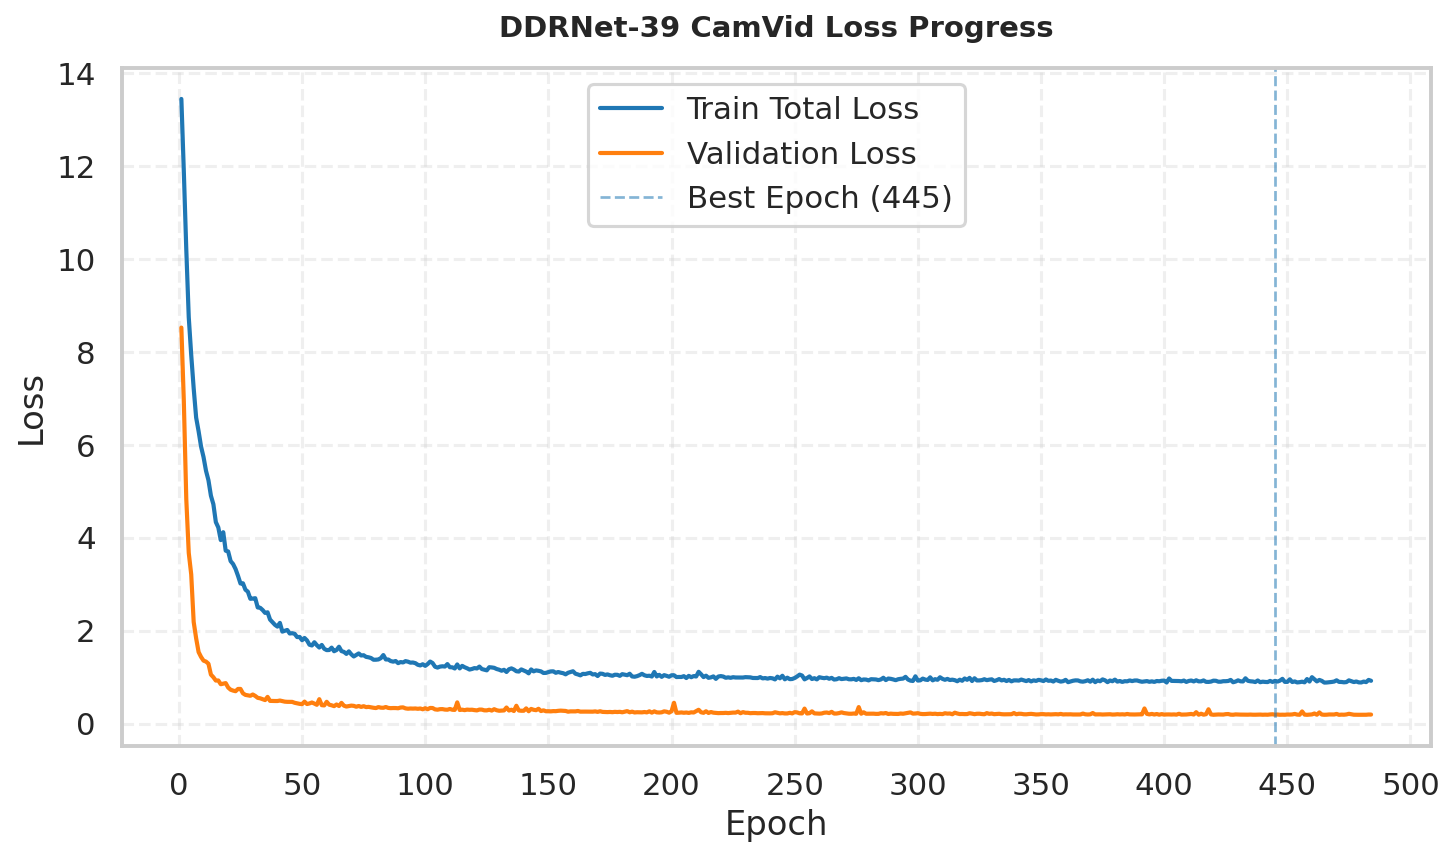

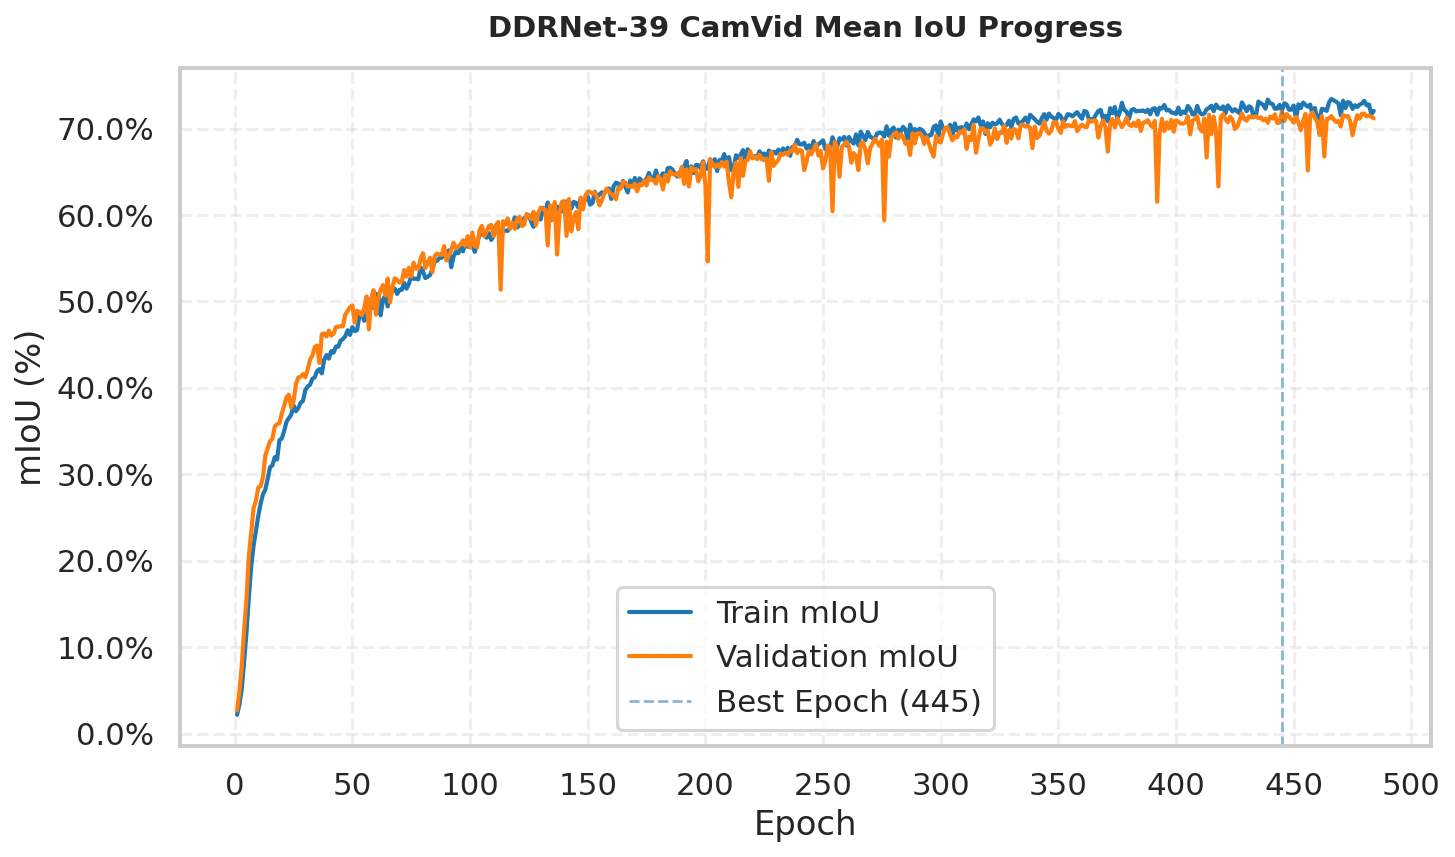

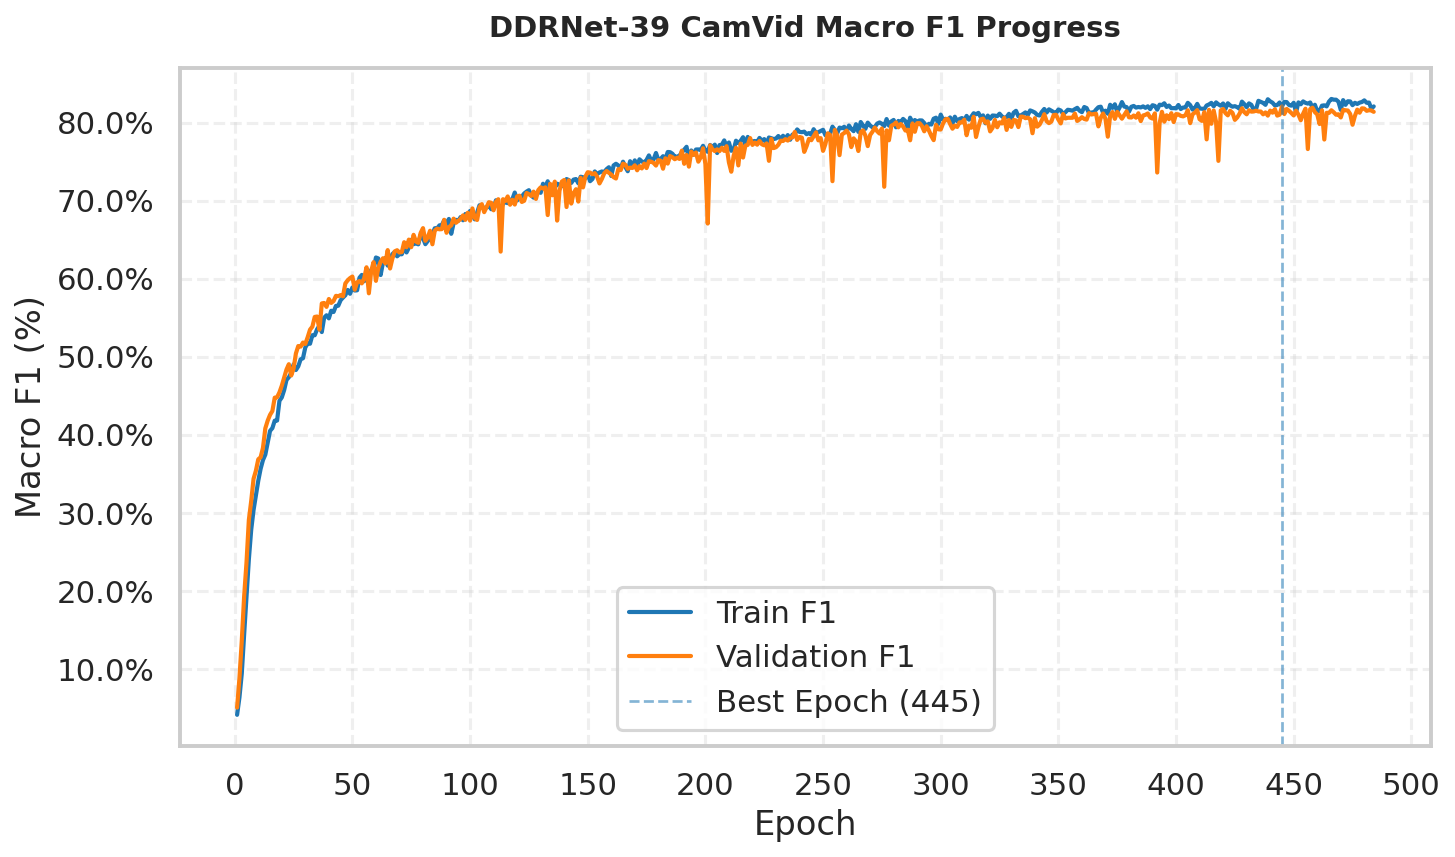

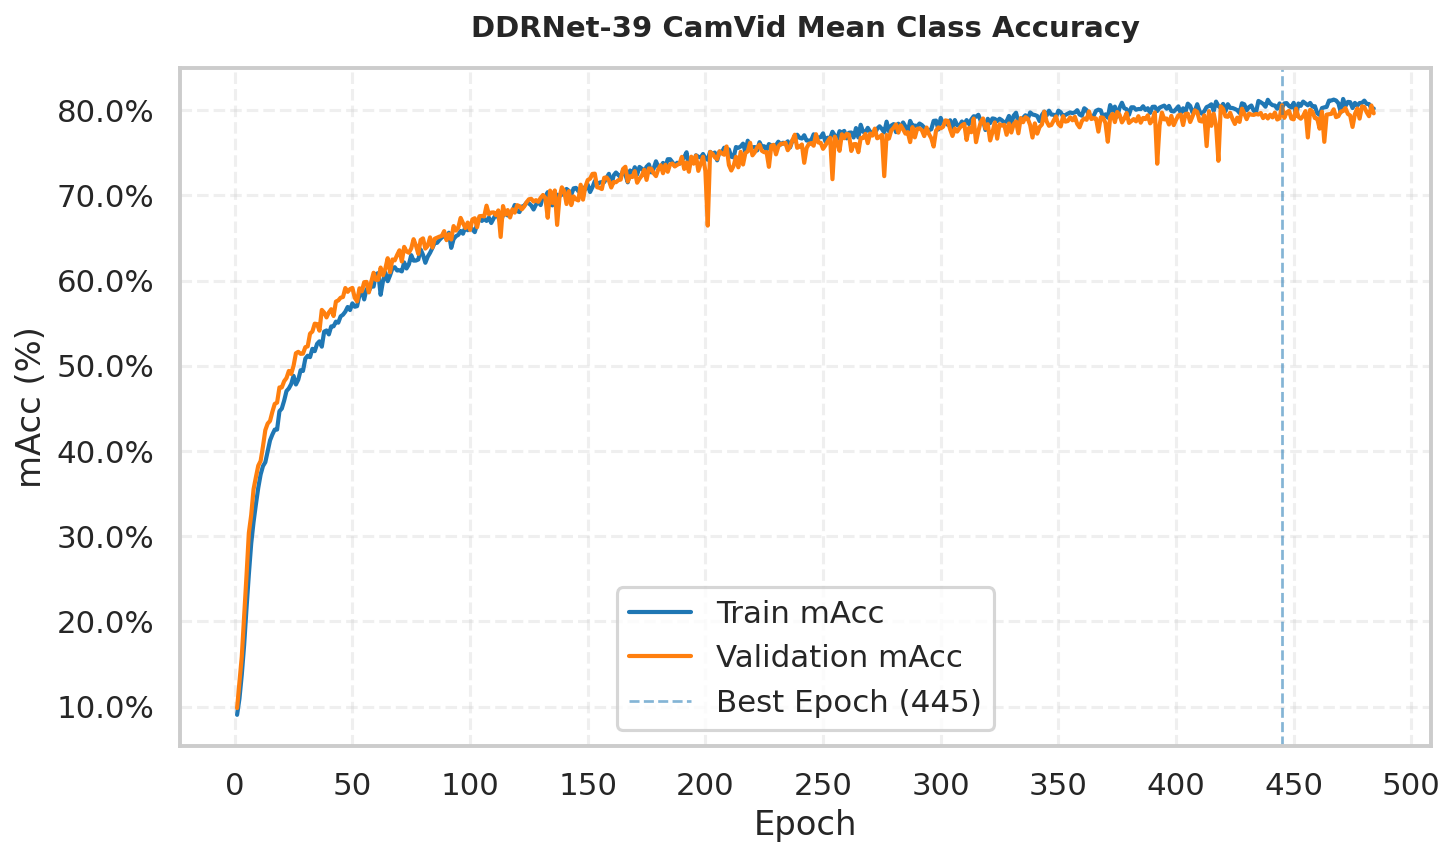

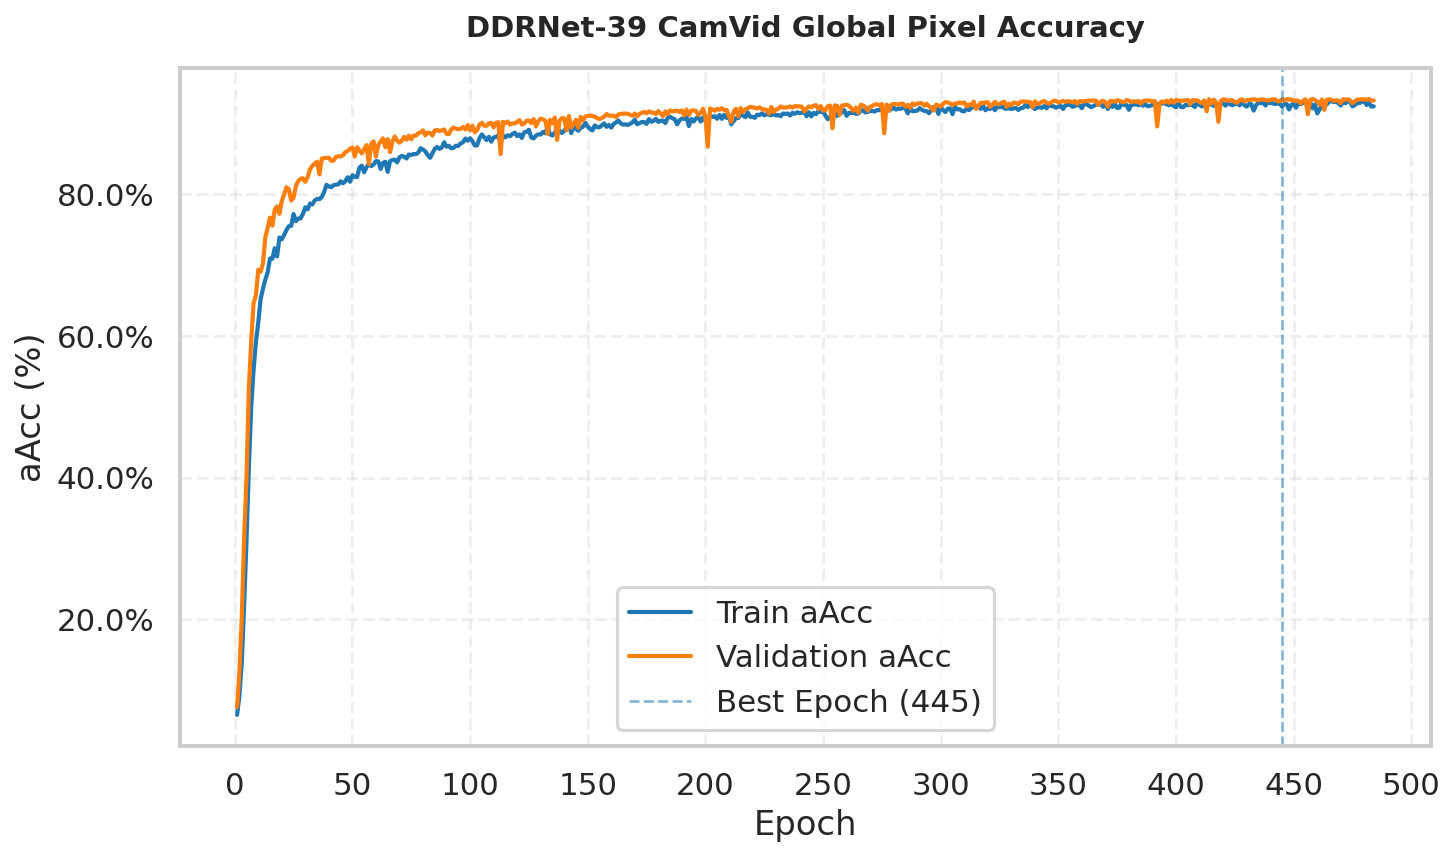

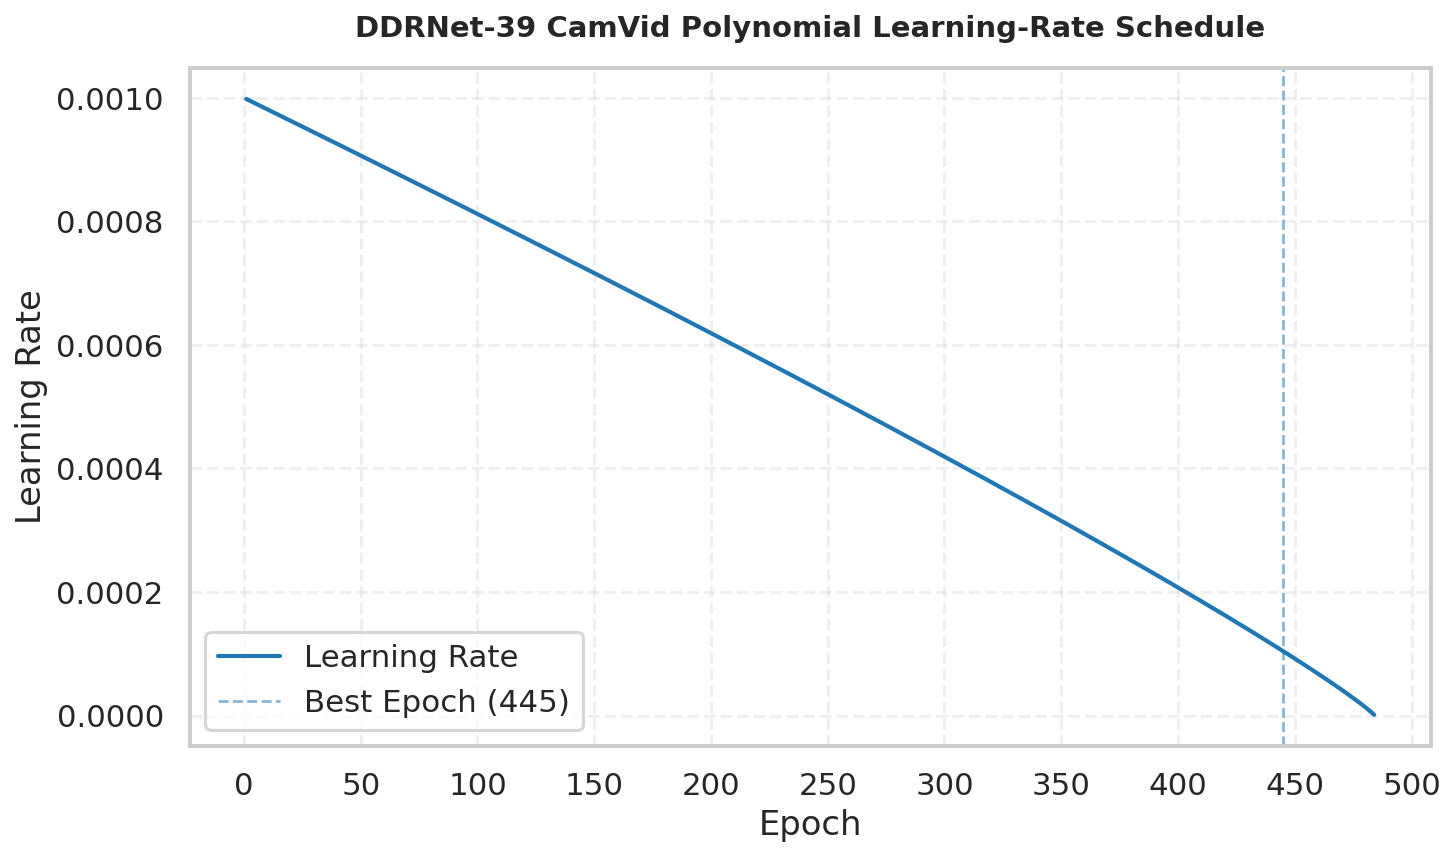

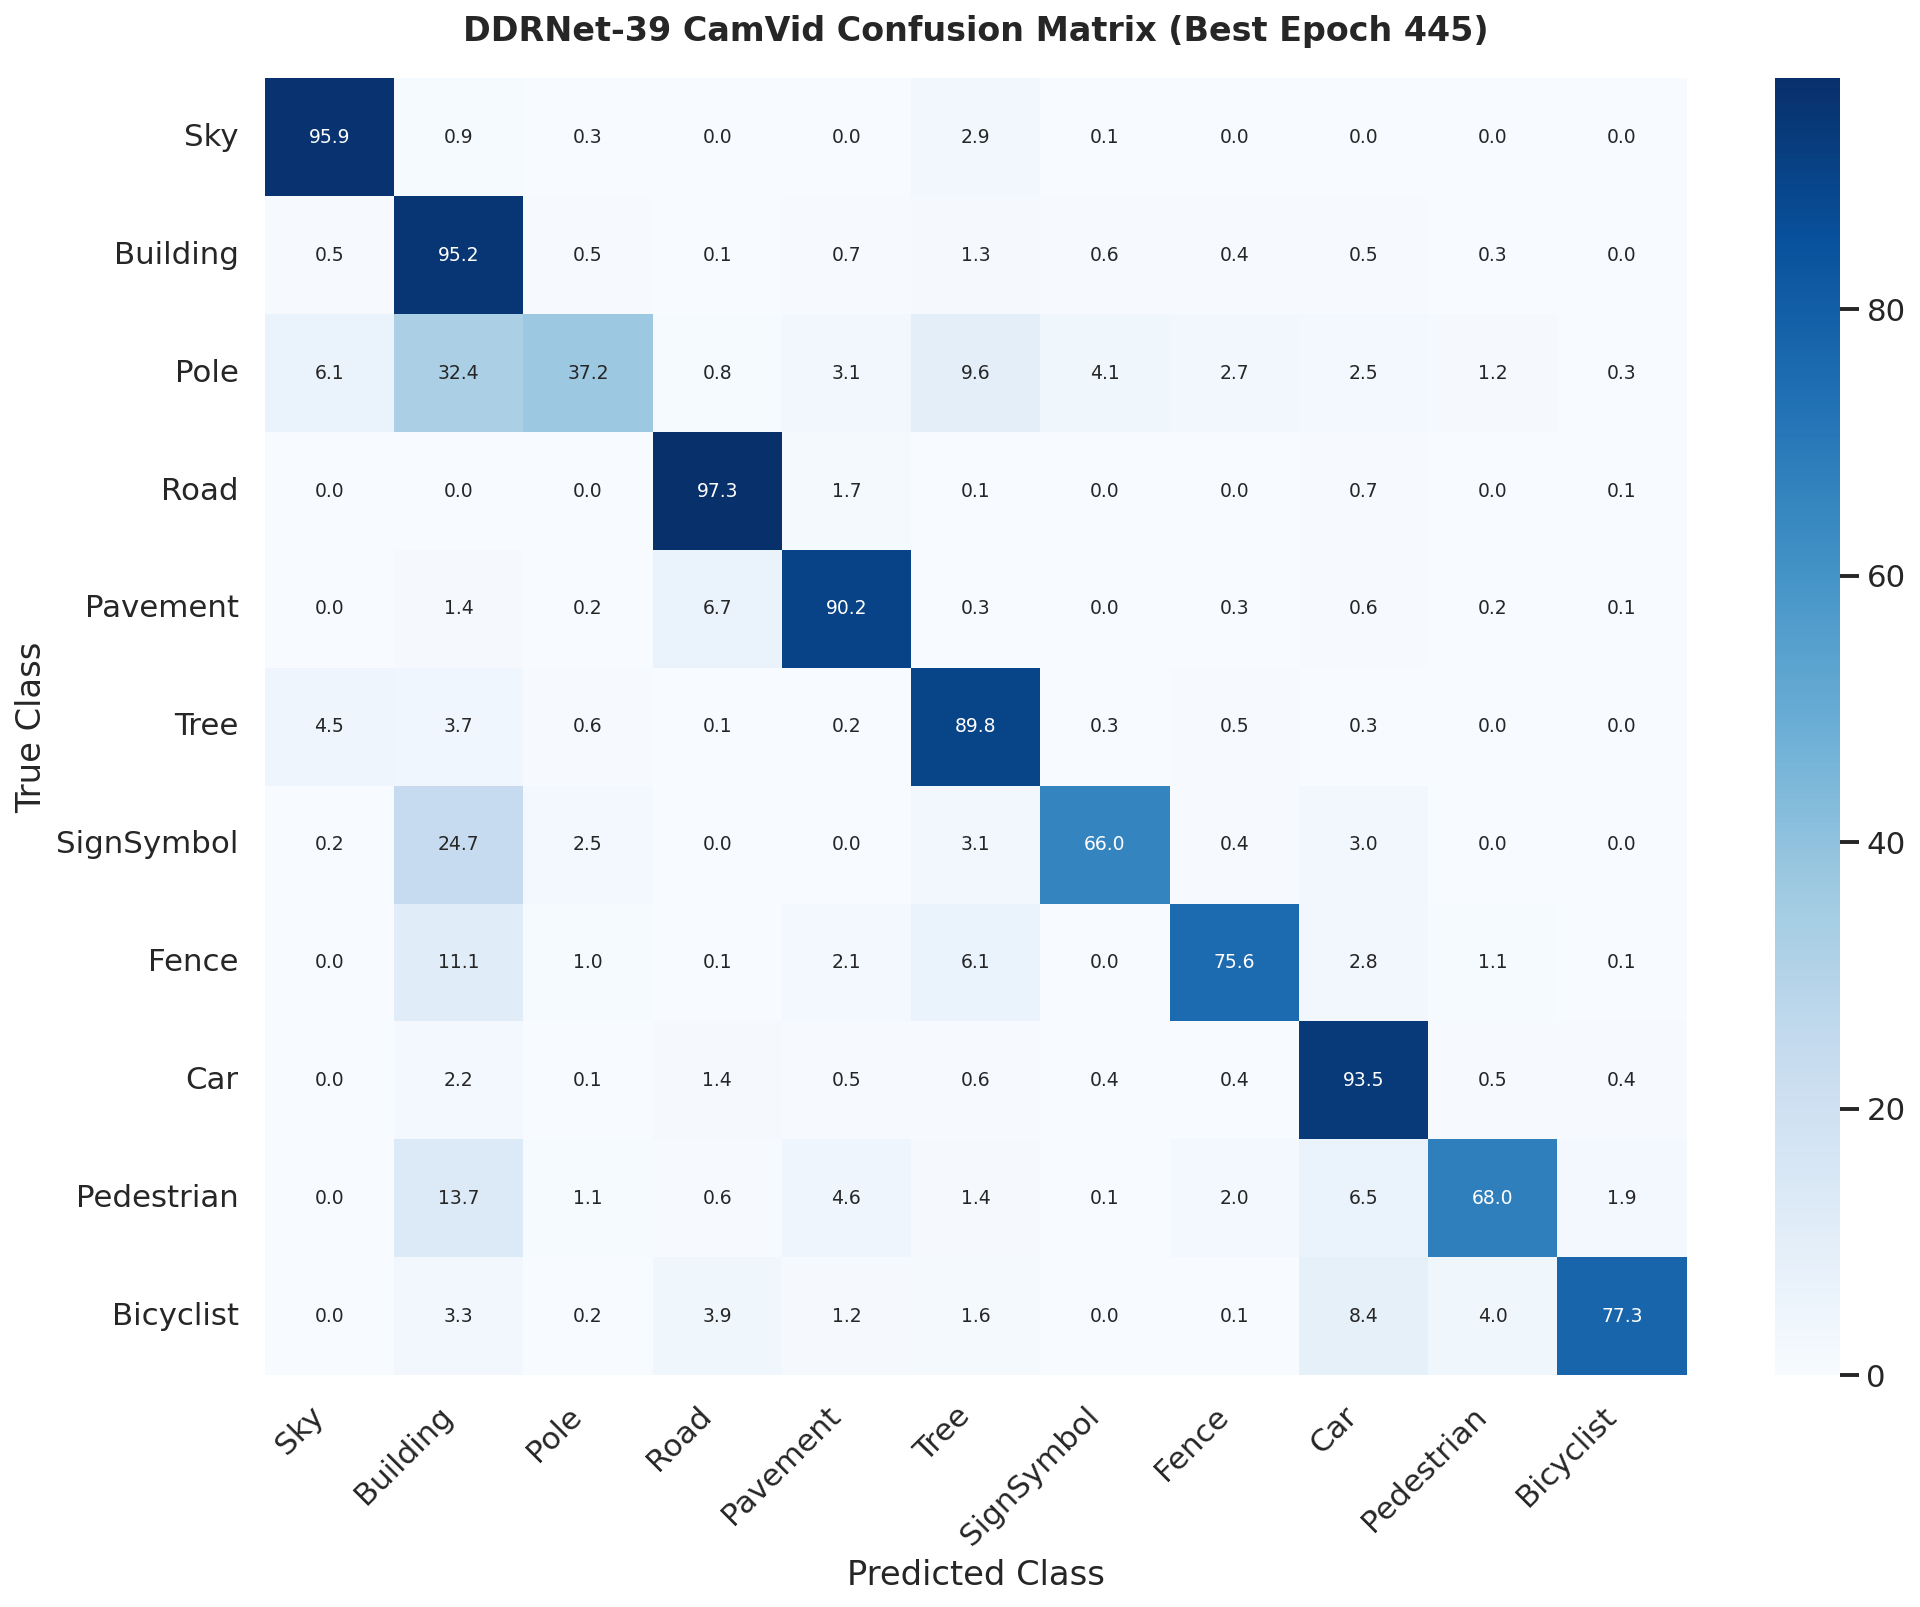


DDRNet-39 / CAMVID NORMALIZED CONFUSION MATRIX (%)


,Sky,Building,Pole,Road,Pavement,Tree,SignSymbol,Fence,Car,Pedestrian,Bicyclist
Sky,95.88,0.89,0.27,0.00,0.00,2.89,0.06,0.00,0.02,0.00,0.00
Building,0.49,95.22,0.48,0.07,0.70,1.31,0.56,0.41,0.45,0.26,0.04
Pole,6.11,32.39,37.15,0.77,3.14,9.58,4.14,2.75,2.50,1.20,0.26
Road,0.00,0.02,0.01,97.34,1.73,0.10,0.00,0.01,0.70,0.01,0.06
Pavement,0.00,1.38,0.19,6.71,90.18,0.35,0.04,0.27,0.56,0.25,0.07
Tree,4.53,3.67,0.55,0.11,0.20,89.75,0.32,0.50,0.30,0.05,0.01
SignSymbol,0.18,24.67,2.50,0.01,0.05,3.10,66.01,0.43,2.99,0.02,0.04
Fence,0.00,11.14,0.96,0.12,2.10,6.13,0.03,75.61,2.79,1.08,0.05
Car,0.02,2.24,0.10,1.45,0.46,0.57,0.37,0.36,93.55,0.47,0.42
Pedestrian,0.00,13.69,1.10,0.63,4.63,1.37,0.10,2.03,6.47,68.04,1.93



FINAL RESULTS — DDRNet-39 / CAMVID
Architecture                    : DDRNet-39
Dataset                         : CamVid
Semantic Classes                : 11
Training Epoch Target           : 484
Best Epoch                      : 445
Pretraining                     : ImageNet
Cityscapes Semantic Pretraining : NO
Validation Protocol             : 720x960 / single-scale / no flip
Training Loss                   : OHEM + 0.4 × Auxiliary CE
----------------------------------------------------------------------------------------------------
Training Parameters             : 32,656,726 (32.66 M)
Auxiliary Parameters            : 298,507 (0.30 M)
Inference Parameters            : 32,358,219 (32.36 M)
Trainable Parameters            : 32,656,726
----------------------------------------------------------------------------------------------------
Best Validation mIoU            : 71.97%
Best Validation mAcc            : 80.55%
Best Validation aAcc            : 93.46%
Best Validation Macro F1    

In [14]:
# ============================================================
# STEP 6 — DDRNet-39 / CAMVID
#
# BEST-CHECKPOINT FINAL VALIDATION EVALUATION
# CLASS-WISE METRICS
# CONFUSION MATRIX
# CSV / EXCEL EXPORT
# FINAL REPORT FIGURES
#
# IMPORTANT:
#
#   - Uses paths already defined in Step 1.
#   - No path is redefined here.
#   - EPOCHS must remain 484.
#   - Reloads BEST checkpoint from disk.
#   - Evaluates CamVid VALIDATION split only.
#   - CamVid TEST split remains untouched.
#   - Native 720 x 960 evaluation.
#   - Single-scale inference.
#   - No horizontal-flip TTA.
#   - Main DDRNet output only.
#   - Valid-pixel Cross-Entropy.
#   - Unknown/void pixels with label 255 are ignored.
#
# Initialization verification:
#
#       ImageNet pretrained DDRNet-39 = YES
#       Cityscapes semantic weights  = NO
#
# Output organization:
#
# FINAL_SAVE_DIR
#       Complete Excel report
#
# LOGS_DIR
#       Complete epoch metrics CSV
#
# METRICS_DIR
#       Final results CSV
#       Class-wise metrics CSV
#       Raw confusion matrix CSV
#       Normalized confusion matrix CSV
#
# PLOTS_DIR
#       Final 600-DPI figures
#
# QUAL_VIS_DIR
#       Best-checkpoint qualitative visualization
#
# Notebook safety:
#
#       Reconstruction tqdm leave=False
#       Last 25 history rows only
#       11-class table displayed once
#       Global result table displayed once
#       Confusion matrix displayed once
#       Final plots displayed once
#
# No retraining.
# No ONNX.
# ============================================================


# ============================================================
# 1. DISPLAY IMPORT
# ============================================================

from IPython.display import display


# ============================================================
# 2. REQUIRED DEPENDENCY CHECK
# ============================================================

required_globals = [

    # --------------------------------------------------------
    # Training result
    # --------------------------------------------------------

    "history",
    "best_record",

    # --------------------------------------------------------
    # Architecture
    # --------------------------------------------------------

    "DDRNet39",
    "extract_main_logits",

    # --------------------------------------------------------
    # Metrics / loss helpers from Steps 4-5
    # --------------------------------------------------------

    "safe_cross_entropy_sum_and_count",
    "compute_segmentation_metrics",
    "update_confusion_matrix_gpu",

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    "val_loader",
    "test_loader",
    "CLASS_NAMES",
    "CLASSES",
    "IGNORE_INDEX",

    # --------------------------------------------------------
    # Geometry
    # --------------------------------------------------------

    "IMG_H",
    "IMG_W",
    "ALIGN_CORNERS",

    # --------------------------------------------------------
    # Runtime
    # --------------------------------------------------------

    "DEVICE",
    "USE_AMP",

    # --------------------------------------------------------
    # Experiment
    # --------------------------------------------------------

    "EPOCHS",
    "EXPERIMENT_NAME",
    "TRAINING_PROTOCOL_NAME",

    "USE_IMAGENET_PRETRAINED",
    "USE_CITYSCAPES_PRETRAINED",
    "ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS",
    "PRETRAINING_SOURCE",

    # --------------------------------------------------------
    # Paths from Step 1
    # --------------------------------------------------------

    "FINAL_SAVE_DIR",
    "QUAL_VIS_DIR",
    "CHECKPOINT_DIR",
    "PLOTS_DIR",
    "LOGS_DIR",
    "METRICS_DIR",

    "BEST_CHECKPOINT",
    "LATEST_CHECKPOINT",
    "HISTORY_FILE",

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    "visualize_results",

    # --------------------------------------------------------
    # Plot libraries imported in Step 1
    # --------------------------------------------------------

    "plt",
    "mtick",
    "sns",
]


missing_globals = [

    name

    for name in required_globals

    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Execute the corrected Steps 1-5 first.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 3. EXPERIMENT SAFETY CHECK
# ============================================================

if CLASSES != 11:

    raise RuntimeError(
        "DDRNet-39 CamVid evaluation requires 11 classes."
    )


if len(
    CLASS_NAMES
) != CLASSES:

    raise RuntimeError(
        "CLASS_NAMES length does not match CLASSES."
    )


if EPOCHS != 484:

    raise RuntimeError(
        "Current DDRNet-39 CamVid experiment "
        "must use 484 epochs."
    )


if not USE_IMAGENET_PRETRAINED:

    raise RuntimeError(
        "ImageNet initialization must remain enabled."
    )


if USE_CITYSCAPES_PRETRAINED:

    raise RuntimeError(
        "Cityscapes semantic initialization "
        "must remain disabled."
    )


if ALLOW_CITYSCAPES_SEMANTIC_WEIGHTS:

    raise RuntimeError(
        "Cityscapes semantic weights must remain blocked."
    )


if str(
    PRETRAINING_SOURCE
).lower() != "imagenet":

    raise RuntimeError(
        "PRETRAINING_SOURCE must remain 'ImageNet'."
    )


if len(
    val_loader
) == 0:

    raise RuntimeError(
        "CamVid validation DataLoader is empty."
    )


if len(
    history.get(
        "epoch",
        []
    )
) == 0:

    raise RuntimeError(
        "Training history is empty."
    )


# ============================================================
# 4. VERIFY OUTPUT DIRECTORIES
# ============================================================
#
# Paths are NOT redefined.
# Only existing Step-1 values are used.
# ============================================================

for directory in [

    FINAL_SAVE_DIR,
    QUAL_VIS_DIR,
    CHECKPOINT_DIR,
    PLOTS_DIR,
    LOGS_DIR,
    METRICS_DIR,

]:

    Path(
        directory
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 5. NOTEBOOK-SAFE FINAL REPORT SETTINGS
# ============================================================

REPORT_TQDM_LEAVE = False


MAX_REPORT_HISTORY_ROWS = globals().get(
    "MAX_NOTEBOOK_TABLE_ROWS",
    25
)


DISPLAY_REPORT_PLOTS = globals().get(
    "DISPLAY_FINAL_REPORT_PLOTS",
    True
)


USE_CHANNELS_LAST_REPORT = globals().get(
    "USE_CHANNELS_LAST",
    DEVICE.type == "cuda"
)


# ============================================================
# 6. BEST CHECKPOINT PATH
# ============================================================

best_ckpt_path = Path(
    BEST_CHECKPOINT
)


if not best_ckpt_path.exists():

    raise FileNotFoundError(
        "DDRNet-39 BEST checkpoint was not found:\n"
        f"{best_ckpt_path}"
    )


# ============================================================
# 7. LOAD BEST CHECKPOINT
# ============================================================

try:

    best_checkpoint = torch.load(
        best_ckpt_path,
        map_location=DEVICE,
        weights_only=False
    )


except TypeError:

    best_checkpoint = torch.load(
        best_ckpt_path,
        map_location=DEVICE
    )


if not isinstance(
    best_checkpoint,
    dict
):

    raise TypeError(
        "Best checkpoint must contain a dictionary."
    )


if (
    "model_state_dict"
    not in best_checkpoint
):

    raise KeyError(
        "model_state_dict is missing from BEST checkpoint."
    )


# ============================================================
# 8. STRICT CHECKPOINT IDENTITY VERIFICATION
# ============================================================

checkpoint_experiment = str(
    best_checkpoint.get(
        "experiment_name",
        ""
    )
)


checkpoint_protocol = str(
    best_checkpoint.get(
        "training_protocol_name",
        ""
    )
)


checkpoint_dataset = str(
    best_checkpoint.get(
        "dataset_name",
        ""
    )
)


checkpoint_model = str(
    best_checkpoint.get(
        "model_name",
        ""
    )
)


checkpoint_classes = int(
    best_checkpoint.get(
        "num_classes",
        -1
    )
)


checkpoint_epochs = int(
    best_checkpoint.get(
        "total_epochs",
        EPOCHS
    )
)


checkpoint_pretraining = str(
    best_checkpoint.get(
        "pretraining_source",
        ""
    )
)


checkpoint_imagenet = bool(
    best_checkpoint.get(
        "use_imagenet_pretrained",
        False
    )
)


checkpoint_cityscapes = bool(
    best_checkpoint.get(
        "use_cityscapes_pretrained",
        True
    )
)


checkpoint_cityscapes_allowed = bool(
    best_checkpoint.get(
        "allow_cityscapes_semantic_weights",
        True
    )
)


if (
    checkpoint_experiment
    != EXPERIMENT_NAME
):

    raise RuntimeError(
        "BEST checkpoint experiment mismatch.\n"
        f"Checkpoint : {checkpoint_experiment}\n"
        f"Current    : {EXPERIMENT_NAME}"
    )


if (
    checkpoint_protocol
    != TRAINING_PROTOCOL_NAME
):

    raise RuntimeError(
        "BEST checkpoint training protocol mismatch.\n"
        f"Checkpoint : {checkpoint_protocol}\n"
        f"Current    : {TRAINING_PROTOCOL_NAME}"
    )


if checkpoint_dataset.lower() != "camvid":

    raise RuntimeError(
        "BEST checkpoint belongs to another dataset."
    )


if checkpoint_model != "DDRNet-39":

    raise RuntimeError(
        "BEST checkpoint architecture mismatch."
    )


if checkpoint_classes != CLASSES:

    raise RuntimeError(
        "BEST checkpoint class-count mismatch."
    )


if checkpoint_epochs != EPOCHS:

    raise RuntimeError(
        "BEST checkpoint epoch configuration mismatch.\n"
        f"Checkpoint epochs : {checkpoint_epochs}\n"
        f"Current epochs    : {EPOCHS}"
    )


if checkpoint_pretraining.lower() != "imagenet":

    raise RuntimeError(
        "BEST checkpoint is not ImageNet initialized."
    )


if not checkpoint_imagenet:

    raise RuntimeError(
        "BEST checkpoint metadata says ImageNet "
        "initialization was disabled."
    )


if checkpoint_cityscapes:

    raise RuntimeError(
        "BEST checkpoint contains Cityscapes "
        "semantic-pretraining metadata."
    )


if checkpoint_cityscapes_allowed:

    raise RuntimeError(
        "BEST checkpoint allowed Cityscapes semantic weights."
    )


print(
    "[✓] BEST checkpoint identity verified."
)


# ============================================================
# 9. BEST-EPOCH INFORMATION
# ============================================================

checkpoint_best_record = best_checkpoint.get(
    "best_record",
    {}
)


best_epoch = int(

    checkpoint_best_record.get(

        "best_epoch",

        checkpoint_best_record.get(

            "epoch",

            best_checkpoint.get(
                "epoch",
                -1
            )
        )
    )
)


stored_best_miou = float(

    checkpoint_best_record.get(

        "best_miou",

        best_record.get(
            "best_miou",
            -1.0
        )
    )
)


checkpoint_epoch = int(
    best_checkpoint.get(
        "epoch",
        best_epoch
    )
)


if best_epoch <= 0:

    raise RuntimeError(
        "Invalid BEST epoch stored in checkpoint."
    )


print(
    "\n--- BEST DDRNet-39 Checkpoint ---"
)


print(
    f"[*] Path             : "
    f"{best_ckpt_path}"
)


print(
    f"[*] Best epoch       : "
    f"{best_epoch}"
)


print(
    f"[*] Checkpoint epoch : "
    f"{checkpoint_epoch}"
)


print(
    f"[*] Stored Val mIoU  : "
    f"{stored_best_miou:.4f}%"
)


# ============================================================
# 10. CREATE CLEAN EVALUATION MODEL
# ============================================================
#
# No ImageNet checkpoint needs to be loaded here.
#
# The BEST training checkpoint contains the complete DDRNet-39
# state, including:
#
#       backbone
#       DAPPM
#       main segmentation head
#       auxiliary head
#
# Therefore we construct the architecture and load the complete
# BEST model state directly.
# ============================================================

model = DDRNet39(
    num_classes=CLASSES,
    augment=True
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model = model.to(
    DEVICE
)


if USE_CHANNELS_LAST_REPORT:

    model = model.to(
        memory_format=torch.channels_last
    )


model.eval()


print(
    "[✓] BEST DDRNet-39 model weights loaded."
)


# ============================================================
# 11. BEST VALIDATION RECONSTRUCTION
# ============================================================
#
# Protocol:
#
#       CamVid validation split
#       native 720 x 960
#       single-scale
#       no horizontal flip
#       main DDRNet output only
#
# Everything remains on GPU during batch processing.
#
# Only the final 11 x 11 confusion matrix is moved to CPU.
# ============================================================

print(
    "\n[*] Reconstructing BEST-checkpoint "
    "validation results..."
)


best_confusion_gpu = torch.zeros(

    (
        CLASSES,
        CLASSES
    ),

    dtype=torch.int64,

    device=DEVICE
)


best_class_image_counts = np.zeros(
    CLASSES,
    dtype=np.int64
)


best_val_loss_sum = 0.0


best_val_valid_pixels = 0


best_val_ignore_pixels = 0


best_val_total_pixels = 0


best_val_processed_images = 0


best_val_zero_valid_images = 0


reconstruction_pbar = tqdm(

    val_loader,

    total=len(
        val_loader
    ),

    desc="BEST CamVid Validation",

    leave=REPORT_TQDM_LEAVE,

    dynamic_ncols=True,

    mininterval=1.0
)


with torch.inference_mode():


    for validation_step, (
        images,
        masks
    ) in enumerate(
        reconstruction_pbar,
        start=1
    ):


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        masks = masks.to(
            DEVICE,
            non_blocking=True
        )


        if USE_CHANNELS_LAST_REPORT:

            images = images.contiguous(
                memory_format=torch.channels_last
            )


        # ====================================================
        # FORWARD
        # ====================================================

        with autocast(

            device_type=DEVICE.type,

            enabled=USE_AMP
        ):

            outputs = model(
                images
            )


            main_logits = extract_main_logits(
                outputs
            )


        # ====================================================
        # VALID-PIXEL CROSS-ENTROPY
        #
        # This helper also resizes the 1/8 DDRNet prediction
        # back to the native target resolution.
        # ====================================================

        (
            batch_loss_sum,
            batch_valid_pixels,
            semantic_logits

        ) = safe_cross_entropy_sum_and_count(

            main_logits,

            masks,

            ignore_index=IGNORE_INDEX
        )


        # ====================================================
        # FINITENESS CHECK
        # ====================================================

        if not bool(
            torch.isfinite(
                semantic_logits
            ).all().item()
        ):

            raise FloatingPointError(
                "Non-finite prediction found during "
                "BEST-checkpoint reconstruction.\n"
                f"Validation step: {validation_step}"
            )


        if (
            batch_valid_pixels > 0

            and

            not bool(
                torch.isfinite(
                    batch_loss_sum
                ).item()
            )
        ):

            raise FloatingPointError(
                "Non-finite validation loss found during "
                "BEST-checkpoint reconstruction.\n"
                f"Validation step: {validation_step}"
            )


        # ====================================================
        # LOSS STATISTICS
        # ====================================================

        batch_total_pixels = int(
            masks.numel()
        )


        batch_ignore_pixels = (
            batch_total_pixels
            - batch_valid_pixels
        )


        best_val_total_pixels += (
            batch_total_pixels
        )


        best_val_ignore_pixels += (
            batch_ignore_pixels
        )


        if batch_valid_pixels > 0:

            best_val_loss_sum += float(
                batch_loss_sum
                .detach()
                .item()
            )


            best_val_valid_pixels += int(
                batch_valid_pixels
            )


        else:

            best_val_zero_valid_images += int(
                images.shape[0]
            )


        # ====================================================
        # GPU CONFUSION MATRIX
        # ====================================================

        update_confusion_matrix_gpu(

            best_confusion_gpu,

            semantic_logits,

            masks
        )


        # ====================================================
        # PER-CLASS IMAGE SUPPORT
        # ====================================================

        masks_np = (
            masks
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.int64,
                copy=False
            )
        )


        for sample_index in range(
            masks_np.shape[0]
        ):


            sample_target = (
                masks_np[
                    sample_index
                ]
            )


            valid_target = (
                sample_target
                != IGNORE_INDEX
            )


            if valid_target.any():


                present_classes = np.unique(
                    sample_target[
                        valid_target
                    ]
                )


                valid_classes = present_classes[
                    (
                        present_classes >= 0
                    )
                    &
                    (
                        present_classes < CLASSES
                    )
                ]


                best_class_image_counts[
                    valid_classes.astype(
                        np.int64
                    )
                ] += 1


            best_val_processed_images += 1


        del outputs
        del main_logits
        del semantic_logits


reconstruction_pbar.close()


# ============================================================
# 12. RECONSTRUCTED VALIDATION LOSS
# ============================================================

if best_val_valid_pixels <= 0:

    raise RuntimeError(
        "No valid validation pixels were found."
    )


reconstructed_best_val_loss = (

    best_val_loss_sum

    / float(
        best_val_valid_pixels
    )
)


if not np.isfinite(
    reconstructed_best_val_loss
):

    raise FloatingPointError(
        "Reconstructed validation loss is non-finite."
    )


valid_pixel_fraction = (

    best_val_valid_pixels

    / max(
        best_val_total_pixels,
        1
    )
)


ignore_pixel_fraction = (

    best_val_ignore_pixels

    / max(
        best_val_total_pixels,
        1
    )
)


# ============================================================
# 13. MOVE FINAL CONFUSION MATRIX TO CPU
# ============================================================

BEST_CONF_MATRIX = (

    best_confusion_gpu
    .detach()
    .cpu()
    .numpy()
)


del best_confusion_gpu


# ============================================================
# 14. GLOBAL METRICS
# ============================================================

BEST_METRICS = (
    compute_segmentation_metrics(
        BEST_CONF_MATRIX
    )
)


reconstructed_best_miou = (

    BEST_METRICS[
        "mIoU_Macro"
    ]

    * 100.0
)


reconstructed_best_macc = (

    BEST_METRICS[
        "Recall_Macro"
    ]

    * 100.0
)


reconstructed_best_aacc = (

    BEST_METRICS[
        "Global_Accuracy"
    ]

    * 100.0
)


reconstructed_best_precision = (

    BEST_METRICS[
        "Precision_Macro"
    ]

    * 100.0
)


reconstructed_best_f1 = (

    BEST_METRICS[
        "F1_Macro"
    ]

    * 100.0
)


reconstructed_best_micro_precision = (

    BEST_METRICS[
        "Precision_Micro"
    ]

    * 100.0
)


reconstructed_best_micro_recall = (

    BEST_METRICS[
        "Recall_Micro"
    ]

    * 100.0
)


reconstructed_best_micro_f1 = (

    BEST_METRICS[
        "F1_Micro"
    ]

    * 100.0
)


# ============================================================
# 15. MICRO IoU
# ============================================================

global_tp = float(
    np.diag(
        BEST_CONF_MATRIX
    ).sum()
)


global_fp = float(
    (
        BEST_CONF_MATRIX.sum(
            axis=0
        )
        -
        np.diag(
            BEST_CONF_MATRIX
        )
    ).sum()
)


global_fn = float(
    (
        BEST_CONF_MATRIX.sum(
            axis=1
        )
        -
        np.diag(
            BEST_CONF_MATRIX
        )
    ).sum()
)


reconstructed_best_micro_iou = (

    global_tp

    / max(
        global_tp
        + global_fp
        + global_fn,
        1.0
    )

    * 100.0
)


# ============================================================
# 16. RECONSTRUCTION SUMMARY
# ============================================================

print(
    "\n--- BEST Validation Reconstruction ---"
)


print(
    f"[*] Validation images      : "
    f"{best_val_processed_images}"
)


print(
    f"[*] Valid semantic pixels  : "
    f"{best_val_valid_pixels:,}"
)


print(
    f"[*] Ignored pixels         : "
    f"{best_val_ignore_pixels:,}"
)


print(
    f"[*] Valid pixel fraction   : "
    f"{valid_pixel_fraction * 100.0:.4f}%"
)


print(
    f"[*] Ignore pixel fraction  : "
    f"{ignore_pixel_fraction * 100.0:.4f}%"
)


print(
    f"[*] All-ignore images      : "
    f"{best_val_zero_valid_images}"
)


print(
    f"[*] Validation Loss        : "
    f"{reconstructed_best_val_loss:.6f}"
)


print(
    f"[*] Validation mIoU        : "
    f"{reconstructed_best_miou:.4f}%"
)


print(
    f"[*] Validation mAcc        : "
    f"{reconstructed_best_macc:.4f}%"
)


print(
    f"[*] Validation aAcc        : "
    f"{reconstructed_best_aacc:.4f}%"
)


# ============================================================
# 17. STORED-vs-RECONSTRUCTED mIoU CHECK
# ============================================================

miou_difference = abs(

    reconstructed_best_miou

    - stored_best_miou
)


BEST_MIOU_TOLERANCE_PP = 0.10


print(
    "\n--- BEST Checkpoint Consistency ---"
)


print(
    f"Stored mIoU        : "
    f"{stored_best_miou:.4f}%"
)


print(
    f"Reconstructed mIoU : "
    f"{reconstructed_best_miou:.4f}%"
)


print(
    f"Difference         : "
    f"{miou_difference:.6f} percentage points"
)


if (
    miou_difference
    > BEST_MIOU_TOLERANCE_PP
):

    raise RuntimeError(
        "Reconstructed BEST validation mIoU differs from "
        "the checkpoint value by more than "
        f"{BEST_MIOU_TOLERANCE_PP:.2f} percentage points.\n"
        "The model, preprocessing, validation split, or "
        "inference protocol may have changed."
    )


print(
    "[✓] Stored and reconstructed BEST mIoU are consistent."
)


# ============================================================
# 18. COMPLETE HISTORY DATAFRAME
# ============================================================

num_history_epochs = len(
    history[
        "epoch"
    ]
)


def get_history_column(
    key
):

    values = list(
        history.get(
            key,
            []
        )
    )


    if len(
        values
    ) > num_history_epochs:

        values = values[
            :num_history_epochs
        ]


    elif len(
        values
    ) < num_history_epochs:

        values.extend(

            [
                np.nan
            ]

            * (
                num_history_epochs
                - len(
                    values
                )
            )
        )


    return values


epoch_metrics_df = pd.DataFrame(
    {

        "Epoch":
            get_history_column(
                "epoch"
            ),

        "Phase":
            get_history_column(
                "phase"
            ),

        "Train_Total_Loss":
            get_history_column(
                "train_total_loss"
            ),

        "Train_Main_OHEM_Loss":
            get_history_column(
                "train_main_loss"
            ),

        "Train_Aux_Loss":
            get_history_column(
                "train_aux_loss"
            ),

        "Validation_Loss":
            get_history_column(
                "val_total_loss"
            ),

        "Train_mIoU":
            get_history_column(
                "train_miou"
            ),

        "Validation_mIoU":
            get_history_column(
                "val_miou"
            ),

        "Train_mAcc":
            get_history_column(
                "train_macc"
            ),

        "Validation_mAcc":
            get_history_column(
                "val_macc"
            ),

        "Train_aAcc":
            get_history_column(
                "train_aacc"
            ),

        "Validation_aAcc":
            get_history_column(
                "val_aacc"
            ),

        "Train_Precision_Macro":
            get_history_column(
                "train_Precision_Macro"
            ),

        "Validation_Precision_Macro":
            get_history_column(
                "val_Precision_Macro"
            ),

        "Train_Recall_Macro":
            get_history_column(
                "train_Recall_Macro"
            ),

        "Validation_Recall_Macro":
            get_history_column(
                "val_Recall_Macro"
            ),

        "Train_F1_Macro":
            get_history_column(
                "train_F1_Macro"
            ),

        "Validation_F1_Macro":
            get_history_column(
                "val_F1_Macro"
            ),

        "Train_Precision_Micro":
            get_history_column(
                "train_Precision_Micro"
            ),

        "Validation_Precision_Micro":
            get_history_column(
                "val_Precision_Micro"
            ),

        "Train_Recall_Micro":
            get_history_column(
                "train_Recall_Micro"
            ),

        "Validation_Recall_Micro":
            get_history_column(
                "val_Recall_Micro"
            ),

        "Train_F1_Micro":
            get_history_column(
                "train_F1_Micro"
            ),

        "Validation_F1_Micro":
            get_history_column(
                "val_F1_Micro"
            ),

        "Learning_Rate":
            get_history_column(
                "learning_rate"
            ),

        "AMP_Scale":
            get_history_column(
                "amp_scale"
            ),

        "AMP_Overflow_Skips":
            get_history_column(
                "amp_overflow_skips"
            ),

        "Epoch_Time_sec":
            get_history_column(
                "epoch_time_sec"
            ),

        "Cumulative_Training_Time":
            get_history_column(
                "total_training_time_str"
            ),
    }
)


# ============================================================
# 19. TRAINING COMPLETION STATUS
# ============================================================

last_history_epoch = int(
    epoch_metrics_df[
        "Epoch"
    ].iloc[
        -1
    ]
)


if last_history_epoch < EPOCHS:

    warnings.warn(
        "Step 6 is evaluating the current BEST checkpoint "
        "from a partially completed training run.\n"
        f"Last completed epoch: {last_history_epoch}\n"
        f"Target epoch        : {EPOCHS}"
    )


# ============================================================
# 20. BEST HISTORY ROW
# ============================================================

if best_epoch in epoch_metrics_df[
    "Epoch"
].tolist():

    best_history_index = (

        epoch_metrics_df[
            "Epoch"
        ]
        .tolist()
        .index(
            best_epoch
        )
    )


else:

    validation_miou_array = (

        epoch_metrics_df[
            "Validation_mIoU"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    if not np.isfinite(
        validation_miou_array
    ).any():

        raise RuntimeError(
            "No finite validation mIoU exists in history."
        )


    best_history_index = int(
        np.nanargmax(
            validation_miou_array
        )
    )


historical_best_val_loss = float(

    epoch_metrics_df.iloc[
        best_history_index
    ][
        "Validation_Loss"
    ]
)


if np.isfinite(
    historical_best_val_loss
):

    historical_best_val_loss_text = (
        f"{historical_best_val_loss:.6f}"
    )


else:

    historical_best_val_loss_text = (
        "Unavailable"
    )


# ============================================================
# 21. TOTAL TRAINING TIME
# ============================================================

checkpoint_total_training_time = best_checkpoint.get(
    "total_training_time"
)


if checkpoint_total_training_time is not None:

    total_training_time_sec = float(
        checkpoint_total_training_time
    )


elif (
    "cumulative_training_time_sec"
    in globals()
):

    total_training_time_sec = float(
        cumulative_training_time_sec
    )


else:

    total_training_time_sec = float(
        np.nansum(
            epoch_metrics_df[
                "Epoch_Time_sec"
            ].to_numpy(
                dtype=np.float64
            )
        )
    )


total_training_time_text = str(
    datetime.timedelta(
        seconds=int(
            total_training_time_sec
        )
    )
)


# ============================================================
# 22. CLASS-WISE METRICS
# ============================================================

true_positive = np.diag(
    BEST_CONF_MATRIX
).astype(
    np.float64
)


gt_pixel_counts = (
    BEST_CONF_MATRIX.sum(
        axis=1
    )
).astype(
    np.int64
)


prediction_pixel_counts = (
    BEST_CONF_MATRIX.sum(
        axis=0
    )
).astype(
    np.int64
)


false_positive = (

    prediction_pixel_counts
    .astype(
        np.float64
    )

    - true_positive
)


false_negative = (

    gt_pixel_counts
    .astype(
        np.float64
    )

    - true_positive
)


iou_denominator = (

    true_positive
    + false_positive
    + false_negative
)


precision_denominator = (

    true_positive
    + false_positive
)


recall_denominator = (

    true_positive
    + false_negative
)


iou_per_class = np.divide(

    true_positive,

    iou_denominator,

    out=np.full(
        CLASSES,
        np.nan,
        dtype=np.float64
    ),

    where=(
        iou_denominator > 0
    )
)


precision_per_class = np.divide(

    true_positive,

    precision_denominator,

    out=np.full(
        CLASSES,
        np.nan,
        dtype=np.float64
    ),

    where=(
        precision_denominator > 0
    )
)


recall_per_class = np.divide(

    true_positive,

    recall_denominator,

    out=np.full(
        CLASSES,
        np.nan,
        dtype=np.float64
    ),

    where=(
        recall_denominator > 0
    )
)


f1_denominator = (

    precision_per_class
    + recall_per_class
)


f1_per_class = np.divide(

    2.0
    * precision_per_class
    * recall_per_class,

    f1_denominator,

    out=np.full(
        CLASSES,
        np.nan,
        dtype=np.float64
    ),

    where=(
        np.isfinite(
            f1_denominator
        )
        &
        (
            f1_denominator > 0
        )
    )
)


# ============================================================
# 23. CLASS-WISE DATAFRAME
# ============================================================

class_wise_df = pd.DataFrame(
    {

        "Class ID":
            np.arange(
                CLASSES
            ),

        "Class Name":
            CLASS_NAMES,

        "Validation Images":
            best_class_image_counts,

        "GT Pixels":
            gt_pixel_counts,

        "Predicted Pixels":
            prediction_pixel_counts,

        "IoU (%)":
            iou_per_class
            * 100.0,

        "F1-Score (%)":
            f1_per_class
            * 100.0,

        "Precision (%)":
            precision_per_class
            * 100.0,

        "Recall / Class Accuracy (%)":
            recall_per_class
            * 100.0,
    }
)


# ============================================================
# 24. CONFUSION-MATRIX DATAFRAMES
# ============================================================

confusion_matrix_counts_df = pd.DataFrame(

    BEST_CONF_MATRIX,

    index=CLASS_NAMES,

    columns=CLASS_NAMES
)


row_sums = BEST_CONF_MATRIX.sum(
    axis=1,
    keepdims=True
)


confusion_matrix_percent = np.divide(

    BEST_CONF_MATRIX.astype(
        np.float64
    ),

    row_sums,

    out=np.zeros_like(
        BEST_CONF_MATRIX,
        dtype=np.float64
    ),

    where=(
        row_sums > 0
    )

) * 100.0


confusion_matrix_percent_df = pd.DataFrame(

    confusion_matrix_percent,

    index=CLASS_NAMES,

    columns=CLASS_NAMES
)


# ============================================================
# 25. FINAL GLOBAL RESULTS
# ============================================================

final_global_results_df = pd.DataFrame(
    [

        {
            "Metric":
                "Best Validation mIoU (Macro)",

            "Value":
                f"{reconstructed_best_miou:.2f}%"
        },

        {
            "Metric":
                "Best Validation mAcc (Macro Recall)",

            "Value":
                f"{reconstructed_best_macc:.2f}%"
        },

        {
            "Metric":
                "Best Validation aAcc",

            "Value":
                f"{reconstructed_best_aacc:.2f}%"
        },

        {
            "Metric":
                "Best Validation Precision (Macro)",

            "Value":
                f"{reconstructed_best_precision:.2f}%"
        },

        {
            "Metric":
                "Best Validation Recall (Macro)",

            "Value":
                f"{reconstructed_best_macc:.2f}%"
        },

        {
            "Metric":
                "Best Validation F1 (Macro)",

            "Value":
                f"{reconstructed_best_f1:.2f}%"
        },

        {
            "Metric":
                "Best Validation Precision (Micro)",

            "Value":
                f"{reconstructed_best_micro_precision:.2f}%"
        },

        {
            "Metric":
                "Best Validation Recall (Micro)",

            "Value":
                f"{reconstructed_best_micro_recall:.2f}%"
        },

        {
            "Metric":
                "Best Validation F1 (Micro)",

            "Value":
                f"{reconstructed_best_micro_f1:.2f}%"
        },

        {
            "Metric":
                "Best Validation IoU (Micro)",

            "Value":
                f"{reconstructed_best_micro_iou:.2f}%"
        },

        {
            "Metric":
                "Reconstructed Validation Loss",

            "Value":
                f"{reconstructed_best_val_loss:.6f}"
        },

        {
            "Metric":
                "Historical Validation Loss at Best Epoch",

            "Value":
                historical_best_val_loss_text
        },

        {
            "Metric":
                "Best Epoch",

            "Value":
                str(
                    best_epoch
                )
        },

        {
            "Metric":
                "Training Epoch Target",

            "Value":
                str(
                    EPOCHS
                )
        },

        {
            "Metric":
                "Validation Images",

            "Value":
                str(
                    best_val_processed_images
                )
        },

        {
            "Metric":
                "Valid Validation Pixels",

            "Value":
                f"{best_val_valid_pixels:,}"
        },

        {
            "Metric":
                "Ignored Validation Pixels",

            "Value":
                f"{best_val_ignore_pixels:,}"
        },

        {
            "Metric":
                "Total Training Time",

            "Value":
                total_training_time_text
        },

        {
            "Metric":
                "Pretraining",

            "Value":
                "ImageNet"
        },

        {
            "Metric":
                "Cityscapes Semantic Pretraining",

            "Value":
                "No"
        },

        {
            "Metric":
                "Validation Protocol",

            "Value":
                "Native 720x960 / single-scale / no flip"
        },

        {
            "Metric":
                "CamVid Test Split Evaluated",

            "Value":
                "No"
        },
    ]
)


# ============================================================
# 26. OUTPUT FILE PATHS
# ============================================================
#
# Uses existing Step-1 directories.
# ============================================================

epoch_csv_path = (
    LOGS_DIR
    / "epoch_metrics_DDRNet39_CamVid.csv"
)


class_csv_path = (
    METRICS_DIR
    / "classwise_metrics_DDRNet39_CamVid.csv"
)


final_csv_path = (
    METRICS_DIR
    / "finalresults_DDRNet39_CamVid.csv"
)


cm_counts_csv_path = (
    METRICS_DIR
    / "confusion_matrix_counts_DDRNet39_CamVid.csv"
)


cm_percent_csv_path = (
    METRICS_DIR
    / "confusion_matrix_percent_DDRNet39_CamVid.csv"
)


excel_path = (
    FINAL_SAVE_DIR
    / "Training_Metrics_Report_DDRNet39_CamVid.xlsx"
)


# ============================================================
# 27. EXPORT CSV FILES
# ============================================================

epoch_metrics_df.to_csv(

    epoch_csv_path,

    index=False
)


class_wise_df.to_csv(

    class_csv_path,

    index=False
)


final_global_results_df.to_csv(

    final_csv_path,

    index=False
)


confusion_matrix_counts_df.to_csv(
    cm_counts_csv_path
)


confusion_matrix_percent_df.to_csv(
    cm_percent_csv_path
)


print(
    "\n[✓] CSV reports exported."
)


# ============================================================
# 28. EXCEL REPORT
# ============================================================

excel_saved = False


try:

    with pd.ExcelWriter(

        excel_path,

        engine="openpyxl"

    ) as writer:


        epoch_metrics_df.to_excel(

            writer,

            sheet_name="Epoch_Metrics",

            index=False
        )


        final_global_results_df.to_excel(

            writer,

            sheet_name="Final_Results",

            index=False
        )


        class_wise_df.to_excel(

            writer,

            sheet_name="Class_Wise_Results",

            index=False
        )


        confusion_matrix_counts_df.to_excel(

            writer,

            sheet_name="Confusion_Counts"
        )


        confusion_matrix_percent_df.to_excel(

            writer,

            sheet_name="Confusion_Percent"
        )


    excel_saved = True


    print(
        f"[✓] Excel report exported:\n"
        f"    {excel_path}"
    )


except Exception as error:

    warnings.warn(
        "Excel export failed. CSV files remain available.\n"
        f"Reason: {error}"
    )


# ============================================================
# 29. FINAL QUALITATIVE BEST-CHECKPOINT VISUALIZATION
# ============================================================

best_qualitative_path = None


try:

    best_qualitative_path = visualize_results(

        loader=val_loader,

        model=model,

        epoch=best_epoch,

        save_path=QUAL_VIS_DIR,

        max_images=3
    )


except Exception as error:

    warnings.warn(
        "BEST-checkpoint qualitative visualization failed.\n"
        f"Reason: {error}"
    )


# ============================================================
# 30. DISPLAY GLOBAL RESULTS
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "FINAL DDRNet-39 / CAMVID VALIDATION RESULTS"
)


print(
    "=" * 94
)


display(
    final_global_results_df
)


# ============================================================
# 31. DISPLAY CLASS-WISE RESULTS
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / CAMVID CLASS-WISE VALIDATION RESULTS"
)


print(
    "=" * 94
)


display(

    class_wise_df.style.format(
        {

            "Validation Images":
                "{:,.0f}",

            "GT Pixels":
                "{:,.0f}",

            "Predicted Pixels":
                "{:,.0f}",

            "IoU (%)":
                "{:.2f}",

            "F1-Score (%)":
                "{:.2f}",

            "Precision (%)":
                "{:.2f}",

            "Recall / Class Accuracy (%)":
                "{:.2f}",
        },

        na_rep="N/A"
    )
)


# ============================================================
# 32. DISPLAY ONLY FINAL HISTORY ROWS
# ============================================================

history_rows_to_show = min(

    MAX_REPORT_HISTORY_ROWS,

    len(
        epoch_metrics_df
    )
)


print(
    "\n"
    + "=" * 94
)


print(
    f"LAST {history_rows_to_show} EPOCHS "
    "OF DDRNet-39 CAMVID HISTORY"
)


print(
    "=" * 94
)


display(

    epoch_metrics_df.tail(
        history_rows_to_show
    )
)


# ============================================================
# 33. PLOT DATA
# ============================================================

epochs_range = (

    epoch_metrics_df[
        "Epoch"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_total_loss_history = (

    epoch_metrics_df[
        "Train_Total_Loss"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_loss_history = (

    epoch_metrics_df[
        "Validation_Loss"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_miou_history = (

    epoch_metrics_df[
        "Train_mIoU"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_miou_history = (

    epoch_metrics_df[
        "Validation_mIoU"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_f1_history = (

    epoch_metrics_df[
        "Train_F1_Macro"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_f1_history = (

    epoch_metrics_df[
        "Validation_F1_Macro"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_macc_history = (

    epoch_metrics_df[
        "Train_mAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_macc_history = (

    epoch_metrics_df[
        "Validation_mAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


train_aacc_history = (

    epoch_metrics_df[
        "Train_aAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


val_aacc_history = (

    epoch_metrics_df[
        "Validation_aAcc"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


learning_rate_history = (

    epoch_metrics_df[
        "Learning_Rate"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


# ============================================================
# 34. GENERAL FINAL-PLOT FUNCTION
# ============================================================

def save_final_report_plot(

    filename,

    title,

    ylabel,

    first_data,

    second_data=None,

    first_label="Train",

    second_label="Validation",

    percentage=False,

    mark_best=True
):


    fig, ax = plt.subplots(
        figsize=(
            10,
            6
        )
    )


    first_data = np.asarray(
        first_data,
        dtype=np.float64
    )


    if np.isfinite(
        first_data
    ).any():

        ax.plot(
            epochs_range,
            first_data,
            linewidth=2,
            label=first_label
        )


    if second_data is not None:


        second_data = np.asarray(
            second_data,
            dtype=np.float64
        )


        if np.isfinite(
            second_data
        ).any():

            ax.plot(
                epochs_range,
                second_data,
                linewidth=2,
                label=second_label
            )


    if (
        mark_best
        and best_epoch > 0
    ):

        ax.axvline(

            best_epoch,

            linestyle="--",

            linewidth=1.3,

            alpha=0.55,

            label=(
                f"Best Epoch ({best_epoch})"
            )
        )


    if percentage:

        ax.yaxis.set_major_formatter(

            mtick.PercentFormatter(
                xmax=100,
                decimals=1
            )
        )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        ylabel
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )


    ax.xaxis.set_major_locator(

        mtick.MaxNLocator(
            integer=True,
            nbins=12
        )
    )


    ax.grid(
        True,
        linestyle="--",
        alpha=0.3
    )


    ax.legend()


    fig.tight_layout()


    output_path = (

        PLOTS_DIR

        / f"{filename}.png"
    )


    fig.savefig(

        output_path,

        dpi=600,

        bbox_inches="tight"
    )


    if DISPLAY_REPORT_PLOTS:

        plt.show()


    plt.close(
        fig
    )


    return output_path


# ============================================================
# 35. LOSS CURVE
# ============================================================

loss_plot_path = save_final_report_plot(

    filename="loss_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Loss Progress",

    ylabel="Loss",

    first_data=train_total_loss_history,

    second_data=val_loss_history,

    first_label="Train Total Loss",

    second_label="Validation Loss",

    percentage=False
)


# ============================================================
# 36. mIoU CURVE
# ============================================================

miou_plot_path = save_final_report_plot(

    filename="miou_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Mean IoU Progress",

    ylabel="mIoU (%)",

    first_data=train_miou_history,

    second_data=val_miou_history,

    first_label="Train mIoU",

    second_label="Validation mIoU",

    percentage=True
)


# ============================================================
# 37. MACRO F1 CURVE
# ============================================================

f1_plot_path = save_final_report_plot(

    filename="f1_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Macro F1 Progress",

    ylabel="Macro F1 (%)",

    first_data=train_f1_history,

    second_data=val_f1_history,

    first_label="Train F1",

    second_label="Validation F1",

    percentage=True
)


# ============================================================
# 38. mAcc CURVE
# ============================================================

macc_plot_path = save_final_report_plot(

    filename="macc_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Mean Class Accuracy",

    ylabel="mAcc (%)",

    first_data=train_macc_history,

    second_data=val_macc_history,

    first_label="Train mAcc",

    second_label="Validation mAcc",

    percentage=True
)


# ============================================================
# 39. aAcc CURVE
# ============================================================

aacc_plot_path = save_final_report_plot(

    filename="aacc_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Global Pixel Accuracy",

    ylabel="aAcc (%)",

    first_data=train_aacc_history,

    second_data=val_aacc_history,

    first_label="Train aAcc",

    second_label="Validation aAcc",

    percentage=True
)


# ============================================================
# 40. LEARNING-RATE CURVE
# ============================================================

lr_plot_path = save_final_report_plot(

    filename="learning_rate_progress_DDRNet39_CamVid",

    title="DDRNet-39 CamVid Polynomial Learning-Rate Schedule",

    ylabel="Learning Rate",

    first_data=learning_rate_history,

    second_data=None,

    first_label="Learning Rate",

    percentage=False
)


# ============================================================
# 41. NORMALIZED CONFUSION-MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        14,
        11
    )
)


sns.heatmap(

    confusion_matrix_percent,

    annot=True,

    fmt=".1f",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES,

    annot_kws={
        "size": 9
    },

    ax=ax
)


ax.set_title(

    (
        "DDRNet-39 CamVid Confusion Matrix "
        f"(Best Epoch {best_epoch})"
    ),

    fontsize=16,

    fontweight="bold",

    pad=18
)


ax.set_xlabel(
    "Predicted Class"
)


ax.set_ylabel(
    "True Class"
)


ax.tick_params(

    axis="x",

    rotation=45
)


for tick_label in ax.get_xticklabels():

    tick_label.set_horizontalalignment(
        "right"
    )


fig.tight_layout()


confusion_matrix_plot_path = (

    PLOTS_DIR

    / "confusion_matrix_percentages_DDRNet39_CamVid.png"
)


fig.savefig(

    confusion_matrix_plot_path,

    dpi=600,

    bbox_inches="tight"
)


if DISPLAY_REPORT_PLOTS:

    plt.show()


plt.close(
    fig
)


# ============================================================
# 42. DISPLAY NORMALIZED CONFUSION MATRIX ONCE
# ============================================================

print(
    "\n"
    + "=" * 94
)


print(
    "DDRNet-39 / CAMVID NORMALIZED CONFUSION MATRIX (%)"
)


print(
    "=" * 94
)


display(

    confusion_matrix_percent_df.style.format(
        "{:.2f}"
    )
)


# ============================================================
# 43. PARAMETER SUMMARY
# ============================================================

total_training_parameters = sum(

    parameter.numel()

    for parameter
    in model.parameters()
)


trainable_parameters = sum(

    parameter.numel()

    for parameter
    in model.parameters()

    if parameter.requires_grad
)


if hasattr(
    model,
    "seghead_extra"
):

    auxiliary_parameters = sum(

        parameter.numel()

        for parameter
        in model.seghead_extra.parameters()
    )


else:

    auxiliary_parameters = 0


inference_parameters = (

    total_training_parameters

    - auxiliary_parameters
)


# ============================================================
# 44. PARAMETER COUNT VERIFICATION
# ============================================================

EXPECTED_INFERENCE_PARAMETERS = 32_358_219


EXPECTED_AUXILIARY_PARAMETERS = 298_507


EXPECTED_TOTAL_PARAMETERS = 32_656_726


if (
    inference_parameters
    != EXPECTED_INFERENCE_PARAMETERS
):

    raise RuntimeError(
        "DDRNet inference parameter-count mismatch.\n"
        f"Expected: {EXPECTED_INFERENCE_PARAMETERS:,}\n"
        f"Found   : {inference_parameters:,}"
    )


if (
    auxiliary_parameters
    != EXPECTED_AUXILIARY_PARAMETERS
):

    raise RuntimeError(
        "DDRNet auxiliary parameter-count mismatch.\n"
        f"Expected: {EXPECTED_AUXILIARY_PARAMETERS:,}\n"
        f"Found   : {auxiliary_parameters:,}"
    )


if (
    total_training_parameters
    != EXPECTED_TOTAL_PARAMETERS
):

    raise RuntimeError(
        "DDRNet total parameter-count mismatch.\n"
        f"Expected: {EXPECTED_TOTAL_PARAMETERS:,}\n"
        f"Found   : {total_training_parameters:,}"
    )


# ============================================================
# 45. FINAL TEXT SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "FINAL RESULTS — DDRNet-39 / CAMVID"
)


print(
    "=" * 100
)


print(
    f"Architecture                    : "
    f"DDRNet-39"
)


print(
    f"Dataset                         : "
    f"CamVid"
)


print(
    f"Semantic Classes                : "
    f"{CLASSES}"
)


print(
    f"Training Epoch Target           : "
    f"{EPOCHS}"
)


print(
    f"Best Epoch                      : "
    f"{best_epoch}"
)


print(
    f"Pretraining                     : "
    f"ImageNet"
)


print(
    f"Cityscapes Semantic Pretraining : "
    f"NO"
)


print(
    f"Validation Protocol             : "
    f"720x960 / single-scale / no flip"
)


print(
    f"Training Loss                   : "
    f"OHEM + {AUX_WEIGHT:.1f} × Auxiliary CE"
)


print(
    "-" * 100
)


print(
    f"Training Parameters             : "
    f"{total_training_parameters:,} "
    f"({total_training_parameters / 1e6:.2f} M)"
)


print(
    f"Auxiliary Parameters            : "
    f"{auxiliary_parameters:,} "
    f"({auxiliary_parameters / 1e6:.2f} M)"
)


print(
    f"Inference Parameters            : "
    f"{inference_parameters:,} "
    f"({inference_parameters / 1e6:.2f} M)"
)


print(
    f"Trainable Parameters            : "
    f"{trainable_parameters:,}"
)


print(
    "-" * 100
)


print(
    f"Best Validation mIoU            : "
    f"{reconstructed_best_miou:.2f}%"
)


print(
    f"Best Validation mAcc            : "
    f"{reconstructed_best_macc:.2f}%"
)


print(
    f"Best Validation aAcc            : "
    f"{reconstructed_best_aacc:.2f}%"
)


print(
    f"Best Validation Macro F1        : "
    f"{reconstructed_best_f1:.2f}%"
)


print(
    f"Best Validation Macro Precision : "
    f"{reconstructed_best_precision:.2f}%"
)


print(
    f"Best Validation Loss            : "
    f"{reconstructed_best_val_loss:.6f}"
)


print(
    f"Total Training Time             : "
    f"{total_training_time_text}"
)


print(
    f"CamVid Test Split Evaluated     : "
    f"NO"
)


print(
    "=" * 100
)


# ============================================================
# 46. CLASS-WISE TEXT SUMMARY
# ============================================================

print(
    "\n"
    + "-" * 116
)


print(
    f"{'CLASS NAME':<18}"
    f" | {'VAL IMG':>7}"
    f" | {'GT PIXELS':>12}"
    f" | {'IoU (%)':>8}"
    f" | {'F1 (%)':>8}"
    f" | {'PREC (%)':>9}"
    f" | {'RECALL (%)':>10}"
)


print(
    "-" * 116
)


for _, row in class_wise_df.iterrows():


    def format_metric(
        value
    ):

        if pd.isna(
            value
        ):

            return "N/A"


        return f"{value:.2f}"


    print(
        f"{row['Class Name']:<18}"
        f" | {int(row['Validation Images']):>7}"
        f" | {int(row['GT Pixels']):>12,}"
        f" | {format_metric(row['IoU (%)']):>8}"
        f" | {format_metric(row['F1-Score (%)']):>8}"
        f" | {format_metric(row['Precision (%)']):>9}"
        f" | "
        f"{format_metric(row['Recall / Class Accuracy (%)']):>10}"
    )


print(
    "-" * 116
)


# ============================================================
# 47. EXPORTED FILE SUMMARY
# ============================================================

exported_files = [

    epoch_csv_path,

    class_csv_path,

    final_csv_path,

    cm_counts_csv_path,

    cm_percent_csv_path,

    loss_plot_path,

    miou_plot_path,

    f1_plot_path,

    macc_plot_path,

    aacc_plot_path,

    lr_plot_path,

    confusion_matrix_plot_path,
]


if excel_saved:

    exported_files.append(
        excel_path
    )


if best_qualitative_path is not None:

    exported_files.append(
        Path(
            best_qualitative_path
        )
    )


print(
    "\n"
    + "=" * 100
)


print(
    "EXPORTED DDRNet-39 / CAMVID ARTIFACTS"
)


print(
    "=" * 100
)


for file_path in exported_files:

    print(
        f"[✓] {Path(file_path).name}"
    )


print(
    "-" * 100
)


print(
    f"[*] Epoch logs:"
)


print(
    f"    {Path(LOGS_DIR).resolve()}"
)


print(
    f"[*] Metrics:"
)


print(
    f"    {Path(METRICS_DIR).resolve()}"
)


print(
    f"[*] Plots:"
)


print(
    f"    {Path(PLOTS_DIR).resolve()}"
)


print(
    f"[*] Qualitative results:"
)


print(
    f"    {Path(QUAL_VIS_DIR).resolve()}"
)


print(
    f"[*] Complete Excel report:"
)


print(
    f"    {excel_path}"
)


print(
    "-" * 100
)


print(
    f"[*] Full history rows exported : "
    f"{len(epoch_metrics_df)}"
)


print(
    f"[*] History rows displayed     : "
    f"{history_rows_to_show}"
)


print(
    f"[*] Validation images evaluated: "
    f"{best_val_processed_images}"
)


print(
    f"[*] Test images evaluated      : "
    f"0"
)


print(
    "=" * 100
)


print(
    "\n[✓] Step 6 completed successfully."
)

[✓] Step 7 safety checks passed.

--- Best Model Cross-Check ---
[*] History maximum epoch : 445
[*] History maximum mIoU  : 71.9751%
[*] Saved BEST epoch      : 445
[*] Saved BEST mIoU       : 71.9751%
[*] Step-6 reconstructed mIoU: 71.9749%
[*] Reconstruction difference : 0.000121 pp

DDRNet-39 / CAMVID — STEP 7 PLOTTING SUMMARY
[*] Target epochs          : 484
[*] Recorded epochs        : 484
[*] First recorded epoch   : 1
[*] Final recorded epoch   : 484
[*] Peak validation mIoU   : 71.98%
[*] Peak-mIoU epoch        : 445
[*] mAcc at peak epoch     : 80.56%
[*] aAcc at peak epoch     : 93.46%
[*] LR at peak epoch       : 1.042738e-04
[*] Plot sample interval   : 10
[*] X-axis tick interval   : 50
[*] Metric points plotted  : 51


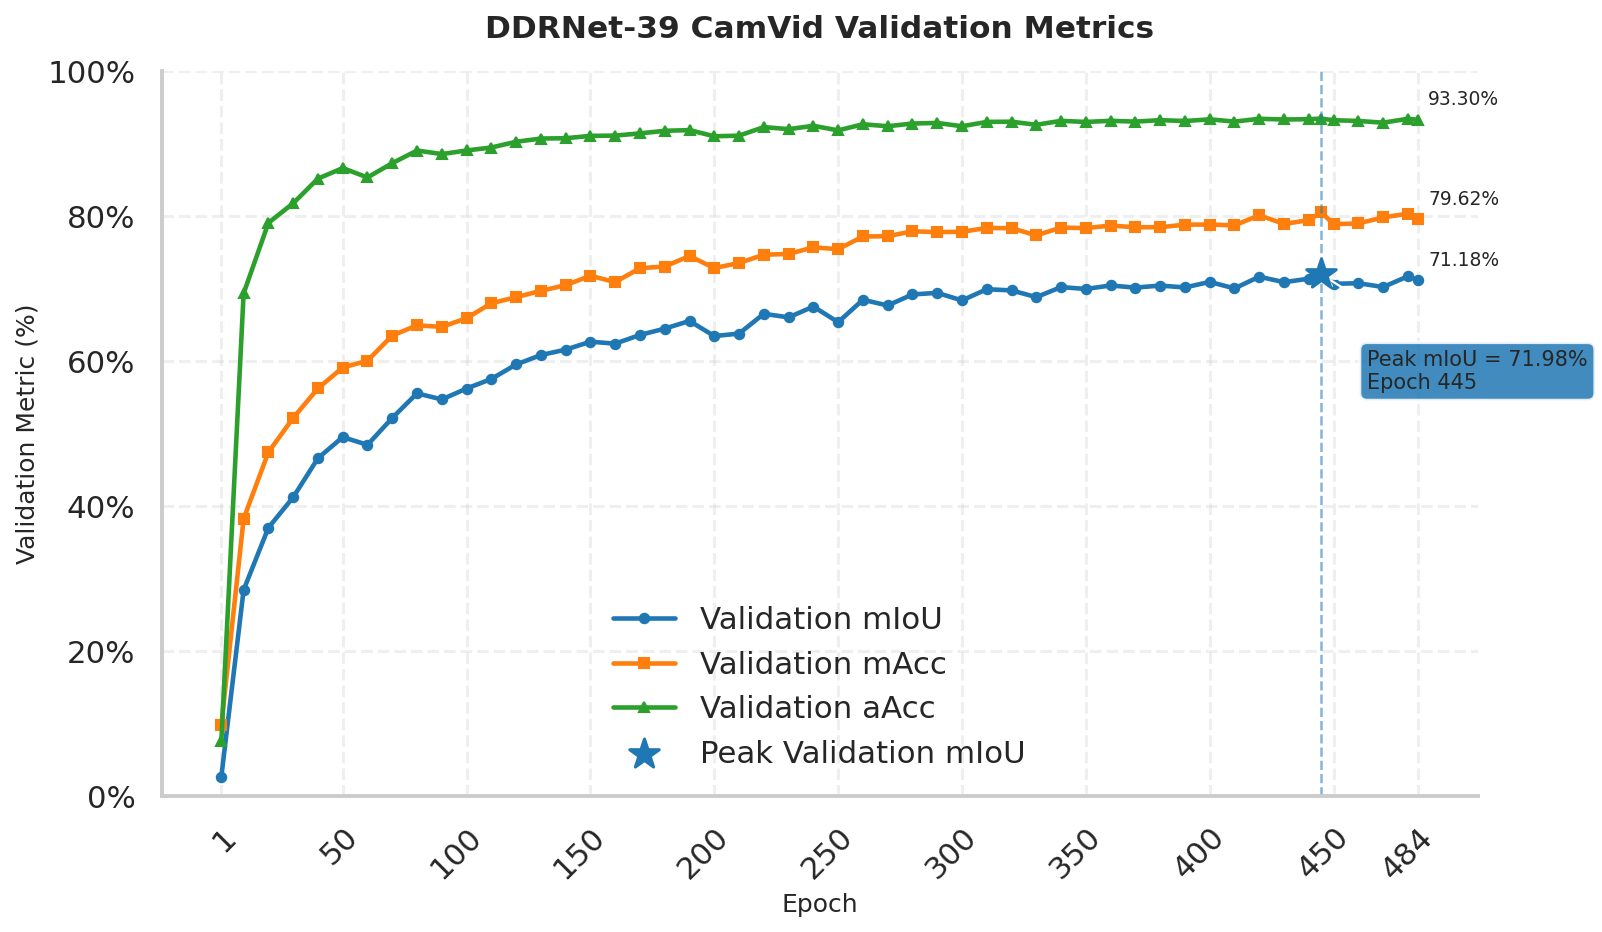


[✓] Validation-metrics figure saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/training_plots_DDRNet_CamVid/publication_validation_metrics_DDRNet39_CamVid.png


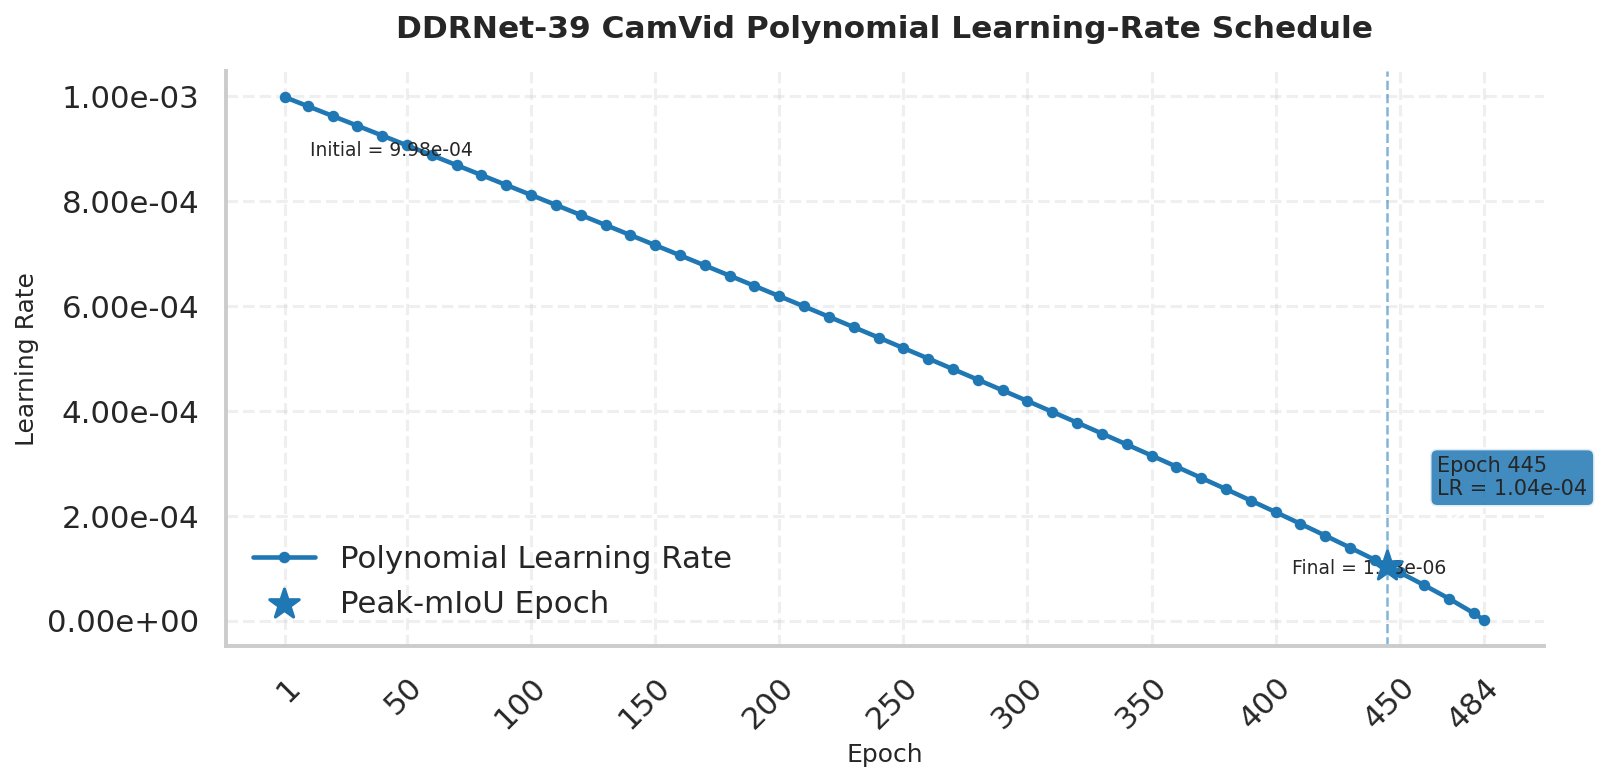


[✓] Polynomial learning-rate figure saved:
    /home/hrusikesh-nishank/Pictures/DDRNet_CamVid/Results_Export_DDRNet_CamVid/training_plots_DDRNet_CamVid/publication_learning_rate_DDRNet39_CamVid.png

STEP 7 COMPLETE — DDRNet-39 / CAMVID
[*] Target epochs          : 484
[*] Recorded epochs        : 484
[*] Peak Validation mIoU   : 71.98%
[*] Peak-mIoU Epoch        : 445
[*] mAcc at Peak Epoch     : 80.56%
[*] aAcc at Peak Epoch     : 93.46%
[*] LR at Peak Epoch       : 1.042738e-04
--------------------------------------------------------------------------------------------
[*] Final Validation mIoU  : 71.18%
[*] Final Validation mAcc  : 79.62%
[*] Final Validation aAcc  : 93.30%
[*] Final Learning Rate    : 1.132908e-06
--------------------------------------------------------------------------------------------
[*] Plot sampling interval : 10 epochs
[*] X-axis tick interval   : 50 epochs
[*] Points plotted         : 51
[*] Figures created        : 2
[*] Figure resolution      : 600 DPI


In [15]:
# ============================================================
# STEP 7 — DDRNet-39 / CAMVID
#
# PUBLICATION-READY FILTERED VALIDATION-METRIC
# AND POLYNOMIAL LEARNING-RATE FIGURES
#
# FIGURE 1:
#       Validation mIoU
#       Validation mAcc
#       Validation aAcc
#
# FIGURE 2:
#       Polynomial Learning-Rate Schedule
#
# IMPORTANT:
#
#   - Uses training history from Step 5.
#   - Uses Step-6 reconstructed BEST result when available
#     only for consistency checking.
#   - No validation inference is repeated.
#   - No test inference is performed.
#   - No history values are modified.
#   - First epoch is retained.
#   - True maximum validation-mIoU epoch is retained.
#   - Final epoch is retained.
#
# CURRENT TRAINING LENGTH:
#
#       484 epochs
#
# VISUALIZATION FILTER:
#
#       Data points : every 10 epochs
#       X-axis ticks: every 50 epochs
#
# OUTPUT:
#
#       Exactly 2 figures
#       Saved once at 600 DPI
#       Stored in PLOTS_DIR from Step 1
#
# No new paths.
# No new imports.
# No retraining.
# No ONNX.
# ============================================================


# ============================================================
# 1. DEPENDENCY CHECK
# ============================================================

required_globals = [
    "history",
    "best_record",
    "PLOTS_DIR",
    "EPOCHS",
    "plt",
    "mtick",
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise NameError(
        "Required objects are missing. "
        "Execute the corrected Steps 1-6 first.\n"
        f"Missing: {missing_globals}"
    )


# ============================================================
# 2. TRAINING-LENGTH CHECK
# ============================================================

if EPOCHS != 484:

    raise RuntimeError(
        "Current DDRNet-39 CamVid experiment "
        "must use 484 epochs."
    )


# ============================================================
# 3. REQUIRED HISTORY KEYS
# ============================================================

required_history_keys = [
    "epoch",
    "val_miou",
    "val_macc",
    "val_aacc",
    "learning_rate",
]


missing_history_keys = [
    key
    for key in required_history_keys
    if (
        key not in history
        or len(
            history[key]
        ) == 0
    )
]


if missing_history_keys:

    raise ValueError(
        "Required training-history entries "
        "are missing or empty:\n"
        f"{missing_history_keys}"
    )


# ============================================================
# 4. HISTORY LENGTH CHECK
# ============================================================

history_length = len(
    history[
        "epoch"
    ]
)


if history_length <= 0:

    raise RuntimeError(
        "DDRNet-39 CamVid training history is empty."
    )


for key in required_history_keys:

    if len(
        history[key]
    ) != history_length:

        raise ValueError(
            f"History length mismatch for '{key}'.\n"
            f"Expected: {history_length}\n"
            f"Found   : {len(history[key])}"
        )


# ============================================================
# 5. OUTPUT DIRECTORY CHECK
# ============================================================
#
# PLOTS_DIR comes directly from Step 1.
# It is NOT redefined here.
# ============================================================

Path(
    PLOTS_DIR
).mkdir(
    parents=True,
    exist_ok=True
)


DISPLAY_STEP7_PLOTS = globals().get(
    "DISPLAY_FINAL_REPORT_PLOTS",
    True
)


print(
    "[✓] Step 7 safety checks passed."
)


# ============================================================
# 6. CONVERT HISTORY TO NUMPY ARRAYS
# ============================================================

epoch_values = np.asarray(
    history[
        "epoch"
    ],
    dtype=np.int64
)


val_miou_values = np.asarray(
    history[
        "val_miou"
    ],
    dtype=np.float64
)


val_macc_values = np.asarray(
    history[
        "val_macc"
    ],
    dtype=np.float64
)


val_aacc_values = np.asarray(
    history[
        "val_aacc"
    ],
    dtype=np.float64
)


learning_rate_values = np.asarray(
    history[
        "learning_rate"
    ],
    dtype=np.float64
)


# ============================================================
# 7. HISTORY VALIDATION
# ============================================================

if (
    np.diff(
        epoch_values
    )
    <= 0
).any():

    raise RuntimeError(
        "Epoch history must be strictly increasing."
    )


for name, values in [
    (
        "Validation mIoU",
        val_miou_values
    ),
    (
        "Validation mAcc",
        val_macc_values
    ),
    (
        "Validation aAcc",
        val_aacc_values
    ),
    (
        "Learning Rate",
        learning_rate_values
    ),
]:

    if not np.isfinite(
        values
    ).any():

        raise RuntimeError(
            f"{name} history contains no finite values."
        )


# ============================================================
# 8. FIRST / FINAL EPOCH
# ============================================================

first_epoch = int(
    epoch_values[
        0
    ]
)


final_epoch = int(
    epoch_values[
        -1
    ]
)


# ============================================================
# 9. TRUE MAXIMUM VALIDATION mIoU
# ============================================================
#
# This is determined directly from the recorded history.
#
# It is intentionally independent of the checkpoint-saving
# minimum-improvement threshold.
# ============================================================

best_history_index = int(
    np.nanargmax(
        val_miou_values
    )
)


best_history_epoch = int(
    epoch_values[
        best_history_index
    ]
)


best_history_miou = float(
    val_miou_values[
        best_history_index
    ]
)


best_history_macc = float(
    val_macc_values[
        best_history_index
    ]
)


best_history_aacc = float(
    val_aacc_values[
        best_history_index
    ]
)


best_history_lr = float(
    learning_rate_values[
        best_history_index
    ]
)


# ============================================================
# 10. STORED BEST-CHECKPOINT INFORMATION
# ============================================================

checkpoint_best_epoch = int(
    best_record.get(
        "best_epoch",
        best_record.get(
            "epoch",
            -1
        )
    )
)


checkpoint_best_miou = float(
    best_record.get(
        "best_miou",
        np.nan
    )
)


# ============================================================
# 11. BEST-CHECKPOINT CROSS-CHECK
# ============================================================

print(
    "\n--- Best Model Cross-Check ---"
)


print(
    f"[*] History maximum epoch : "
    f"{best_history_epoch}"
)


print(
    f"[*] History maximum mIoU  : "
    f"{best_history_miou:.4f}%"
)


print(
    f"[*] Saved BEST epoch      : "
    f"{checkpoint_best_epoch}"
)


print(
    f"[*] Saved BEST mIoU       : "
    f"{checkpoint_best_miou:.4f}%"
)


if (
    checkpoint_best_epoch > 0
    and
    checkpoint_best_epoch
    != best_history_epoch
):

    print(
        "[*] Note: history maximum and saved BEST "
        "checkpoint occur at different epochs."
    )


# ============================================================
# 12. STEP-6 RECONSTRUCTION CROSS-CHECK
# ============================================================

if (
    "reconstructed_best_miou"
    in globals()
):

    reconstructed_miou_value = float(
        reconstructed_best_miou
    )


    reconstruction_difference = abs(
        reconstructed_miou_value
        - checkpoint_best_miou
    )


    print(
        f"[*] Step-6 reconstructed mIoU: "
        f"{reconstructed_miou_value:.4f}%"
    )


    print(
        f"[*] Reconstruction difference : "
        f"{reconstruction_difference:.6f} pp"
    )


    if (
        np.isfinite(
            checkpoint_best_miou
        )
        and
        reconstruction_difference > 0.10
    ):

        warnings.warn(
            "Step-6 reconstructed BEST mIoU differs "
            "from the checkpoint record by more than "
            "0.10 percentage points."
        )


# ============================================================
# 13. FINAL-EPOCH VALUES
# ============================================================

final_miou = float(
    val_miou_values[
        -1
    ]
)


final_macc = float(
    val_macc_values[
        -1
    ]
)


final_aacc = float(
    val_aacc_values[
        -1
    ]
)


final_lr = float(
    learning_rate_values[
        -1
    ]
)


initial_lr = float(
    learning_rate_values[
        0
    ]
)


# ============================================================
# 14. FILTERING CONFIGURATION
# ============================================================
#
# Current experiment:
#
#       484 epochs
#
# Publication plotting:
#
#       Metric / LR points:
#           every 10 epochs
#
#       X-axis ticks:
#           every 50 epochs
#
# First, peak-mIoU and final epochs are always retained.
# ============================================================

PLOT_SAMPLE_STEP = 10


X_TICK_STEP = 50


# ============================================================
# 15. EPOCH -> HISTORY INDEX
# ============================================================

epoch_to_index = {

    int(epoch):
        index

    for index, epoch
    in enumerate(
        epoch_values
    )
}


# ============================================================
# 16. SELECT FILTERED PLOT EPOCHS
# ============================================================

plot_epochs = [

    int(epoch)

    for epoch
    in epoch_values

    if (
        epoch == first_epoch

        or

        epoch
        % PLOT_SAMPLE_STEP
        == 0
    )
]


# Always retain peak validation mIoU.
if (
    best_history_epoch
    not in plot_epochs
):

    plot_epochs.append(
        best_history_epoch
    )


# Always retain saved BEST checkpoint epoch.
if (
    checkpoint_best_epoch > 0
    and
    checkpoint_best_epoch
    not in plot_epochs
):

    plot_epochs.append(
        checkpoint_best_epoch
    )


# Always retain final epoch.
if (
    final_epoch
    not in plot_epochs
):

    plot_epochs.append(
        final_epoch
    )


plot_epochs = sorted(
    set(
        plot_epochs
    )
)


# ============================================================
# 17. FILTERED HISTORY INDICES
# ============================================================

plot_indices = [

    epoch_to_index[
        epoch
    ]

    for epoch
    in plot_epochs
]


# ============================================================
# 18. X-AXIS TICKS
# ============================================================

tick_epochs = [

    int(epoch)

    for epoch
    in epoch_values

    if (
        epoch == first_epoch

        or

        epoch
        % X_TICK_STEP
        == 0
    )
]


if (
    final_epoch
    not in tick_epochs
):

    tick_epochs.append(
        final_epoch
    )


tick_epochs = sorted(
    set(
        tick_epochs
    )
)


# ============================================================
# 19. FILTERED SERIES
# ============================================================

filtered_miou = (
    val_miou_values[
        plot_indices
    ]
)


filtered_macc = (
    val_macc_values[
        plot_indices
    ]
)


filtered_aacc = (
    val_aacc_values[
        plot_indices
    ]
)


filtered_lr = (
    learning_rate_values[
        plot_indices
    ]
)


# ============================================================
# 20. FILTERED FINITENESS CHECK
# ============================================================

for name, values in [

    (
        "Filtered mIoU",
        filtered_miou
    ),

    (
        "Filtered mAcc",
        filtered_macc
    ),

    (
        "Filtered aAcc",
        filtered_aacc
    ),

    (
        "Filtered LR",
        filtered_lr
    ),
]:

    if not np.isfinite(
        values
    ).all():

        raise RuntimeError(
            f"{name} contains NaN/Inf."
        )


# ============================================================
# 21. PLOTTING SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 88
)


print(
    "DDRNet-39 / CAMVID — STEP 7 PLOTTING SUMMARY"
)


print(
    "=" * 88
)


print(
    f"[*] Target epochs          : "
    f"{EPOCHS}"
)


print(
    f"[*] Recorded epochs        : "
    f"{history_length}"
)


print(
    f"[*] First recorded epoch   : "
    f"{first_epoch}"
)


print(
    f"[*] Final recorded epoch   : "
    f"{final_epoch}"
)


print(
    f"[*] Peak validation mIoU   : "
    f"{best_history_miou:.2f}%"
)


print(
    f"[*] Peak-mIoU epoch        : "
    f"{best_history_epoch}"
)


print(
    f"[*] mAcc at peak epoch     : "
    f"{best_history_macc:.2f}%"
)


print(
    f"[*] aAcc at peak epoch     : "
    f"{best_history_aacc:.2f}%"
)


print(
    f"[*] LR at peak epoch       : "
    f"{best_history_lr:.6e}"
)


print(
    f"[*] Plot sample interval   : "
    f"{PLOT_SAMPLE_STEP}"
)


print(
    f"[*] X-axis tick interval   : "
    f"{X_TICK_STEP}"
)


print(
    f"[*] Metric points plotted  : "
    f"{len(plot_epochs)}"
)


print(
    "=" * 88
)


# ============================================================
# 22. FIGURE 1
# COMBINED VALIDATION METRICS
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        11,
        6.5
    )
)


# ============================================================
# mIoU
# ============================================================

ax.plot(
    plot_epochs,
    filtered_miou,
    marker="o",
    linewidth=2.2,
    markersize=4.5,
    label="Validation mIoU"
)


# ============================================================
# mAcc
# ============================================================

ax.plot(
    plot_epochs,
    filtered_macc,
    marker="s",
    linewidth=2.2,
    markersize=4.5,
    label="Validation mAcc"
)


# ============================================================
# aAcc
# ============================================================

ax.plot(
    plot_epochs,
    filtered_aacc,
    marker="^",
    linewidth=2.2,
    markersize=4.5,
    label="Validation aAcc"
)


# ============================================================
# 23. PEAK mIoU MARKER
# ============================================================

ax.scatter(
    [
        best_history_epoch
    ],
    [
        best_history_miou
    ],
    marker="*",
    s=220,
    zorder=6,
    label="Peak Validation mIoU"
)


# ============================================================
# 24. PEAK-EPOCH VERTICAL LINE
# ============================================================

ax.axvline(
    best_history_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.55
)


# ============================================================
# 25. PEAK mIoU ANNOTATION
# ============================================================

ax.annotate(
    (
        f"Peak mIoU = "
        f"{best_history_miou:.2f}%\n"
        f"Epoch {best_history_epoch}"
    ),

    xy=(
        best_history_epoch,
        best_history_miou
    ),

    xytext=(
        22,
        -55
    ),

    textcoords="offset points",

    fontsize=10,

    bbox=dict(
        boxstyle="round,pad=0.35",
        alpha=0.85
    ),

    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.1
    )
)


# ============================================================
# 26. FINAL-EPOCH ANNOTATIONS
# ============================================================

ax.annotate(
    f"{final_miou:.2f}%",

    xy=(
        final_epoch,
        final_miou
    ),

    xytext=(
        5,
        7
    ),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(
    f"{final_macc:.2f}%",

    xy=(
        final_epoch,
        final_macc
    ),

    xytext=(
        5,
        7
    ),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(
    f"{final_aacc:.2f}%",

    xy=(
        final_epoch,
        final_aacc
    ),

    xytext=(
        5,
        7
    ),

    textcoords="offset points",

    fontsize=9
)


# ============================================================
# 27. METRIC FIGURE AXES
# ============================================================

ax.set_xlabel(
    "Epoch",
    fontsize=12
)


ax.set_ylabel(
    "Validation Metric (%)",
    fontsize=12
)


ax.set_title(
    "DDRNet-39 CamVid Validation Metrics",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xticks(
    tick_epochs
)


ax.set_xticklabels(
    [
        str(epoch)
        for epoch
        in tick_epochs
    ]
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        xmax=100,
        decimals=0
    )
)


# ============================================================
# 28. DATA-DRIVEN METRIC Y-AXIS
# ============================================================

combined_metric_values = np.concatenate(
    [
        filtered_miou,
        filtered_macc,
        filtered_aacc,
    ]
)


metric_min = float(
    np.nanmin(
        combined_metric_values
    )
)


metric_max = float(
    np.nanmax(
        combined_metric_values
    )
)


metric_range = (
    metric_max
    - metric_min
)


metric_margin = max(
    3.0,
    metric_range * 0.08
)


metric_lower_bound = max(
    0.0,
    metric_min - metric_margin
)


metric_upper_bound = min(
    100.0,
    metric_max + metric_margin
)


if (
    metric_upper_bound
    <= metric_lower_bound
):

    metric_upper_bound = min(
        100.0,
        metric_lower_bound + 10.0
    )


ax.set_ylim(
    metric_lower_bound,
    metric_upper_bound
)


# ============================================================
# 29. METRIC FIGURE STYLE
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    loc="best",
    frameon=False
)


fig.tight_layout()


# ============================================================
# 30. SAVE FIGURE 1
# ============================================================

combined_graph_path = (
    PLOTS_DIR
    / "publication_validation_metrics_DDRNet39_CamVid.png"
)


fig.savefig(
    combined_graph_path,
    dpi=600,
    bbox_inches="tight"
)


if DISPLAY_STEP7_PLOTS:

    plt.show()


plt.close(
    fig
)


print(
    "\n[✓] Validation-metrics figure saved:"
)


print(
    f"    {combined_graph_path}"
)


# ============================================================
# 31. FIGURE 2
# POLYNOMIAL LEARNING-RATE SCHEDULE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        11,
        5.5
    )
)


# ============================================================
# 32. LR CURVE
# ============================================================

ax.plot(
    plot_epochs,
    filtered_lr,
    marker="o",
    linewidth=2.2,
    markersize=4.5,
    label="Polynomial Learning Rate"
)


# ============================================================
# 33. PEAK-mIoU LR MARKER
# ============================================================

ax.scatter(
    [
        best_history_epoch
    ],
    [
        best_history_lr
    ],
    marker="*",
    s=220,
    zorder=6,
    label="Peak-mIoU Epoch"
)


ax.axvline(
    best_history_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.55
)


# ============================================================
# 34. PEAK-EPOCH LR ANNOTATION
# ============================================================

ax.annotate(
    (
        f"Epoch {best_history_epoch}\n"
        f"LR = {best_history_lr:.2e}"
    ),

    xy=(
        best_history_epoch,
        best_history_lr
    ),

    xytext=(
        24,
        34
    ),

    textcoords="offset points",

    fontsize=10,

    bbox=dict(
        boxstyle="round,pad=0.35",
        alpha=0.85
    ),

    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.1
    )
)


# ============================================================
# 35. INITIAL LR ANNOTATION
# ============================================================

ax.annotate(
    f"Initial = {initial_lr:.2e}",

    xy=(
        first_epoch,
        initial_lr
    ),

    xytext=(
        12,
        -28
    ),

    textcoords="offset points",

    fontsize=9
)


# ============================================================
# 36. FINAL LR ANNOTATION
# ============================================================

ax.annotate(
    f"Final = {final_lr:.2e}",

    xy=(
        final_epoch,
        final_lr
    ),

    xytext=(
        -92,
        22
    ),

    textcoords="offset points",

    fontsize=9
)


# ============================================================
# 37. LR FIGURE AXES
# ============================================================

ax.set_xlabel(
    "Epoch",
    fontsize=12
)


ax.set_ylabel(
    "Learning Rate",
    fontsize=12
)


ax.set_title(
    "DDRNet-39 CamVid Polynomial Learning-Rate Schedule",
    fontsize=15,
    fontweight="bold",
    pad=16
)


ax.set_xticks(
    tick_epochs
)


ax.set_xticklabels(
    [
        str(epoch)
        for epoch
        in tick_epochs
    ]
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)


ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter(
        "%.2e"
    )
)


# ============================================================
# 38. LR FIGURE STYLE
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    loc="best",
    frameon=False
)


fig.tight_layout()


# ============================================================
# 39. SAVE FIGURE 2
# ============================================================

lr_graph_path = (
    PLOTS_DIR
    / "publication_learning_rate_DDRNet39_CamVid.png"
)


fig.savefig(
    lr_graph_path,
    dpi=600,
    bbox_inches="tight"
)


if DISPLAY_STEP7_PLOTS:

    plt.show()


plt.close(
    fig
)


print(
    "\n[✓] Polynomial learning-rate figure saved:"
)


print(
    f"    {lr_graph_path}"
)


# ============================================================
# 40. FINAL STEP-7 SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 92
)


print(
    "STEP 7 COMPLETE — DDRNet-39 / CAMVID"
)


print(
    "=" * 92
)


print(
    f"[*] Target epochs          : "
    f"{EPOCHS}"
)


print(
    f"[*] Recorded epochs        : "
    f"{history_length}"
)


print(
    f"[*] Peak Validation mIoU   : "
    f"{best_history_miou:.2f}%"
)


print(
    f"[*] Peak-mIoU Epoch        : "
    f"{best_history_epoch}"
)


print(
    f"[*] mAcc at Peak Epoch     : "
    f"{best_history_macc:.2f}%"
)


print(
    f"[*] aAcc at Peak Epoch     : "
    f"{best_history_aacc:.2f}%"
)


print(
    f"[*] LR at Peak Epoch       : "
    f"{best_history_lr:.6e}"
)


print(
    "-" * 92
)


print(
    f"[*] Final Validation mIoU  : "
    f"{final_miou:.2f}%"
)


print(
    f"[*] Final Validation mAcc  : "
    f"{final_macc:.2f}%"
)


print(
    f"[*] Final Validation aAcc  : "
    f"{final_aacc:.2f}%"
)


print(
    f"[*] Final Learning Rate    : "
    f"{final_lr:.6e}"
)


print(
    "-" * 92
)


print(
    f"[*] Plot sampling interval : "
    f"{PLOT_SAMPLE_STEP} epochs"
)


print(
    f"[*] X-axis tick interval   : "
    f"{X_TICK_STEP} epochs"
)


print(
    f"[*] Points plotted         : "
    f"{len(plot_epochs)}"
)


print(
    f"[*] Figures created        : "
    f"2"
)


print(
    f"[*] Figure resolution      : "
    f"600 DPI"
)


print(
    "-" * 92
)


print(
    f"[*] Validation figure:"
)


print(
    f"    {combined_graph_path}"
)


print(
    f"[*] Learning-rate figure:"
)


print(
    f"    {lr_graph_path}"
)


print(
    "=" * 92
)


print(
    "\n[✓] Step 7 completed successfully."
)